# 06 · Letra 1 (NSE) y Letra 2 (Ventas) por punto de venta — Bepensa · canal Tradicional · sueros e hidratación · ZM Mérida

Construye las dos letras de la clasificación Golden Stores de cada punto de venta (PDV) del **canal Tradicional**, con **solo
datos del CP** para el PDV: id, nombre, subcanal, coordenadas, venta media y potencial (regla del usuario, 2026-09-30: se
quita todo lo del canal Moderno y no se usa el archivo de ventas). Enfoque acordado:

* **Letra 1 · NSE del clúster.** La ZM se divide en hexágonos H3 de res 9 (≈ 0.1 km²): el **centro** de cada hexágono es un
  punto NSE y su **buffer de 300 m** reúne los hogares que le dan su NSE (INEGI: regla AMAI por hexágono res 10, asegurada con
  el Censo por manzana). Todos los PDV que caen en el hexágono **comparten** ese NSE: la Letra 1 es del clúster, no del PDV
  (hexágonos en vez de centroides de AGEB: más simple en geografías complejas). **AltScore mueve el NSE**: su índice alrededor
  del mismo centro se combina con el de INEGI con peso λ.
* **Letra 2 · Ventas del PDV** (regla del usuario, 2026-09-30). Cada PDV con venta tiene un **vector**: venta media y potencial,
  los dos del **CP** (con decimales), y **Rappi** = pedidos/mes medios de hidratación Coca-Cola (Powerade, Flashlyte, Vitamin Water) de las tiendas Rappi de su **buffer
  de 300 m** (suma ÷ número de tiendas; 0 si no hay). Cada variable pasa a su **rango percentil descendente** entre los PDV con
  venta (0 = el que más vende) y el **score** es su media ponderada con pesos **2 · 2 · 1** (Rappi pesa la mitad). **H si el
  score < 0.4**; si no, L. El PDV sin venta es **L** y no entra al ranking. Los rangos quitan las unidades: no hay que pasar
  Rappi a cajas.
* Las letras juntas llevan la acción fija de Golden Stores (HH Atacar · HL Bloquear · LH Fortalecer · LL Mantener). El
  entregable trae cada letra **sin y con** su fuente adicional: Letra 1 sin y con AltScore, Letra 2 sin y con Rappi.

## Fórmulas

$i$ = PDV · $s(i)$ = su subcanal (CP) · $c(i)$ = su clúster NSE: la celda H3 res 9 que lo contiene ·
$A_c=\{h:\ d(\text{centro}(h),\,\text{centro}(c))\le 300\ \text{m}\}$ = hexágonos H3 res 10 del buffer del clúster ·
$k$ = nivel AMAI ($1$ = D/E, $2$ = D+, $3$ = C−, $4$ = C, $5$ = C+, $6$ = A/B).

**Letra 1 (NSE del clúster)**

$$HH_{ck}=\sum_{h\in A_c}HH_{hk}\qquad p_{ck}=\frac{HH_{ck}}{\sum_k HH_{ck}}\qquad N_c=\sum_{k=1}^{6}k\,p_{ck}$$

$$\tilde N_c=Q_N\!\left(F_a(a_c)\right)\qquad N^*_c=(1-\lambda)\,N_c+\lambda\,\tilde N_c\qquad I^{N}_i=100\cdot\frac{N^*_{c(i)}}{\bar N^*_{s(i)}}\qquad L1_i=\begin{cases}H & \text{si } I^{N}_i\ge 100\\ L & \text{si } I^{N}_i<100\end{cases}$$

$HH_{hk}$ = hogares 2025 del nivel $k$ en el hexágono $h$: cada manzana reparte sus hogares por **área** entre los hexágonos
que toca (notebook 04), con la distribución NSE de su AGEB (microsimulación AMAI, notebook 01). $a_c$ = media del índice NSE
AltScore (percentil 0-100, notebook 00b) de sus puntos a ≤ 300 m del centro; $\tilde N_c$ lo lleva a la escala de $N$ por
cuantiles ($F_a$ = su distribución, $Q_N$ = cuantiles de $N$, en los clústeres con PDV objetivo) y $\lambda$ =
`C.ALTSCORE_PESO_NSE`. Si el buffer tiene menos de `C.ALTSCORE_MIN_PUNTOS` puntos AltScore con índice, $N^*_c = N_c$.

**Letra 2 (Ventas del PDV)**

$$R_i=\frac{1}{|B_i|}\sum_{r\in B_i}\text{venta}_r\quad(B_i=\{r:\ d(i,r)\le 300\ \text{m}\};\ R_i=0\ \text{si}\ B_i=\varnothing)\qquad r^{x}_i=\text{pct\_rank}_{\downarrow}(x_i)\ \text{en los PDV con venta}$$

$$S_i=\frac{2\,r^{V}_i+2\,r^{CP}_i+1\,r^{R}_i}{5}\qquad L2_i=\begin{cases}H & \text{si } S_i<0.4\ L & \text{en otro caso (y todo PDV sin venta)}\end{cases}$$

$\bar N^*_s$ = media del subcanal sobre los PDV objetivo (con venta y con hogares en su clúster NSE). $V_i$ = venta media del
PDV según el CP (`PotentialQuantitative_CustomCat_sueros`, cajas/mes) y $CP_i$ = su potencial
(`PotentialQuantitativeFinal_CustomCat_sueros`, cajas/mes que le faltan frente a su comparable), **con decimales**. La clase del
CP (Very High → Low) sigue en el entregable. $B_i$ = tiendas físicas Rappi (00c: sueros e hidratación, ene-2025 → ago-2026) a
≤ 300 m del PDV y $\text{venta}_r$ = sus **pedidos por mes de vida** de hidratación Coca-Cola (Powerade, Flashlyte, Glacéau Vitamin Water y Vitamin Water; usuario, 2026-10-05) (no pesos; usuario, 2026-10-01). $\text{pct\_rank}_{\downarrow}$ = rango percentil
descendente (1/n para el mayor, 1 para el menor; empates con rango medio), calculado sobre todos los PDV Tradicional con venta.
Pesos = `C.LETRA2_PESOS` y corte = `C.LETRA2_CORTE`. **Letra 2 sin Rappi**: la misma regla con pesos 2 · 2 · 0.

**QA con mapa en cada paso** (qué se hace y por qué): 1.1 NSE del punto · 1.2 variante INEGI por manzana · 1.3 clúster NSE ·
1.4 AltScore mueve el NSE · 1.5 Letra 1 · 2.1 venta media + CP · 2.2 Rappi del buffer · 2.3 vector y score ·
2.4 respaldo y sensibilidad · 2.5 Letra 2 · 3 letras juntas. Además, un **mapa interactivo**
(`outputs/<ciudad>/<cliente>/06_mapa_qa_letras_*.html`, con filtro por subcanal) con los mismos pasos: clic en un hexágono o
en un PDV dibuja su clúster NSE, su buffer y su ficha.

**Entregables (carpeta del cliente):** Excel del canal Tradicional con la estructura pos_id · AltScore · INEGI · ventas (CP,
Rappi, media) · clúster · letra 1 · letra 2 (y la acción Golden Stores), y la presentación (sección 6).

**Reproducir:** `uv run python src/correr.py --pasos 06 merida` (necesita las salidas de 00, 00b, 00c, 01 y 04).

In [1]:
import os
import sys
import warnings
from pathlib import Path

os.environ.setdefault("CIUDAD", "merida")
BASE = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
sys.path.insert(0, str(BASE / "src"))

import numpy as np
import pandas as pd
import geopandas as gpd
import h3
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from scipy import stats
from shapely.geometry import Point, Polygon
from IPython.display import display

import config as C
import altscore as A
import eda
import letras as LT
import mapas as MP
import rappi as R
from descargas import requisitos, descargar_fuente, extraer

assert C.CIUDAD == C.CLIENTE_CIUDAD, f"Los datos de {C.CLIENTE} son de {C.CLIENTE_CIUDAD}; CIUDAD={C.CIUDAD}"
F04 = C.PROC / f"pdv_{C.CLIENTE}_hexagonos_{C.SLUG}.pkl"
F_HEX = C.PROC / f"hexagonos_h3r{C.H3_RES}_{C.CLIENTE}_{C.SLUG}.gpkg"
F_RAPPI = C.PROC / f"rappi_hidratacion_tiendas_{C.SLUG}.parquet"
F_ALT = C.PROC / f"altscore_{C.CLIENTE}_{C.SLUG}.parquet"
F_SEL = C.PROC / f"altscore_senales_{C.CLIENTE}_{C.SLUG}.csv"
requisitos({F04: "04_hexagonos_pdv", F_HEX: "04_hexagonos_pdv", C.PROC / f"pdv_{C.CLIENTE}_{C.SLUG}.parquet": "00_ventas_cp_validacion",
            C.PROC / f"ageb_{C.SLUG}.gpkg": "01_socioeconomico_merida", C.PROC / f"manzanas_{C.SLUG}.gpkg": "01_socioeconomico_merida",
            C.PROC / f"nse_ageb_{C.SLUG}.parquet": "01_socioeconomico_merida", F_RAPPI: "00c_rappi_eda"})
eda.estilo()
pd.set_option("display.width", 220, "display.max_columns", 40, "display.float_format", "{:,.2f}".format)
NSE = C.GRUPOS["NSE AMAI 2024"]
R300, THETA, FR = C.RADIO_PDV_M, C.RAPPI_MIN_PEDIDOS, C.FRONTERA
PESOS_L2, CORTE = C.LETRA2_PESOS, C.LETRA2_CORTE
RES_CL, LAM, MIN_ALT = C.NSE_CLUSTER_RES, C.ALTSCORE_PESO_NSE, C.ALTSCORE_MIN_PUNTOS
CMAP_NSE = LinearSegmentedColormap.from_list("nse", MP.SECUENCIAL)
CMAP_CENSO = LinearSegmentedColormap.from_list("censo", MP.AZULES)
print(f"{C.ZM_NOMBRE} · canal Tradicional · clúster NSE = hexágono H3 res {RES_CL} + buffer de {R300} m · AltScore mueve el NSE "
      f"(λ = {LAM:g}, ≥ {MIN_ALT} puntos) · Letra 2 = score de rangos (pesos venta {PESOS_L2['venta']} · CP {PESOS_L2['cp']} · Rappi {PESOS_L2['rappi']}; H si < {CORTE})")

Requisitos OK (7 archivos).
ZM Guadalajara · canal Tradicional · clúster NSE = hexágono H3 res 9 + buffer de 300 m · AltScore mueve el NSE (λ = 0.25, ≥ 5 puntos) · Letra 2 = score de rangos (pesos venta 2 · CP 2 · Rappi 1; H si < 0.4)


## 0. Datos: PDV Tradicional del CP (04), clústeres NSE, hexágonos, AGEB, manzanas y tiendas Rappi (00c)

Solo entran los PDV del **canal Tradicional** (abarrotes, independientes y Six; `src/cadenas.py`): se quitan los del canal
Moderno (Modelorama y farmacias de cadena). Del PDV se usa **solo el CP**: id, nombre, subcanal, coordenadas, venta media
(`PotentialQuantitative_CustomCat_sueros`) y potencial (`PotentialQuantitativeFinal_CustomCat_sueros`); "con venta" = venta
media del CP > 0. Cada PDV cae en un **clúster NSE** (su hexágono H3 res 9) y el buffer de 300 m desde el centro del
clúster da sus hogares.

In [2]:
tabla = pd.read_pickle(F04)
todos = tabla[""].reset_index(drop=True)
TRAD = todos.Canal.eq("Tradicional").to_numpy()                       # regla del usuario (2026-09-30): nada del canal Moderno
ids = todos[TRAD].copy().reset_index(drop=True)
ids["Subcanal"] = ids.Subcanal.str.replace("ABARRROTES", "ABARROTES")      # error de captura del CP (solo para mostrar)
hh04 = pd.DataFrame({c: tabla[(c, "HHs")].to_numpy(float)[TRAD] for c in NSE})   # hogares por nivel en el buffer del PDV (04)
pdv0 = pd.read_parquet(C.PROC / f"pdv_{C.CLIENTE}_{C.SLUG}.parquet").set_index("pos_id_cp")   # CP limpio (00)
hexg = gpd.read_file(F_HEX).set_index("hex")
hex_hh = hexg[[f"HHs_{c}" for c in NSE]].set_axis(NSE, axis=1)
ageb = gpd.read_file(C.PROC / f"ageb_{C.SLUG}.gpkg")
mzg = gpd.read_file(C.PROC / f"manzanas_{C.SLUG}.gpkg")
CRS = mzg.crs
rp = pd.read_parquet(F_RAPPI)
lin_rp = pd.read_parquet(C.PROC / f"rappi_hidratacion_lineas_{C.SLUG}.parquet")
lin_rp["tomada"] = lin_rp.Product_Maker_Standard.eq(C.RAPPI_FABRICANTE) & lin_rp.Product_Brand.isin(C.RAPPI_MARCAS_L2)   # usuario, 2026-10-05
rp["pedidos_mes_hidratacion"] = rp.pedidos_mes                                   # referencia: todas las marcas, sueros e isotónicos
rp["pedidos_tomados"] = rp.tienda_fisica.map(lin_rp[lin_rp.tomada].groupby("tienda_fisica").order_code.nunique()).fillna(0)
rp["pedidos_mes"] = rp.pedidos_tomados / rp.meses_vida                            # lo que entra a la Letra 2: hidratación Coca-Cola (RAPPI_MARCAS_L2)
descargar_fuente(C.FUENTES["mg"])
D_MG = extraer(C.ARCHIVOS["mg"])
mun = gpd.read_file(next(D_MG.rglob(f"{C.ENT}mun.shp")))
mun = mun[mun.CVE_MUN.isin(C.ZM_MUNICIPIOS)].to_crs(CRS)
ageb_c = ageb.to_crs(CRS)
hex_c = hexg[["geometry"]].to_crs(CRS)
ref_zm = pd.read_parquet(C.PROC / f"nse_ageb_{C.SLUG}.parquet")
REF = pd.Series([ref_zm[f"HHs_{c}"].sum() / ref_zm["Total HHs"].sum() * 100 for c in NSE], index=NSE)     # % de la ZM (índice vs ZM)

MODERNO = todos.Cadena[~TRAD].value_counts()
ids["segmento"] = ids.Subcanal                                            # subcanal del CP (pos_subchannel)
ids["con_venta"] = ids.pos_id_cp.map(pdv0[f"PotentialQuantitative_{C.CP_CATEGORIA}"]).gt(0)   # con venta según el CP
ids["HH_area"] = ids["HHs en el área"]                                    # hogares del buffer del propio PDV (04): solo para el QA

# clúster NSE: la celda H3 res 9 del PDV; su centro es el punto NSE y el buffer de 300 m desde el centro da sus hogares
ids["cluster_nse"] = [h3.latlng_to_cell(a, b, RES_CL) for a, b in zip(ids.Latitud, ids.Longitud)]
cl = pd.DataFrame(index=pd.Index(sorted(ids.cluster_nse.unique()), name="cluster_nse"))
cl["lat"], cl["lon"] = LT.centros(cl.index)
areas_cl = LT.hexagonos_en_radio(cl.lat, cl.lon, R300, C.H3_RES)
hh_cl = LT.suma_area(hex_hh, areas_cl).set_axis(cl.index)                # hogares por nivel del buffer de cada clúster (sin redondear)
cl["hog"] = hh_cl.sum(axis=1)
ids["HH_cluster"] = ids.cluster_nse.map(cl.hog).to_numpy()
ids["con_nse"] = ids.HH_cluster > 0
ids["objetivo"] = ids.con_venta & ids.con_nse
cl["n_pdv"] = ids.groupby("cluster_nse").size()
cl["n_objetivo"] = ids[ids.objetivo].groupby("cluster_nse").size().reindex(cl.index).fillna(0).astype(int)
pts = gpd.GeoDataFrame(ids[["pos_id_cp"]], geometry=gpd.points_from_xy(ids.Longitud, ids.Latitud), crs=4326).to_crs(CRS)
UNIVERSO = (f"CP en la {C.ZM_NOMBRE}: {len(todos):,} PDV; se quitan {int((~TRAD).sum())} del canal Moderno ("
            + ", ".join(f"{k} {v}" for k, v in MODERNO.head(4).items()) + f"…) → {len(ids):,} Tradicional, {ids.con_venta.sum():,} con venta según el CP; "
            f"{ids.objetivo.sum():,} objetivo (con venta y hogares en su clúster NSE).")
print(UNIVERSO)
print(f"Clústeres NSE (H3 res {RES_CL}) con PDV: {len(cl):,} · hexágonos res 10 {len(hexg):,} · AGEB {len(ageb)} · manzanas {len(mzg):,} · "
      f"tiendas Rappi {len(rp)} ({int(rp.activa.sum())} activas, {int(rp.activa_sueros.sum())} activas en sueros)")
display(ids.groupby("segmento").agg(PDV=("pos_id_cp", "size"), con_venta=("con_venta", "sum"), objetivo=("objetivo", "sum"),
                                    clusteres=("cluster_nse", "nunique")))

[ok] ya existe mg2025eic_14_jalisco.zip


CP en la ZM Guadalajara: 39,236 PDV; se quitan 50 del canal Moderno (Modelorama 27, Go Mart 8, Farmacias Similares 3, Su Super 3…) → 39,186 Tradicional, 24,632 con venta según el CP; 24,548 objetivo (con venta y hogares en su clúster NSE).
Clústeres NSE (H3 res 9) con PDV: 5,392 · hexágonos res 10 52,253 · AGEB 1998 · manzanas 56,666 · tiendas Rappi 594 (259 activas, 23 activas en sueros)


,PDV,con_venta,objetivo,clusteres
segmento,,,,
Abarrotes / Almacenes / Bodegas / Víveres,15861,7980,7967,3927
Carnicería / Pollería / Pescadería,529,369,369,465
Cerveza y Licores,7767,6009,5990,3166
Estanquillos / kioscos,4194,3276,3253,2313
Farmacia Independiente,671,439,438,526
Frutas y Verduras,1450,1021,1020,1036
Hogar con Venta,7048,4399,4375,3134
Minisuper / Minimarket,377,304,302,320
Panadería / Pastelería,141,81,81,134


## 1. Letra 1 · NSE
### 1.1 NSE del punto geográfico

**Qué se hace:** el punto es el **hexágono H3 res 10** donde está el PDV (≈ 0.015 km², del tamaño de una manzana). Su NSE
es la distribución AMAI de los hogares que caen en ese hexágono; se resume en el **nivel NSE medio** $N=\sum_k k\,p_k$
(1 = D/E … 6 = A/B). Al lado va el NSE de la **AGEB** que contiene al punto.

**Por qué:** la microsimulación AMAI (notebook 01) es por AGEB, así que dentro de una AGEB todas las manzanas tienen la misma
distribución. El hexágono solo cambia cuando mezcla manzanas de dos AGEB. Si el punto no tiene hogares (plaza, avenida
comercial) su NSE no existe: por eso la letra no se toma del punto sino del **clúster NSE** (sección 1.3).

De 24,548 PDV objetivo, 99% tienen hogares en su hexágono y 95% caen en una AGEB urbana; NSE del punto vs NSE de su AGEB: ρ = +0.97 (el hexágono hereda la AGEB salvo en sus bordes); 231 PDV están en un hexágono sin hogares (zona comercial): su NSE sale del clúster.


punto,con hogares,sin hogares (comercial)
segmento,,
Abarrotes / Almacenes / Bodegas / Víveres,7909,58
Carnicería / Pollería / Pescadería,366,3
Cerveza y Licores,5961,29
Estanquillos / kioscos,3215,38
Farmacia Independiente,437,1
Frutas y Verduras,1014,6
Hogar con Venta,4296,79
Minisuper / Minimarket,299,3
Panadería / Pastelería,78,3


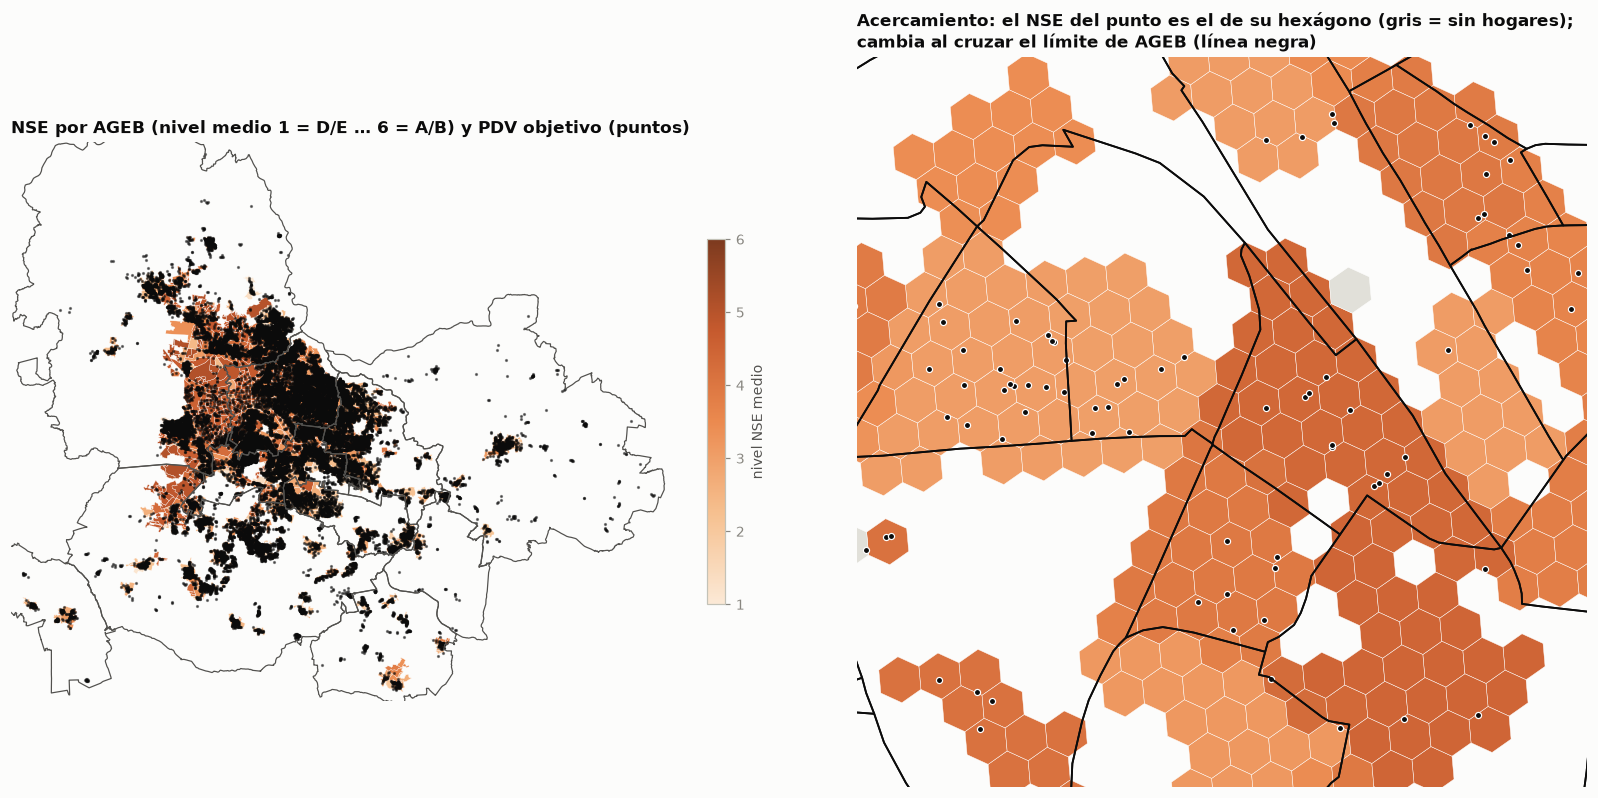

In [3]:
hexg["N"] = LT.nivel_medio(hex_hh)
hexg["abc"] = (hex_hh["A/B"] + hex_hh["C+"]) / hex_hh.sum(axis=1).replace(0, np.nan) * 100
ageb["N"] = LT.nivel_medio(ageb[[f"HHs_{c}" for c in NSE]].set_axis(NSE, axis=1))
ageb_c["N"] = ageb.N.to_numpy()
ids["N_punto"] = hexg.N.reindex(ids["Hexágono H3"]).to_numpy()
j = gpd.sjoin(pts, ageb_c[["CVEGEO", "N", "geometry"]], how="left", predicate="within")
j = j[~j.index.duplicated()]
ids["AGEB"], ids["N_ageb"] = j.CVEGEO.reindex(ids.index).to_numpy(), j.N.reindex(ids.index).to_numpy()
ob = ids[ids.objetivo]
ok_pa = ob.dropna(subset=["N_punto", "N_ageb"])
rho_pa = stats.spearmanr(ok_pa.N_punto, ok_pa.N_ageb)[0]
PUNTO = (f"De {len(ob):,} PDV objetivo, {ob.N_punto.notna().mean():.0%} tienen hogares en su hexágono y {ob.N_ageb.notna().mean():.0%} "
         f"caen en una AGEB urbana; NSE del punto vs NSE de su AGEB: ρ = {rho_pa:+.2f} (el hexágono hereda la AGEB salvo en sus bordes); "
         f"{ob.N_punto.isna().sum():,} PDV están en un hexágono sin hogares (zona comercial): su NSE sale del clúster.")
print(PUNTO)
display(ob.assign(punto=np.where(ob.N_punto.notna(), "con hogares", "sin hogares (comercial)")).groupby(["segmento", "punto"]).size().unstack(fill_value=0))

x0, y0, x1, y1 = pts[ids.objetivo].total_bounds
centro = pts[ids.objetivo].geometry.union_all().centroid
fig, ax = plt.subplots(1, 2, figsize=(15, 7.2))
ageb_c.plot(ax=ax[0], column="N", cmap=CMAP_NSE, vmin=1, vmax=6, edgecolor="white", lw=0.2)
pts[ids.objetivo].plot(ax=ax[0], color=eda.TINTA, markersize=1.2, alpha=0.5)
MP.fondo(ax[0], mun)
ax[0].set_xlim(x0 - 1500, x1 + 1500); ax[0].set_ylim(y0 - 1500, y1 + 1500)
ax[0].set_title("NSE por AGEB (nivel medio 1 = D/E … 6 = A/B) y PDV objetivo (puntos)")
sm = plt.cm.ScalarMappable(cmap=CMAP_NSE, norm=plt.Normalize(1, 6))
plt.colorbar(sm, ax=ax[0], shrink=0.5, label="nivel NSE medio")
cz_x, cz_y = centro.x, centro.y
cerca = hex_c.join(hexg[["N"]])
cerca = cerca[cerca.intersects(Point(cz_x, cz_y).buffer(1400))]
cerca.plot(ax=ax[1], column="N", cmap=CMAP_NSE, vmin=1, vmax=6, edgecolor="white", lw=0.3, missing_kwds={"color": eda.GRID})
ageb_c.boundary.plot(ax=ax[1], color=eda.TINTA, lw=1.2)
pz = pts[ids.objetivo & pts.intersects(Point(cz_x, cz_y).buffer(1400))]
pz.plot(ax=ax[1], color=eda.TINTA, markersize=16, edgecolor="white", lw=0.8)
MP.encuadre(ax[1], cz_x, cz_y, 1300)
ax[1].set_axis_off()
ax[1].set_title("Acercamiento: el NSE del punto es el de su hexágono (gris = sin hogares);\ncambia al cruzar el límite de AGEB (línea negra)")
plt.tight_layout(); plt.show()

### 1.2 Nos aseguramos del NSE: variante INEGI por manzana (Censo 2020) y variante digital (Rappi)

**Qué se hace:** con los resultados del Censo 2020 **por manzana** (no por AGEB) se arma un índice de bienes y escolaridad:
% de viviendas con auto, con computadora y con internet, y grado promedio de escolaridad. Cada variable se normaliza por
rangos y el índice es su **primer componente principal** (mismo método que el índice AltScore del 00b), en percentil 0-100.
Se lleva a cada hexágono por **área de manzana** ponderada por hogares y se compara con el NSE AMAI (ρ de Spearman con IC por
bootstrap de bloques H3 res 7). Variante digital: en las tiendas Rappi, el % de pagos con Apple Pay y en efectivo contra el
NSE INEGI de sus 300 m.

**Por qué:** el NSE AMAI es un **modelo** (microsimulación por AGEB); el Censo por manzana es una **medición directa** y más
fina. Si los dos coinciden, el NSE es confiable; donde no, el PDV se marca "NSE a revisar". Las manzanas con dato protegido
("*", pocas viviendas) quedan sin índice y no se imputan.

[ok] ya existe ageb_mza_urbana_14_cpv2020_csv.zip


Manzanas de la ZM: 56,884 · con las 4 variables: 76% · α de Cronbach 0.93 · el 1.er componente explica 83% · cargas {'% viviendas con auto': 0.48, '% con computadora': 0.52, '% con internet': 0.5, 'escolaridad promedio (años)': 0.5}
η² del índice por AGEB = 0.75: la AGEB explica 75% de la variación entre manzanas; el 25% restante es variación DENTRO de la AGEB que el NSE AMAI (por AGEB) no ve.


NSE AMAI vs índice del Censo por manzana en 21,653 hexágonos: ρ = +0.91 (IC95 por bloques [+0.90, +0.93]). Variante digital (Rappi, 103 tiendas): % pago Apple Pay ρ = -0.05 [-0.25, +0.16] → no confirma (signo contrario o no significativa); % pago efectivo ρ = -0.31 [-0.48, -0.11] → confirma el NSE de INEGI.


,señal Rappi,tiendas,ρ con N INEGI (300 m),IC95,p,signo esperado,lectura
0,% pago Apple Pay,103,-0.05,"[-0.25, +0.16]",0.61,1,no confirma (signo contrario o no significativa)
1,% pago efectivo,103,-0.31,"[-0.48, -0.11]",0.00,-1,confirma el NSE de INEGI


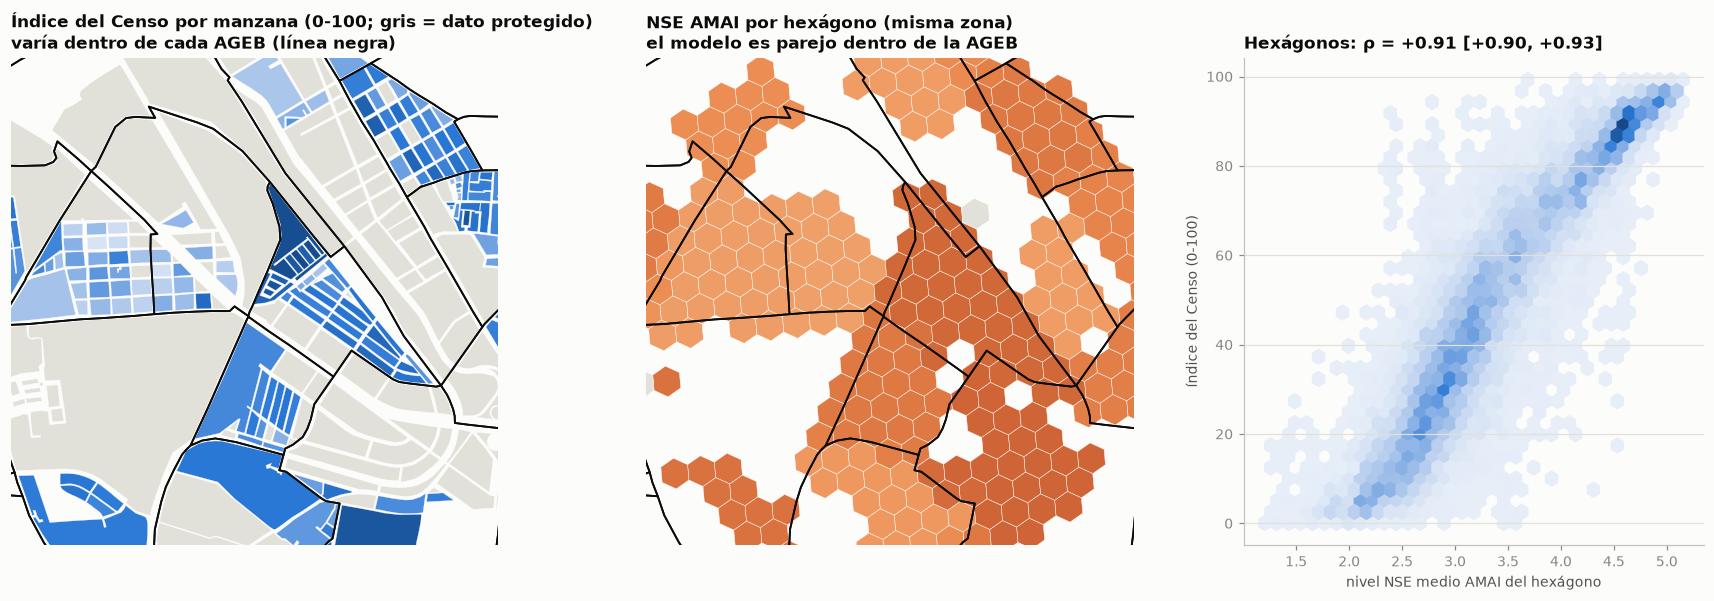

In [4]:
descargar_fuente(C.FUENTES["ageb"])
D_AGEB = extraer(C.ARCHIVOS["ageb"])
f_censo = next(D_AGEB.rglob("conjunto_de_datos_ageb_urbana_*_cpv2020.csv"))
COLS_CENSO = ["ENTIDAD", "MUN", "LOC", "AGEB", "MZA", "VIVPARH_CV", "VPH_AUTOM", "VPH_PC", "VPH_INTER", "GRAPROES"]
try:
    cz = pd.read_csv(f_censo, dtype=str, usecols=COLS_CENSO, encoding="utf-8-sig")
except UnicodeDecodeError:
    cz = pd.read_csv(f_censo, dtype=str, usecols=COLS_CENSO, encoding="latin-1")
cz = cz[(cz.MZA != "000") & cz.MUN.isin(C.ZM_MUNICIPIOS)].copy()
cz["CVEGEO"] = cz.ENTIDAD.str.zfill(2) + cz.MUN + cz.LOC + cz.AGEB + cz.MZA
v = cz[COLS_CENSO[5:]].apply(pd.to_numeric, errors="coerce")                  # "*" = dato protegido → NaN
viv = v.VIVPARH_CV.where(v.VIVPARH_CV > 0)
IND = pd.DataFrame({"% viviendas con auto": v.VPH_AUTOM / viv * 100, "% con computadora": v.VPH_PC / viv * 100,
                    "% con internet": v.VPH_INTER / viv * 100, "escolaridad promedio (años)": v.GRAPROES})
IND.iloc[:, :3] = IND.iloc[:, :3].clip(upper=100)
Zm = np.column_stack([A.rango_normal(IND[c]) for c in IND])
completas = ~np.isnan(Zm).any(axis=1)
val_, vec_ = np.linalg.eigh(np.corrcoef(Zm[completas], rowvar=False))
w_censo = vec_[:, -1] * np.sign(vec_[:, -1].sum())
puntaje = Zm @ w_censo
cz["indice_censo"] = np.nan
cz.loc[completas, "indice_censo"] = stats.rankdata(puntaje[completas]) / completas.sum() * 100
alfa_censo = A.alfa_cronbach(Zm[completas])
cargas_censo = pd.Series(w_censo, index=IND.columns)
g_ = cz.dropna(subset=["indice_censo"]).assign(AGEB=lambda t: t.CVEGEO.str[:13])
eta2 = 1 - ((g_.indice_censo - g_.groupby("AGEB").indice_censo.transform("mean")) ** 2).sum() / ((g_.indice_censo - g_.indice_censo.mean()) ** 2).sum()
print(f"Manzanas de la ZM: {len(cz):,} · con las 4 variables: {completas.mean():.0%} · α de Cronbach {alfa_censo:.2f} · el 1.er componente "
      f"explica {val_[-1] / val_.sum():.0%} · cargas {cargas_censo.round(2).to_dict()}")
print(f"η² del índice por AGEB = {eta2:.2f}: la AGEB explica {eta2:.0%} de la variación entre manzanas; el {1 - eta2:.0%} restante es "
      "variación DENTRO de la AGEB que el NSE AMAI (por AGEB) no ve.")

# índice del Censo por hexágono: manzanas repartidas por área y ponderadas por hogares (mismo reparto que el 04)
m_ = mzg[["CVEGEO", "hog", "geometry"]].merge(cz[["CVEGEO", "indice_censo"]], on="CVEGEO", how="left")
m_["area_mz"] = m_.geometry.area
pzs = gpd.overlay(m_, hex_c.reset_index(), how="intersection", keep_geom_type=True)
pzs["w"] = pzs.geometry.area / pzs.area_mz * pzs.hog.fillna(0)
pzs["w_ok"] = pzs.w.where(pzs.indice_censo.notna(), 0)
agg = pzs.assign(p=pzs.w_ok * pzs.indice_censo.fillna(0)).groupby("hex")[["w", "w_ok", "p"]].sum()
hexg["censo"] = (agg.p / agg.w_ok.replace(0, np.nan)).reindex(hexg.index)
hexg["censo_peso"] = agg.w_ok.reindex(hexg.index).fillna(0)
hexg["censo_cob"] = (agg.w_ok / agg.w.replace(0, np.nan)).reindex(hexg.index)
vh = hexg[(hexg["Total HHs"] >= 20) & (hexg.censo_cob >= 0.5)].dropna(subset=["N", "censo"])
rho_c, lo_c, hi_c = eda.spearman_bloques(vh.N, vh.censo, pd.Series([h3.cell_to_parent(h, 7) for h in vh.index], index=vh.index), B=300)
jm = gpd.sjoin_nearest(pts, m_[["CVEGEO", "indice_censo", "geometry"]], how="left", max_distance=50, distance_col="d_mz")
jm = jm[~jm.index.duplicated()]
ids["censo_punto"] = jm.indice_censo.reindex(ids.index).to_numpy()

# variante digital: pagos en tiendas Rappi con ≥ 30 pedidos vs NSE INEGI de sus 300 m
rpv = rp[rp.pedidos >= 30].copy()
rpv["N_300"] = LT.nivel_medio(LT.suma_area(hex_hh, LT.hexagonos_en_radio(rpv.lat, rpv.lon, R300, C.H3_RES))).to_numpy()
digital = []
for c_ in ["% pago Apple Pay", "% pago efectivo"]:
    d_ = rpv[[c_, "N_300"]].dropna()
    r_, p_ = stats.spearmanr(d_[c_], d_.N_300)
    lo_, hi_ = eda.spearman_ic(r_, len(d_))
    digital.append({"señal Rappi": c_, "tiendas": len(d_), "ρ con N INEGI (300 m)": r_, "IC95": f"[{lo_:+.2f}, {hi_:+.2f}]", "p": p_})
digital = pd.DataFrame(digital)
digital["signo esperado"] = digital["señal Rappi"].map({"% pago Apple Pay": +1, "% pago efectivo": -1})
digital["lectura"] = np.where((np.sign(digital["ρ con N INEGI (300 m)"]) == digital["signo esperado"]) & (digital.p < 0.05),
                              "confirma el NSE de INEGI", "no confirma (signo contrario o no significativa)")
VALIDEZ = (f"NSE AMAI vs índice del Censo por manzana en {len(vh):,} hexágonos: ρ = {rho_c:+.2f} (IC95 por bloques [{lo_c:+.2f}, {hi_c:+.2f}]). "
           f"Variante digital (Rappi, {len(rpv)} tiendas): " + "; ".join(f"{r['señal Rappi']} ρ = {r['ρ con N INEGI (300 m)']:+.2f} {r['IC95']} → {r.lectura}"
                                                                         for _, r in digital.iterrows()) + ".")
print(VALIDEZ)
display(digital.round(3))

fig, ax = plt.subplots(1, 3, figsize=(16, 5.4), gridspec_kw={"width_ratios": [1.1, 1.1, 0.9]})
zona = Point(cz_x, cz_y).buffer(1400)
mzz = m_[m_.intersects(zona)]
mzz.plot(ax=ax[0], column="indice_censo", cmap=CMAP_CENSO, vmin=0, vmax=100, edgecolor="white", lw=0.2, missing_kwds={"color": eda.GRID})
ageb_c.boundary.plot(ax=ax[0], color=eda.TINTA, lw=1.2)
MP.encuadre(ax[0], cz_x, cz_y, 1300); ax[0].set_axis_off()
ax[0].set_title("Índice del Censo por manzana (0-100; gris = dato protegido)\nvaría dentro de cada AGEB (línea negra)")
cerca.plot(ax=ax[1], column="N", cmap=CMAP_NSE, vmin=1, vmax=6, edgecolor="white", lw=0.3, missing_kwds={"color": eda.GRID})
ageb_c.boundary.plot(ax=ax[1], color=eda.TINTA, lw=1.2)
MP.encuadre(ax[1], cz_x, cz_y, 1300); ax[1].set_axis_off()
ax[1].set_title("NSE AMAI por hexágono (misma zona)\nel modelo es parejo dentro de la AGEB")
hb = ax[2].hexbin(vh.N, vh.censo, gridsize=35, cmap=CMAP_CENSO, mincnt=1)
ax[2].set(xlabel="nivel NSE medio AMAI del hexágono", ylabel="índice del Censo (0-100)",
          title=f"Hexágonos: ρ = {rho_c:+.2f} [{lo_c:+.2f}, {hi_c:+.2f}]")
plt.tight_layout(); plt.show()

### 1.3 Clúster NSE: hexágono H3 res 9 + buffer de 300 m desde su centro

**Qué se hace:** la ZM se divide en hexágonos H3 de res 9 (arista ≈ 174 m, ≈ 0.1 km²). El **centro** de cada hexágono con PDV
es un punto NSE y su **buffer** son los hexágonos res 10 con centro a ≤ 300 m de él (≈ 19, ≈ 0.28 km²): se suman sus hogares
por nivel y se calcula $N_c$. Cada PDV cae en un solo hexágono y **toma el NSE de su clúster**; como ningún PDV queda a más
de ~210 m del centro de su hexágono, el buffer siempre lo contiene. Los hogares vienen de manzanas repartidas **por área**
(nada queda fuera por usar un punto). También se calculan el % ABC+ (A/B + C+), el índice del Censo del buffer y el **NSE
predominante** (el grupo con más hogares: bajo D+ y D/E, medio C y C−, alto C+ y A/B).

**Por qué:** regla del usuario (2026-09-30): el NSE es del **clúster**, no del PDV, y los hexágonos (en vez de centroides de
AGEB) funcionan igual en geografías complejas: una AGEB grande o alargada tiene su centroide lejos de sus PDV; el hexágono
siempre es chico y regular. Así el PDV no decide su primera letra (la comparte con su hexágono) y sí decide la segunda (su
venta, su CP y el Rappi de su buffer). Los mapas muestran cuatro clústeres reales: el hexágono (azul), su buffer (punteado), los
hexágonos res 10 del buffer (color fuerte) y los PDV que lo comparten (estrellas).

4,905 clústeres NSE (hexágonos H3 res 9) tienen PDV objetivo: mediana 4 PDV por clúster (p90 11, máximo 27); 22% tienen un solo PDV. El PDV más lejano queda a 219 m del centro de su hexágono (mediana 140 m): el buffer de 300 m siempre lo contiene. NSE del clúster vs NSE del buffer del propio PDV: ρ = 0.98; 84 PDV con venta quedan en clústeres sin hogares a 300 m y 3.5% de los objetivo tienen < 100 hogares en su clúster (NSE más ruidoso).
NSE predominante del clúster (el grupo con más hogares del buffer), en los PDV objetivo: bajo 74%, medio 12%, alto 14%. El nivel NSE (media de 1 a 6) promedia hogares mezclados: 80% de los PDV cae entre 2.5 y 4.5, por eso casi todo se lee 'medio'.


,PDV,clusteres,N INEGI medio,% bajo,% medio,% alto
segmento,,,,,,
Abarrotes / Almacenes / Bodegas / Víveres,7967,3258,3.10,69.80,13.50,16.70
Carnicería / Pollería / Pescadería,369,349,3.40,53.10,7.30,39.60
Cerveza y Licores,5990,2887,3.00,74.60,13.00,12.40
Estanquillos / kioscos,3253,2054,2.90,81.20,9.60,9.30
Farmacia Independiente,438,367,3.10,67.80,19.60,12.60
Frutas y Verduras,1020,819,3.00,75.30,10.60,14.10
Hogar con Venta,4375,2467,2.80,82.70,9.60,7.70
Minisuper / Minimarket,302,281,3.40,51.30,9.90,38.70
Panadería / Pastelería,81,79,3.30,56.80,16.00,27.20


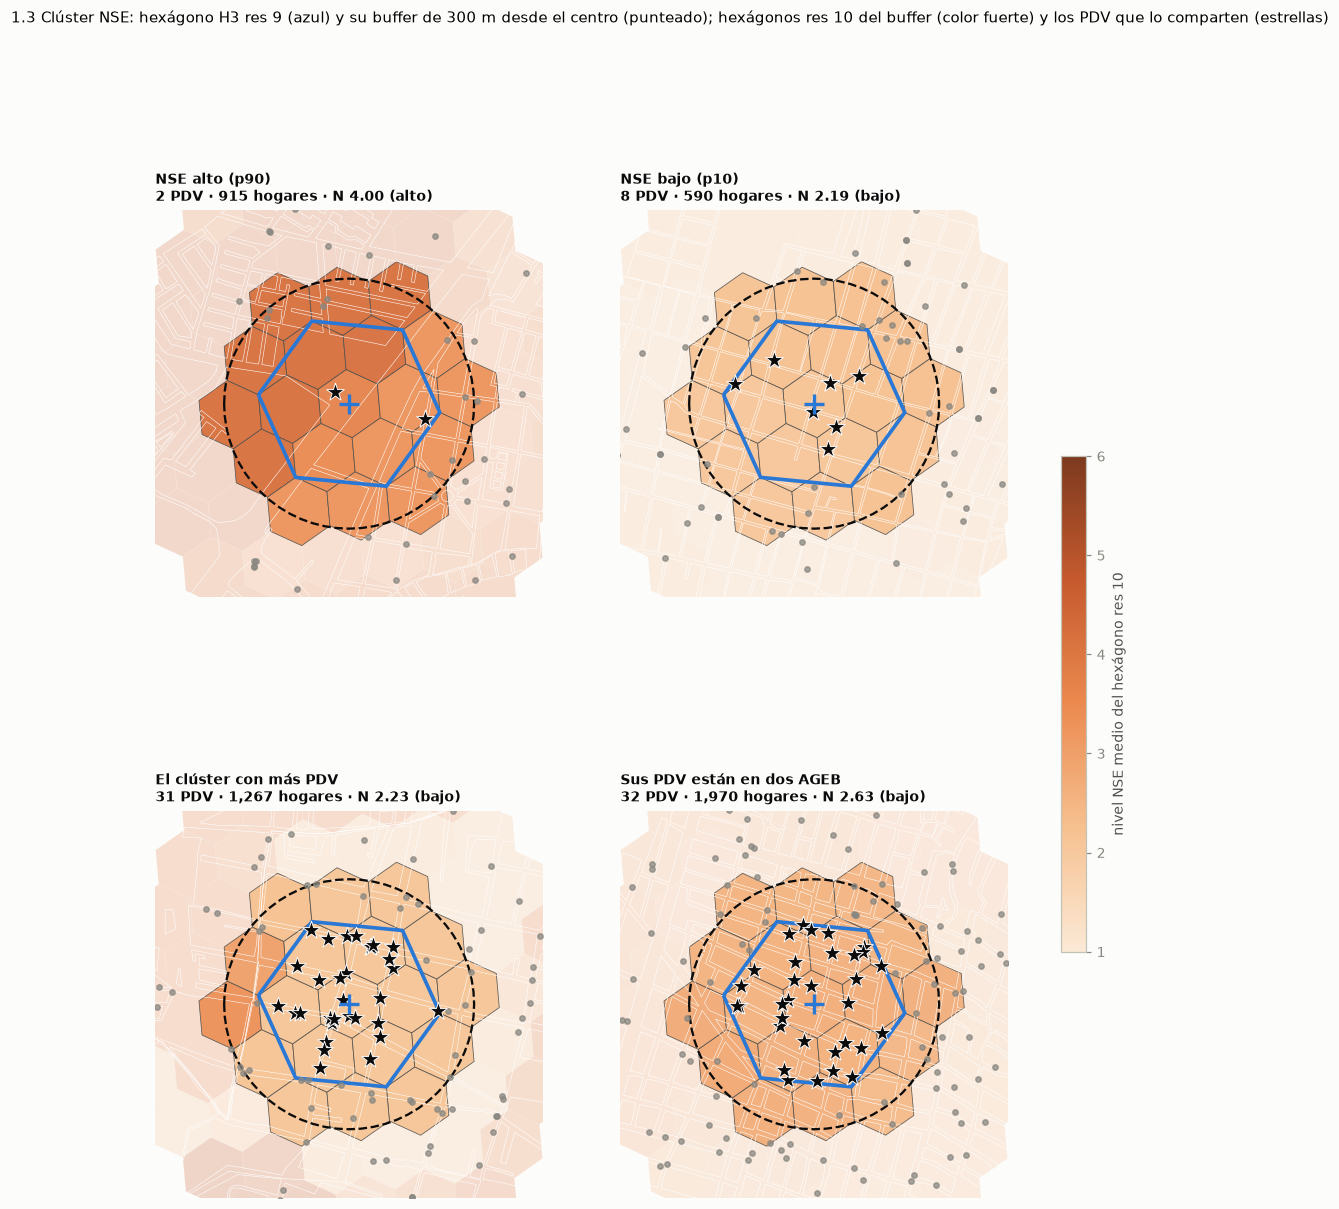

In [5]:
GRUPO_NSE = {"bajo": ["D+", "D/E"], "medio": ["C", "C-"], "alto": ["C+", "A/B"]}      # agrupación AMAI de mercado
cl["N"] = LT.nivel_medio(hh_cl)
cl["abc"] = (hh_cl["A/B"] + hh_cl["C+"]) / cl.hog.replace(0, np.nan) * 100
cw = LT.suma_area(hexg[["censo_peso"]], areas_cl).censo_peso.to_numpy()
cp_ = LT.suma_area((hexg.censo.fillna(0) * hexg.censo_peso).to_frame("p"), areas_cl).p.to_numpy()
cl["censo"] = cp_ / np.where(cw > 0, cw, np.nan)
parte = pd.DataFrame({g_: hh_cl[cs].sum(axis=1) for g_, cs in GRUPO_NSE.items()}).div(cl.hog.replace(0, np.nan), axis=0)
cl["clase"] = parte.fillna(-1).idxmax(axis=1).where(parte.notna().all(axis=1))
cl["clase_pct"] = parte.max(axis=1) * 100
for g_ in GRUPO_NSE:
    cl[f"p_{g_}"] = parte[g_] * 100
for c_, k_ in [("N_inegi", "N"), ("abc", "abc"), ("censo_area", "censo"), ("nse_clase", "clase"), ("nse_clase_pct", "clase_pct"),
               ("nse_bajo", "p_bajo"), ("nse_medio", "p_medio"), ("nse_alto", "p_alto"), ("n_cluster_nse", "n_pdv")]:
    ids[c_] = ids.cluster_nse.map(cl[k_]).to_numpy()
hh = hh_cl.reindex(ids.cluster_nse).reset_index(drop=True)                  # hogares por nivel del clúster de cada PDV
fc, lc = np.radians(ids.cluster_nse.map(cl.lat).to_numpy(float)), np.radians(ids.cluster_nse.map(cl.lon).to_numpy(float))
fp, lp = np.radians(ids.Latitud.to_numpy(float)), np.radians(ids.Longitud.to_numpy(float))
ids["dist_centro_m"] = 2 * 6_371_000 * np.arcsin(np.sqrt(np.sin((fc - fp) / 2) ** 2 + np.cos(fp) * np.cos(fc) * np.sin((lc - lp) / 2) ** 2))
ids["N_pdv"] = LT.nivel_medio(hh04)                    # QA: NSE del buffer del propio PDV (04; la regla anterior)
ids["pocos_hogares"] = ids.con_nse & (ids.HH_cluster < 100)
assert (ids.dist_centro_m <= R300).all(), "todo PDV debe quedar dentro del buffer de su clúster"
ob = ids[ids.objetivo]
clo = cl[cl.n_objetivo > 0]
rho_cb = stats.spearmanr(ob.N_inegi, ob.N_pdv, nan_policy="omit")[0]
CLUSTER_NSE = (f"{len(clo):,} clústeres NSE (hexágonos H3 res {RES_CL}) tienen PDV objetivo: mediana {clo.n_objetivo.median():.0f} PDV por clúster "
               f"(p90 {clo.n_objetivo.quantile(0.9):.0f}, máximo {clo.n_objetivo.max()}); {(clo.n_objetivo == 1).mean():.0%} tienen un solo PDV. "
               f"El PDV más lejano queda a {ids.dist_centro_m.max():.0f} m del centro de su hexágono (mediana {ids.dist_centro_m.median():.0f} m): "
               f"el buffer de {R300} m siempre lo contiene. NSE del clúster vs NSE del buffer del propio PDV: ρ = {rho_cb:.2f}; "
               f"{int((ids.con_venta & ~ids.con_nse).sum())} PDV con venta quedan en clústeres sin hogares a {R300} m "
               f"y {ob.pocos_hogares.mean():.1%} de los objetivo tienen < 100 hogares en su clúster (NSE más ruidoso).")
print(CLUSTER_NSE)
PREDOMINANTE = ("NSE predominante del clúster (el grupo con más hogares del buffer), en los PDV objetivo: " + ", ".join(
    f"{k} {v:.0%}" for k, v in ob.nse_clase.value_counts(normalize=True).reindex(list(GRUPO_NSE)).fillna(0).items())
    + f". El nivel NSE (media de 1 a 6) promedia hogares mezclados: {ob.N_inegi.between(2.5, 4.5).mean():.0%} de los PDV cae entre 2.5 y 4.5, "
      "por eso casi todo se lee 'medio'.")
print(PREDOMINANTE)
display(ob.groupby("segmento").agg(PDV=("pos_id_cp", "size"), clusteres=("cluster_nse", "nunique"), **{"N INEGI medio": ("N_inegi", "mean")},
                                   **{"% bajo": ("nse_clase", lambda s: (s == "bajo").mean() * 100)},
                                   **{"% medio": ("nse_clase", lambda s: (s == "medio").mean() * 100)},
                                   **{"% alto": ("nse_clase", lambda s: (s == "alto").mean() * 100)}).round(1))


def celda_poligono(c):
    """Polígono (EPSG:4326) de una celda H3."""
    return Polygon([(lo, la) for la, lo in h3.cell_to_boundary(c)])


cl_geo = gpd.GeoSeries([celda_poligono(c) for c in cl.index], index=cl.index, crs=4326).to_crs(CRS)
cl_ctr = gpd.GeoSeries(gpd.points_from_xy(cl.lon, cl.lat), index=cl.index, crs=4326).to_crs(CRS)


def panel_cluster(ax, c, titulo):
    """Clúster NSE: su hexágono res 9 (azul), el buffer de 300 m desde su centro (punteado), los hexágonos res 10 del buffer
    (color fuerte; fuera, tenues), las manzanas y los PDV del hexágono (estrellas; los demás PDV en gris)."""
    ctr = cl_ctr.loc[c]
    marco = ctr.buffer(R300 * 1.8)
    hx = hex_c.join(hexg[["N"]])
    hx = hx[hx.intersects(marco)]
    dentro = hx.index.isin(areas_cl[cl.index.get_loc(c)])
    hx[~dentro].plot(ax=ax, column="N", cmap=CMAP_NSE, vmin=1, vmax=6, alpha=0.25, edgecolor="white", lw=0.3, missing_kwds={"color": eda.GRID, "alpha": 0.3})
    hx[dentro].plot(ax=ax, column="N", cmap=CMAP_NSE, vmin=1, vmax=6, alpha=0.95, edgecolor=eda.TINTA_2, lw=0.5, missing_kwds={"color": eda.GRID})
    mzg[mzg.intersects(marco)].boundary.plot(ax=ax, color="white", lw=0.35)
    gpd.GeoSeries([cl_geo.loc[c]], crs=CRS).boundary.plot(ax=ax, color=MP.COLOR_L1["H"], lw=2.4)
    gpd.GeoSeries([ctr.buffer(R300)], crs=CRS).boundary.plot(ax=ax, color=eda.TINTA, lw=1.5, ls="--")
    ax.plot(ctr.x, ctr.y, marker="+", color=MP.COLOR_L1["H"], ms=13, mew=2.2, zorder=7)
    miembro = ids.cluster_nse.eq(c).to_numpy()
    pts[pts.geometry.within(marco).to_numpy() & ~miembro].plot(ax=ax, color=eda.MUTED, markersize=12, alpha=0.75, zorder=4)
    pts[miembro].plot(ax=ax, marker="*", color=eda.TINTA, markersize=150, edgecolor="white", lw=0.6, zorder=6)
    MP.encuadre(ax, ctr.x, ctr.y, R300 * 1.55)
    ax.set_axis_off()
    r = cl.loc[c]
    ax.set_title(f"{titulo}\n{int(r.n_pdv)} PDV · {r.hog:,.0f} hogares · N {r.N:.2f} ({r.clase})", fontsize=9)


cands = cl[(cl.n_objetivo >= 2) & cl.N.notna()]
n_ageb = ids.groupby("cluster_nse").AGEB.nunique()
mezcla = cands[cands.index.isin(n_ageb[n_ageb >= 2].index)]
ejemplos_1 = {"NSE alto (p90)": (cands.N - cands.N.quantile(0.9)).abs().idxmin(),
              "NSE bajo (p10)": (cands.N - cands.N.quantile(0.1)).abs().idxmin(),
              "El clúster con más PDV": cl.n_objetivo.idxmax(),
              "Sus PDV están en dos AGEB": mezcla.n_objetivo.idxmax() if len(mezcla) else cands.index[0]}
fig, ax = plt.subplots(2, 2, figsize=(12.5, 13))
for a_, (t_, c_) in zip(ax.flat, ejemplos_1.items()):
    panel_cluster(a_, c_, t_)
fig.colorbar(plt.cm.ScalarMappable(cmap=CMAP_NSE, norm=plt.Normalize(1, 6)), ax=ax, shrink=0.45, label="nivel NSE medio del hexágono res 10")
fig.suptitle("1.3 Clúster NSE: hexágono H3 res 9 (azul) y su buffer de 300 m desde el centro (punteado); hexágonos res 10 del buffer "
             "(color fuerte) y los PDV que lo comparten (estrellas)", x=0.02, ha="left", fontsize=10)
plt.show()

### 1.4 AltScore mueve el NSE del clúster

**Qué se hace:** el índice NSE AltScore (percentil 0-100 del 00b: PC1 de sus proxies digitales, elegidos por análisis de
ítems en la ZM) de los puntos AltScore que caen en el buffer de 300 m del **centro** de cada clúster; su media es $a_c$. Se
lleva a la escala de $N$ por **cuantiles** ($\tilde N_c$ = el valor de $N$ con el mismo percentil: los dos quedan con la misma
distribución) y **mueve el NSE**: $N^*_c = (1-\lambda)\,N_c + \lambda\,\tilde N_c$ con $\lambda$ = `C.ALTSCORE_PESO_NSE`,
solo en clústeres con al menos `C.ALTSCORE_MIN_PUNTOS` puntos AltScore con índice (si no, $N^*_c = N_c$). Se valida contra
INEGI en el mismo buffer (ρ con IC por bloques H3 res 7), se mide si AltScore **agrega** información al predecir el índice
del Censo por manzana (medición directa) y se prueba la Letra 1 con otros pesos.

**Por qué:** regla del usuario (2026-09-30): AltScore es una variable socioeconómica más y **sí mueve el NSE**, igual que
Rappi entra a la Letra 2. INEGI pesa más ($1-\lambda$) porque el Censo por manzana lo confirma y AltScore todavía es una escala
corta (pocos proxies, α bajo en el 00b); el peso queda por validar con el usuario. Los mismos promedios dan las señales
AltScore del clúster que van al entregable.

AltScore: 37,376 puntos en la ZM; 79% de los clústeres con PDV objetivo tienen ≥ 5 puntos con índice en su buffer (mediana 13). Índice AltScore vs NSE INEGI del clúster: ρ = +0.31 (IC95 bloques [+0.22, +0.40], 3,881 clústeres). Para predecir el índice del Censo por manzana, INEGI pesa β = +0.95 y AltScore β = -0.01 (IC95 [-0.04, +0.01]): AltScore no agrega a lo que el Censo ya confirma de INEGI; es otra lectura (digital, 2025-2026). Con λ = 0.25 AltScore cambia 2786 Letras 1 (1419 suben, 1367 bajan); con λ = 0.5, 6054; con λ = 1 (solo AltScore), 10144.


,peso de AltScore (λ),% L1 = H,PDV que suben a H,PDV que bajan a L,κ con la letra del Censo,PDV que cambian,% que cambian
0,0.00,47.74,0,0,0.84,0,0.00
1,0.10,47.68,402,416,0.82,818,3.33
2,0.25,47.95,1419,1367,0.69,2786,11.35
3,0.50,48.87,3166,2888,0.45,6054,24.66
4,0.75,48.04,4291,4216,0.25,8507,34.65
5,1.00,47.02,4984,5160,0.12,10144,41.32


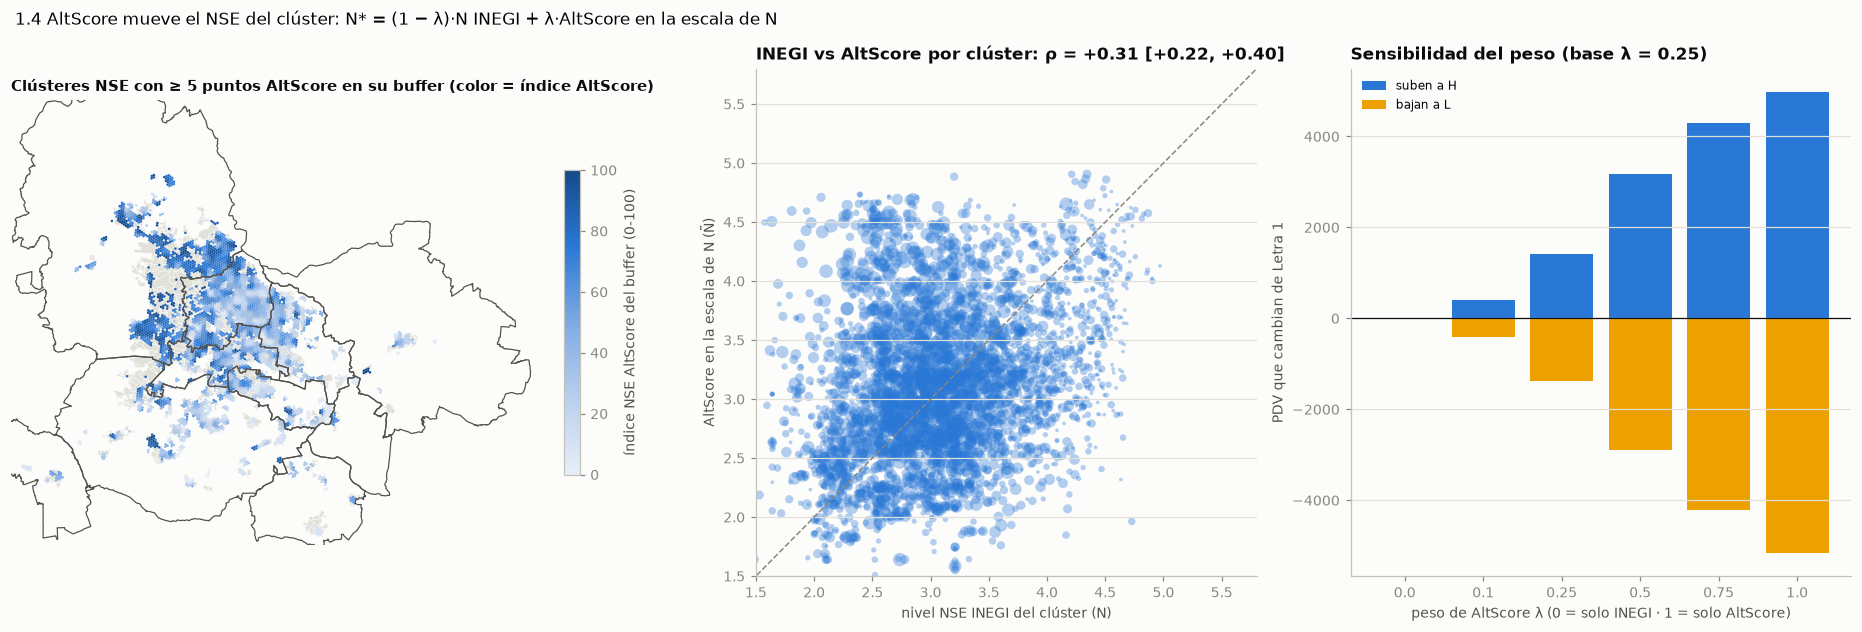

In [6]:
alt = pd.read_parquet(F_ALT) if F_ALT.exists() else pd.DataFrame()
alt_sel = pd.read_csv(F_SEL) if F_SEL.exists() else pd.DataFrame(columns=["señal", "decisión", "nombre"])
loc_alt = A.ubicacion(alt) if len(alt) else {}
USA_ALTSCORE = bool(loc_alt.get("lat") and loc_alt.get("lon") and "indice_nse_altscore" in alt)
PROX_ALT = alt_sel.loc[alt_sel["decisión"].eq("índice NSE"), "nombre"].tolist()
ALT_SEN = [c for c in alt.columns if c not in {"pos_id", "indice_nse_altscore", "zonas_por_vector_digital", *[v for v in loc_alt.values() if v]}]
cl["alt"], cl["alt_puntos"] = np.nan, 0
if USA_ALTSCORE:
    alt = alt.dropna(subset=[loc_alt["lat"], loc_alt["lon"]]).reset_index(drop=True)
    cerca_alt = R.en_radio(cl.lat.to_numpy(), cl.lon.to_numpy(), alt[loc_alt["lat"]].to_numpy(float), alt[loc_alt["lon"]].to_numpy(float), R300)
    Va = alt[["indice_nse_altscore", *ALT_SEN]].to_numpy(float)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)                     # buffer sin dato en una señal → NaN
        M_alt = np.array([np.nanmean(Va[i], axis=0) if len(i) else np.full(Va.shape[1], np.nan) for i in cerca_alt])
    cl["alt"] = M_alt[:, 0]
    for k_, c_ in enumerate(ALT_SEN):
        cl[f"alt_{c_}"] = M_alt[:, k_ + 1]
    cl["alt_puntos"] = [int(np.isfinite(Va[i, 0]).sum()) for i in cerca_alt]
cl["alt_ok"] = cl.alt_puntos >= MIN_ALT
base_cl = (cl.n_objetivo > 0) & cl.N.notna() & cl.alt_ok & cl.alt.notna()   # base del mapeo por cuantiles
cl["N_alt"] = (LT.a_escala(cl.alt.where(cl.alt_ok & cl.N.notna()), cl.N[base_cl], x_base=cl.alt[base_cl]) if base_cl.sum() > 30
               else pd.Series(np.nan, index=cl.index))
cl["N_star"] = LT.mover_nse(cl.N, cl.N_alt, LAM)
L1_censo = LT.letra_media(ids.censo_area, ids.segmento, ids.objetivo)       # letra del Censo por manzana (variante de la 1.5)
PESOS = sorted({0, 0.1, 0.25, 0.5, 0.75, 1.0, LAM})
L1_por_peso = {w_: LT.letra(LT.indice(ids.cluster_nse.map(LT.mover_nse(cl.N, cl.N_alt, w_)), ids.segmento, ids.objetivo)).where(ids.objetivo)
               for w_ in PESOS}
m_ok = ids.objetivo & L1_por_peso[0].notna()
m_cz = m_ok & L1_censo.notna()
sens_alt = pd.DataFrame([{"peso de AltScore (λ)": w_, "% L1 = H": (L_[m_ok] == "H").mean() * 100,
                          "PDV que suben a H": int(((L_ == "H") & (L1_por_peso[0] == "L"))[m_ok].sum()),
                          "PDV que bajan a L": int(((L_ == "L") & (L1_por_peso[0] == "H"))[m_ok].sum()),
                          "κ con la letra del Censo": eda.kappa_cohen(L_[m_cz], L1_censo[m_cz])} for w_, L_ in L1_por_peso.items()])
sens_alt["PDV que cambian"] = sens_alt["PDV que suben a H"] + sens_alt["PDV que bajan a L"]
sens_alt["% que cambian"] = sens_alt["PDV que cambian"] / max(m_ok.sum(), 1) * 100
sa = sens_alt.set_index("peso de AltScore (λ)")
if USA_ALTSCORE and base_cl.sum() > 30:
    bl7 = pd.Series([h3.cell_to_parent(h, 7) for h in cl.index[base_cl]], index=cl.index[base_cl])
    rho_a, lo_a, hi_a = eda.spearman_bloques(cl.alt[base_cl], cl.N[base_cl], bl7, B=300)
    vc = cl[base_cl].dropna(subset=["censo"])                                # ¿AltScore agrega algo a INEGI para predecir el Censo?

    def betas(t):
        X_ = np.column_stack([np.ones(len(t)), A.rango_normal(t.N), A.rango_normal(t.alt)])
        return np.linalg.lstsq(X_, A.rango_normal(t.censo), rcond=None)[0][1:]

    b_inegi, b_alt = betas(vc)
    rng = np.random.default_rng(eda.SEMILLA)
    blq = pd.Series([h3.cell_to_parent(h, 7) for h in vc.index]).to_numpy()
    grupos = [np.flatnonzero(blq == b_) for b_ in pd.unique(blq)]
    bs = np.array([betas(vc.iloc[np.concatenate([grupos[k] for k in rng.integers(0, len(grupos), len(grupos))])]) for _ in range(300)])
    lo_b, hi_b = np.percentile(bs[:, 1], [2.5, 97.5])
    ALT_NSE = (f"AltScore: {len(alt):,} puntos en la ZM; {cl.alt_ok[cl.n_objetivo > 0].mean():.0%} de los clústeres con PDV objetivo tienen ≥ {MIN_ALT} "
               f"puntos con índice en su buffer (mediana {np.median(cl.alt_puntos[cl.n_objetivo > 0]):.0f}). Índice AltScore vs NSE INEGI del clúster: "
               f"ρ = {rho_a:+.2f} (IC95 bloques [{lo_a:+.2f}, {hi_a:+.2f}], {int(base_cl.sum()):,} clústeres). Para predecir el índice del Censo por "
               f"manzana, INEGI pesa β = {b_inegi:+.2f} y AltScore β = {b_alt:+.2f} (IC95 [{lo_b:+.2f}, {hi_b:+.2f}]): "
               + ("AltScore agrega información propia" if lo_b > 0 else "AltScore no agrega a lo que el Censo ya confirma de INEGI; es otra lectura (digital, 2025-2026)")
               + f". Con λ = {LAM:g} AltScore cambia {int(sa.loc[LAM, 'PDV que cambian'])} Letras 1 ({int(sa.loc[LAM, 'PDV que suben a H'])} suben, "
               f"{int(sa.loc[LAM, 'PDV que bajan a L'])} bajan); con λ = 0.5, {int(sa.loc[0.5, 'PDV que cambian'])}; con λ = 1 (solo AltScore), "
               f"{int(sa.loc[1.0, 'PDV que cambian'])}.")
else:
    rho_a = lo_a = hi_a = b_inegi = b_alt = lo_b = hi_b = np.nan
    ALT_NSE = "AltScore no mueve el NSE: su exportación no trae ubicación (lat/lon) o no hay suficientes clústeres con índice (notebook 00b)."
print(ALT_NSE)
display(sens_alt.round(2))

fig, ax = plt.subplots(1, 3, figsize=(17, 5.8), gridspec_kw={"width_ratios": [1.3, 1, 1]})
MP.fondo(ax[0], mun, agebs=ageb_c)
cg = gpd.GeoDataFrame(cl[["alt", "alt_ok", "n_objetivo"]], geometry=cl_geo)
cg = cg[cg.alt_ok & (cg.n_objetivo > 0)]
if len(cg):
    cg.plot(ax=ax[0], column="alt", cmap=CMAP_CENSO, vmin=0, vmax=100, lw=0)
    plt.colorbar(plt.cm.ScalarMappable(cmap=CMAP_CENSO, norm=plt.Normalize(0, 100)), ax=ax[0], shrink=0.6, label="índice NSE AltScore del buffer (0-100)")
ax[0].set_xlim(x0 - 1500, x1 + 1500); ax[0].set_ylim(y0 - 1500, y1 + 1500)
ax[0].set_title(f"Clústeres NSE con ≥ {MIN_ALT} puntos AltScore en su buffer (color = índice AltScore)", fontsize=10)
bc = cl[base_cl]
if len(bc):
    ax[1].scatter(bc.N, bc.N_alt, s=np.clip(bc.n_objetivo * 6, 6, 80), alpha=0.35, color=eda.PALETA[0], edgecolor="none")
    ax[1].plot([1, 6], [1, 6], color=eda.MUTED, ls="--", lw=1)
    ax[1].set(xlabel="nivel NSE INEGI del clúster (N)", ylabel="AltScore en la escala de N (Ñ)", xlim=(1.5, 5.8), ylim=(1.5, 5.8),
              title=f"INEGI vs AltScore por clúster: ρ = {rho_a:+.2f} [{lo_a:+.2f}, {hi_a:+.2f}]")
ax[2].bar(sens_alt["peso de AltScore (λ)"].astype(str), sens_alt["PDV que suben a H"], color=MP.COLOR_L1["H"], label="suben a H")
ax[2].bar(sens_alt["peso de AltScore (λ)"].astype(str), -sens_alt["PDV que bajan a L"], color=MP.COLOR_L1["L"], label="bajan a L")
ax[2].axhline(0, color=eda.TINTA, lw=0.8)
ax[2].set(xlabel="peso de AltScore λ (0 = solo INEGI · 1 = solo AltScore)", ylabel="PDV que cambian de Letra 1",
          title=f"Sensibilidad del peso (base λ = {LAM:g})")
ax[2].legend(fontsize=8)
plt.suptitle("1.4 AltScore mueve el NSE del clúster: N* = (1 − λ)·N INEGI + λ·AltScore en la escala de N", x=0.01, ha="left")
plt.tight_layout(); plt.show()

### 1.5 Índice NSE y Letra 1 (sin y con AltScore, con concordancia entre variantes)

**Qué se hace:** $I^N_i = 100\,N^*_{c(i)}/\bar N^*_{s(i)}$ con la media de los PDV objetivo de su subcanal; $L1 = H$ si
$I^N \ge 100$. La **Letra 1 sin AltScore** usa $N_c$ (solo INEGI) con la misma regla. Se marca **frontera** si
$|I^N - 100| \le$ 10. Para **asegurar** la letra se recalcula con cada variante (misma regla: H si el valor ≥ media del
subcanal) y se mide la concordancia con κ de Cohen contra la letra INEGI y contra la final: % ABC+, índice del Censo del
clúster, NSE del punto, NSE de la AGEB, el buffer del propio PDV (la regla anterior), buffers de 200 y 400 m desde el centro,
AltScore solo y la cantidad de hogares (sin NSE).

**Por qué:** una letra que cambia con cualquier definición razonable no sirve para decidir; una que se sostiene sí. "NSE
confirmado" = la letra coincide con la del Censo por manzana (medición directa, independiente del modelo AMAI y de AltScore).

,variante,PDV comparables,% misma letra (INEGI),κ (INEGI),% misma letra (final),κ (final),lectura (final)
0,Letra 1 sin AltScore (solo INEGI),24548,100.00,1.00,88.65,0.77,bueno
1,% ABC+ del clúster (INEGI),24548,96.60,0.93,88.84,0.78,bueno
2,Índice del Censo por manzana (clúster),23565,92.13,0.84,84.74,0.69,bueno
3,NSE del punto (hexágono res 10 del PDV),24317,92.64,0.85,85.37,0.71,bueno
4,NSE de la AGEB del punto,23294,90.86,0.82,84.12,0.68,bueno
5,Buffer de 300 m del propio PDV (sin clúster),24493,95.82,0.92,87.14,0.74,bueno
6,Buffer de 200 m desde el centro (en vez de 300),24491,96.65,0.93,87.51,0.75,bueno
7,Buffer de 400 m desde el centro (en vez de 300),24548,97.62,0.95,88.13,0.76,bueno
8,AltScore del clúster (solo),22936,56.25,0.12,68.36,0.37,regular
9,"Hogares del clúster (cantidad, sin NSE)",24548,55.72,0.11,57.31,0.15,pobre


L1 = H en 48% de los PDV objetivo (sin AltScore 48%); AltScore cambia 2786 letras (1419 suben, 1367 bajan; λ = 0.25); frontera ±10: 50%; confirmada por el Censo por manzana en 85% (la letra solo INEGI, en 92%); igual en las 4 variantes principales (ABC+, Censo, 200 y 400 m) en 77%. κ contra la letra INEGI: % ABC+ del clúster (INEGI) 0.93, Índice del Censo por manzana (clúster) 0.84, NSE del punto (hexágono res 10 del PDV) 0.85, NSE de la AGEB del punto 0.82, Buffer de 300 m del propio PDV (sin clúster) 0.92, Buffer de 200 m desde el centro (en vez de 300) 0.93, Buffer de 400 m desde el centro (en vez de 300) 0.95, AltScore del clúster (solo) 0.12, Hogares del clúster (cantidad, sin NSE) 0.11.


,PDV,% L1 = H,% L1 = H sin AltScore,N final medio,AltScore cambia,% frontera
segmento,,,,,,
Abarrotes / Almacenes / Bodegas / Víveres,7967,45.84,47.45,3.12,926,0.53
Carnicería / Pollería / Pescadería,369,43.63,44.44,3.39,17,0.32
Cerveza y Licores,5990,49.52,48.90,3.04,757,0.52
Estanquillos / kioscos,3253,49.19,48.26,2.91,356,0.45
Farmacia Independiente,438,48.17,47.26,3.14,52,0.55
Frutas y Verduras,1020,49.12,47.75,3.03,116,0.50
Hogar con Venta,4375,49.53,47.06,2.88,464,0.45
Minisuper / Minimarket,302,44.04,46.03,3.39,20,0.33
Panadería / Pastelería,81,46.91,45.68,3.34,7,0.51


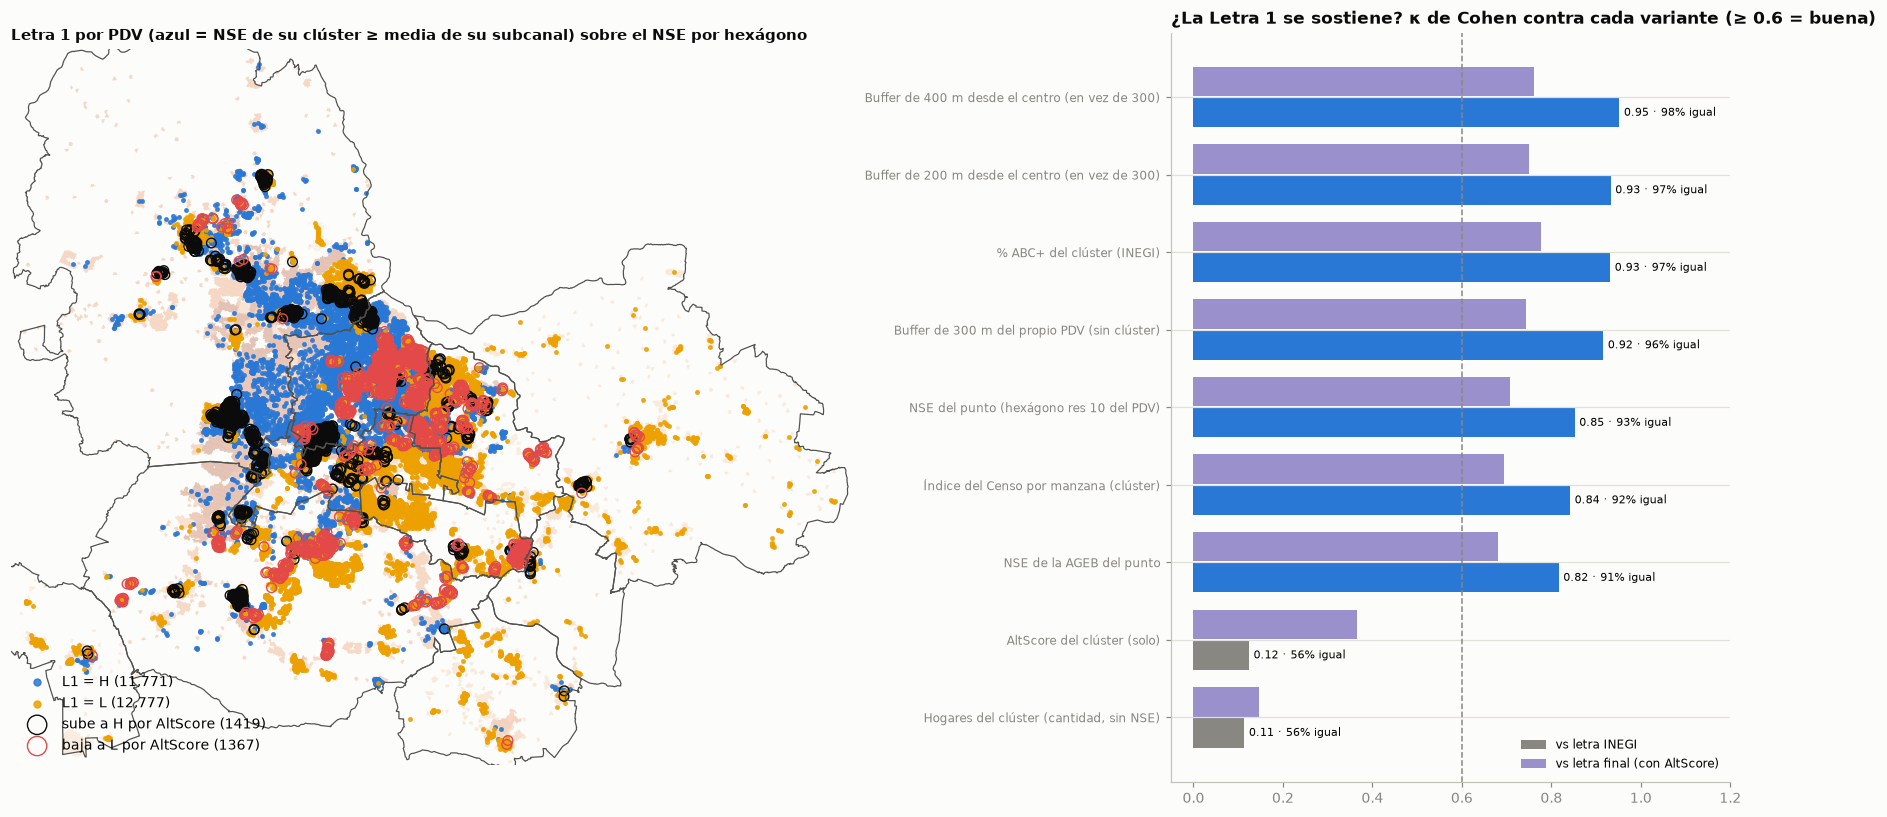

In [7]:
for c_, k_ in [("alt_cluster", "alt"), ("alt_puntos", "alt_puntos"), ("N_alt", "N_alt"), ("N", "N_star"),
               *[(f"alt_{s_}", f"alt_{s_}") for s_ in ALT_SEN if f"alt_{s_}" in cl]]:
    ids[c_] = ids.cluster_nse.map(cl[k_]).to_numpy()                        # N = N* del clúster: INEGI movido por AltScore
ids["I_N"] = LT.indice(ids.N, ids.segmento, ids.objetivo)
ids["L1"] = LT.letra(ids.I_N)
ids["I_N_inegi"] = LT.indice(ids.N_inegi, ids.segmento, ids.objetivo)
ids["L1_sin_alt"] = LT.letra(ids.I_N_inegi)
assert (ids.L1[ids.objetivo] == L1_por_peso[LAM][ids.objetivo]).all(), "la Letra 1 y su sensibilidad usan la misma regla"
ids["frontera_L1"] = (ids.I_N - 100).abs() <= FR
ids["sube_por_alt"] = ids.L1.eq("H") & ids.L1_sin_alt.eq("L")
ids["baja_por_alt"] = ids.L1.eq("L") & ids.L1_sin_alt.eq("H")
ids["cambia_por_alt"] = ids.sube_por_alt | ids.baja_por_alt
variantes = {"Letra 1 sin AltScore (solo INEGI)": ids.L1_sin_alt,
             "% ABC+ del clúster (INEGI)": LT.letra_media(ids.abc, ids.segmento, ids.objetivo),
             "Índice del Censo por manzana (clúster)": L1_censo,
             "NSE del punto (hexágono res 10 del PDV)": LT.letra_media(ids.N_punto, ids.segmento, ids.objetivo),
             "NSE de la AGEB del punto": LT.letra_media(ids.N_ageb, ids.segmento, ids.objetivo),
             f"Buffer de {R300} m del propio PDV (sin clúster)": LT.letra(LT.indice(ids.N_pdv, ids.segmento, ids.objetivo))}
for r_ in (200, 400):
    hh_r = LT.suma_area(hex_hh, LT.hexagonos_en_radio(cl.lat, cl.lon, r_, C.H3_RES)).set_axis(cl.index)
    variantes[f"Buffer de {r_} m desde el centro (en vez de {R300})"] = LT.letra(LT.indice(ids.cluster_nse.map(LT.nivel_medio(hh_r)), ids.segmento, ids.objetivo))
if USA_ALTSCORE:
    variantes["AltScore del clúster (solo)"] = LT.letra_media(ids.alt_cluster.where(ids.alt_puntos >= MIN_ALT), ids.segmento, ids.objetivo)
variantes["Hogares del clúster (cantidad, sin NSE)"] = LT.letra(LT.indice(ids.HH_cluster, ids.segmento, ids.objetivo))
conc = []
for k_, v_ in variantes.items():
    fila = {"variante": k_, "PDV comparables": int((ids.objetivo & v_.notna() & ids.L1.notna()).sum())}
    for nom, ref_ in [("INEGI", ids.L1_sin_alt), ("final", ids.L1)]:
        m = ids.objetivo & v_.notna() & ref_.notna()
        fila[f"% misma letra ({nom})"] = (v_[m] == ref_[m]).mean() * 100
        fila[f"κ ({nom})"] = eda.kappa_cohen(ref_[m], v_[m])
    conc.append(fila)
conc = pd.DataFrame(conc)
conc["lectura (final)"] = pd.cut(conc["κ (final)"], [-1, 0.2, 0.4, 0.6, 0.8, 1.01], labels=["pobre", "regular", "moderado", "bueno", "casi perfecto"])
ids["L1_censo"] = L1_censo
ESTABLES = ["% ABC+ del clúster (INEGI)", "Índice del Censo por manzana (clúster)", f"Buffer de 200 m desde el centro (en vez de {R300})",
            f"Buffer de 400 m desde el centro (en vez de {R300})"]
ids["variantes_iguales"] = sum((variantes[k] == ids.L1).astype(int) for k in ESTABLES).where(ids.L1.notna())   # 0-4: estabilidad de la letra
ids["nse_confirmado"] = np.where(ids.L1.isna() | ids.L1_censo.isna(), None, ids.L1 == ids.L1_censo)
ob = ids[ids.objetivo]
m_c = ob.L1_censo.notna()
conf_final, conf_inegi = (ob.L1[m_c] == ob.L1_censo[m_c]).mean(), (ob.L1_sin_alt[m_c] == ob.L1_censo[m_c]).mean()
display(conc.round(3))
LETRA1 = (f"L1 = H en {(ob.L1 == 'H').mean():.0%} de los PDV objetivo (sin AltScore {(ob.L1_sin_alt == 'H').mean():.0%}); AltScore cambia "
          f"{int(ob.cambia_por_alt.sum())} letras ({int(ob.sube_por_alt.sum())} suben, {int(ob.baja_por_alt.sum())} bajan; λ = {LAM:g}); frontera ±{FR}: "
          f"{ob.frontera_L1.mean():.0%}; confirmada por el Censo por manzana en {conf_final:.0%} (la letra solo INEGI, en {conf_inegi:.0%}); igual en "
          f"las 4 variantes principales (ABC+, Censo, 200 y 400 m) en {(ob.variantes_iguales == 4).mean():.0%}. κ contra la letra INEGI: "
          + ", ".join(f"{r.variante} {r['κ (INEGI)']:.2f}" for _, r in conc.iloc[1:].iterrows()) + ".")
print(LETRA1)
display(ob.groupby("segmento").agg(PDV=("L1", "size"), **{"% L1 = H": ("L1", lambda s: (s == "H").mean() * 100)},
                                   **{"% L1 = H sin AltScore": ("L1_sin_alt", lambda s: (s == "H").mean() * 100)},
                                   **{"N final medio": ("N", "mean")}, **{"AltScore cambia": ("cambia_por_alt", "sum")},
                                   **{"% frontera": ("frontera_L1", "mean")}).round(2))

fig, ax = plt.subplots(1, 2, figsize=(16, 7.5), gridspec_kw={"width_ratios": [1.5, 1]})
hx_all = hex_c.join(hexg[["N"]])
hx_all.plot(ax=ax[0], column="N", cmap=CMAP_NSE, vmin=1, vmax=6, alpha=0.35, lw=0)
g = pts[ids.objetivo].join(ids[["L1", "sube_por_alt", "baja_por_alt"]])
for l_, gg in g.groupby("L1"):
    gg.plot(ax=ax[0], color=MP.COLOR_L1[l_], markersize=5, alpha=0.85, label=f"L1 = {l_} ({len(gg):,})")
g[g.sube_por_alt].plot(ax=ax[0], color="none", edgecolor=eda.TINTA, markersize=40, lw=0.9, label=f"sube a H por AltScore ({int(g.sube_por_alt.sum())})")
g[g.baja_por_alt].plot(ax=ax[0], color="none", edgecolor=eda.PALETA[7], markersize=40, lw=0.9, label=f"baja a L por AltScore ({int(g.baja_por_alt.sum())})")
MP.fondo(ax[0], mun)
ax[0].set_xlim(x0 - 1500, x1 + 1500); ax[0].set_ylim(y0 - 1500, y1 + 1500)
ax[0].legend(loc="lower left", markerscale=2)
ax[0].set_title("Letra 1 por PDV (azul = NSE de su clúster ≥ media de su subcanal) sobre el NSE por hexágono", fontsize=10)
cc_ = conc.iloc[1:].sort_values("κ (INEGI)")
yy_ = np.arange(len(cc_))
ax[1].barh(yy_ - 0.2, cc_["κ (INEGI)"], height=0.38, color=[MP.COLOR_L1["H"] if k >= 0.6 else eda.MUTED for k in cc_["κ (INEGI)"]], label="vs letra INEGI")
ax[1].barh(yy_ + 0.2, cc_["κ (final)"], height=0.38, color=eda.PALETA[6], alpha=0.55, label="vs letra final (con AltScore)")
ax[1].set_yticks(yy_, cc_.variante)
for k_, (vk, pk) in enumerate(zip(cc_["κ (INEGI)"], cc_["% misma letra (INEGI)"])):
    ax[1].text(max(vk, 0) + 0.01, k_ - 0.2, f"{vk:.2f} · {pk:.0f}% igual", va="center", fontsize=7.5)
ax[1].axvline(0.6, color=eda.MUTED, ls="--", lw=1)
ax[1].set_xlim(-0.05, 1.2)
ax[1].legend(fontsize=8, loc="lower right")
ax[1].set_title("¿La Letra 1 se sostiene? κ de Cohen contra cada variante (≥ 0.6 = buena)")
ax[1].tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()

## 2. Letra 2 · Ventas del PDV
### 2.1 Venta media y CP del PDV (los dos del CP, con decimales)

**Qué se hace:** $V_i$ = **venta media** del PDV según el CP (`PotentialQuantitative_CustomCat_sueros`, cajas/mes) y $CP_i$ =
su **potencial** (`PotentialQuantitativeFinal_CustomCat_sueros`: cajas/mes que le faltan frente a su PDV comparable), **con
decimales**. La clase del CP (Very High → Low) sigue en el Excel.

**Por qué:** el CP ya trae la venta del PDV (regla del usuario, 2026-09-30: solo datos del CP). El potencial va con decimales
(usuario, 2026-09-30): redondear hacia abajo subestimaba la venta (0.6 cajas son varias botellas); el redondeo anterior
queda solo como comparación en el QA.

PDV objetivo: venta media del CP mediana 2.85 cajas/mes (p90 8.61); CP (potencial, con decimales) mediana 0.20, en 0 el 18% (con el redondeo anterior quedaba en 0 el 77%); ρ(venta, CP) = +0.23.


clase_cp,Very High,High,Moderate,Low,sin clase
segmento,,,,,
Abarrotes / Almacenes / Bodegas / Víveres,368,1478,2506,3615,0
Carnicería / Pollería / Pescadería,10,34,103,222,0
Cerveza y Licores,130,719,1907,3234,0
Estanquillos / kioscos,88,459,1004,1702,0
Farmacia Independiente,0,18,135,285,0
Frutas y Verduras,3,73,287,657,0
Hogar con Venta,24,242,1226,2883,0
Minisuper / Minimarket,16,44,69,173,0
Panadería / Pastelería,0,3,22,56,0


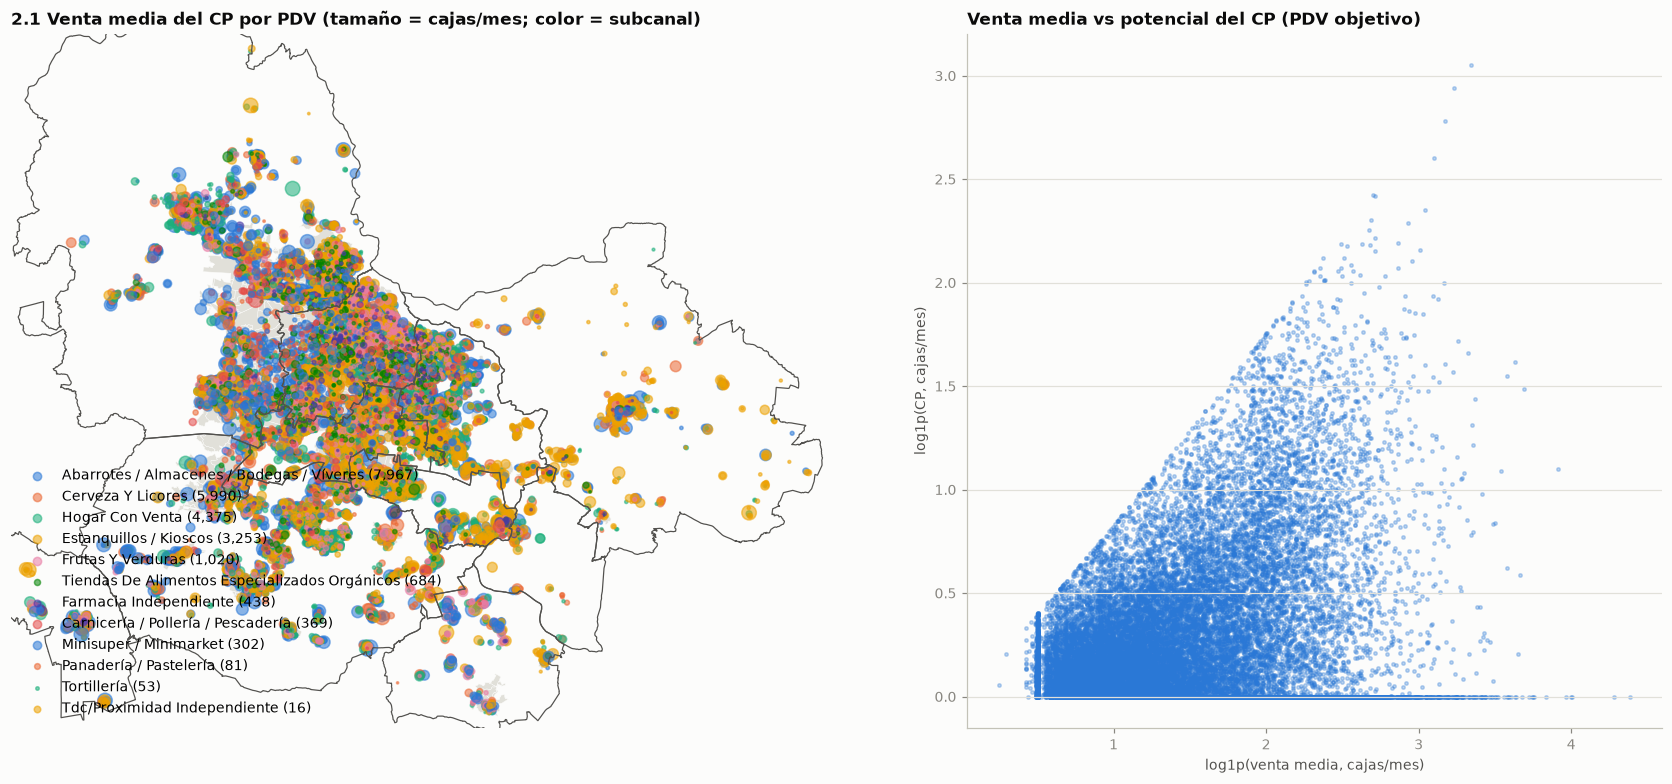

In [8]:
ids["V"] = ids.pos_id_cp.map(pdv0[f"PotentialQuantitative_{C.CP_CATEGORIA}"]).where(ids.con_venta)   # venta media del CP (cajas/mes)
ids["CP"] = ids.pos_id_cp.map(pdv0[f"PotentialQuantitativeFinal_{C.CP_CATEGORIA}"]).where(ids.con_venta)   # potencial con decimales
ids["CP_redondeado"] = LT.redondeo_cp(ids.CP, C.CP_UMBRAL_REDONDEO).to_numpy()   # solo QA: la regla anterior (cajas enteras, umbral 0.6)
ids["I_V_seg"] = LT.indice(ids.V, ids.segmento, ids.objetivo)                  # venta (CP) vs su subcanal: respaldo de Rappi
ids["clase_cp"] = ids.pos_id_cp.map(pdv0[f"PotentialQualitative_{C.CP_CATEGORIA}"])
ob = ids[ids.objetivo]
VENTA = (f"PDV objetivo: venta media del CP mediana {ob.V.median():.2f} cajas/mes (p90 {ob.V.quantile(0.9):.2f}); CP (potencial, con decimales) "
         f"mediana {ob.CP.median():.2f}, en 0 el {(ob.CP.fillna(0) == 0).mean():.0%} (con el redondeo anterior quedaba en 0 el "
         f"{(ob.CP_redondeado.fillna(0) == 0).mean():.0%}); ρ(venta, CP) = {stats.spearmanr(ob.V, ob.CP.fillna(0))[0]:+.2f}.")
print(VENTA)
display(pd.crosstab(ob.segmento, ob.clase_cp.fillna("sin clase")).reindex(columns=["Very High", "High", "Moderate", "Low", "sin clase"], fill_value=0))

SUBCANALES = ids.segmento.value_counts().index.tolist()
COLOR_SUB = {s_: eda.PALETA[k % len(eda.PALETA)] for k, s_ in enumerate(SUBCANALES)}
fig, ax = plt.subplots(1, 2, figsize=(16, 7.2), gridspec_kw={"width_ratios": [1.4, 1]})
MP.fondo(ax[0], mun, agebs=ageb_c)
g = pts[ids.objetivo].join(ids[["V", "segmento"]])
for s_ in SUBCANALES:
    gg = g[g.segmento.eq(s_)]
    gg.plot(ax=ax[0], color=COLOR_SUB[s_], markersize=np.clip(gg.V * 3, 2, 90), alpha=0.55, label=f"{s_.title()} ({len(gg):,})")
ax[0].set_xlim(x0 - 1500, x1 + 1500); ax[0].set_ylim(y0 - 1500, y1 + 1500)
ax[0].legend(loc="lower left", markerscale=0.8)
ax[0].set_title("2.1 Venta media del CP por PDV (tamaño = cajas/mes; color = subcanal)")
ax[1].scatter(np.log1p(ob.V), np.log1p(ob.CP.fillna(0)), s=5, alpha=0.3, color=eda.PALETA[0])
ax[1].set(xlabel="log1p(venta media, cajas/mes)", ylabel="log1p(CP, cajas/mes)", title="Venta media vs potencial del CP (PDV objetivo)")
plt.tight_layout(); plt.show()

### 2.2 Rappi del buffer: pedidos/mes medios de las tiendas Rappi a ≤ 300 m del PDV

**Qué se hace:** para cada PDV se toman las **tiendas físicas Rappi** del 00c (sueros e hidratación, ene-2025 → ago-2026) a
≤ 300 m y se calcula $R_i$ = **suma de sus pedidos ÷ número de tiendas** (pedidos de hidratación Coca-Cola —Powerade, Flashlyte, Vitamin Water— por mes de vida). Si no
hay ninguna, $R_i = 0$. Se usan pedidos y no pesos (usuario, 2026-10-01): mide demanda, no precio ni tamaño del ticket.
Se guardan también cuántas tiendas hay, cuántas son activas y si alguna es Turbo (dark store).

**Por qué:** regla del usuario (2026-09-30). Rappi es venta **observada** de la categoría en el área, que Bepensa no ve en su
venta. Con el promedio (no la suma) el PDV con muchas tiendas Rappi chicas no gana por cantidad, y va en pedidos:
como la Letra 2 trabaja con rangos, no hace falta pasarla a cajas (se evita suponer botellas por caja). Advertencia: un Turbo
vende a toda su zona de reparto, más allá de 300 m.

594 tiendas físicas Rappi (sueros e hidratación; 259 activas con ≥ 12 pedidos) venden en la mediana 0.7 pedidos/mes ($30 MXN/mes). 3,591 PDV objetivo (14.6%) tienen al menos una a ≤ 300 m (mediana 1 tiendas; Rappi del buffer mediana 0.6 pedidos/mes); el resto tiene Rappi = 0. 57 tiendas Rappi no tienen PDV Arca con venta a ≤ 300 m.


,nombre,tipo,municipio,pedidos_mes,pedidos,venta_mes,% sueros,turbo,activa,pdv_con_venta_300m
0,"Turbo, Fidel",Turbo (dark store),Guadalajara,160.50,3210,"8,138.20",21.20,True,True,5
1,"Turbo, Paseo del Sol",Turbo (dark store),Zapopan,122.40,2448,"5,923.70",19.20,True,True,3
3,"Turbo, Jardines de la Patria",Turbo (dark store),Zapopan,120.00,2399,"6,200.70",12.90,True,True,3
4,"Turbo, Tapatía",Turbo (dark store),Guadalajara,117.90,2358,"5,538.90",19.20,True,True,5
5,"Turbo, Solares",Turbo (dark store),Zapopan,89.00,1780,"4,727.40",19.80,True,True,1
10,"Turbo, Sauz",Turbo (dark store),San Pedro Tlaquepaque,73.80,1476,"3,835.90",18.10,True,True,10
18,"Turbo, Zapopan",Turbo (dark store),Zapopan,49.20,983,"2,406.40",16.00,True,True,0
190,"Turbo, Bugambilias",Turbo (dark store),Zapopan,19.30,116,876.50,19.70,True,True,0
22,"Chedraui, Gdl Plaza Mexico - 262_Super",Supermercado,Guadalajara,17.70,354,"1,077.10",15.40,False,True,2
6,"Turbo, Medrano",Turbo (dark store),Guadalajara,17.70,53,711.00,20.80,True,True,14


29,229 de 29,229 líneas entran (100%); 594 de 594 tiendas físicas tienen pedidos que entran


,motivo,Product_Maker_Standard,Product_Brand,subcategoria,Product_Category_3,producto,pedidos,lineas,unidades,tiendas,meses,primer_mes,ultimo_mes
10,"entra: hidratación Coca-Cola (Powerade, Flashl...",COCA-COLA,Powerade,Isotónicos (derivados),Isotónicos Líquidos,Powerade · Powerade Bebida Hidratante Sabor Moras,12231,12334,"17,336.00",490,20,2025-01,2026-08
7,"entra: hidratación Coca-Cola (Powerade, Flashl...",COCA-COLA,Powerade,Isotónicos (derivados),Isotónicos Líquidos,Powerade · Powerade Bebida Hidratante Sabor Fr...,5307,5374,"6,983.00",441,19,2025-01,2026-07
12,"entra: hidratación Coca-Cola (Powerade, Flashl...",COCA-COLA,Powerade,Isotónicos (derivados),Isotónicos Líquidos,Powerade · Powerade Bebida Isotónica Sabor Moras,1921,1931,"2,663.00",279,20,2025-01,2026-08
3,"entra: hidratación Coca-Cola (Powerade, Flashl...",COCA-COLA,Flashlyte,Sueros (hidratantes),Hidratantes Líquidos,Flashlyte · Flashlyte Bebida Regular Fresa,1594,1606,"2,568.00",236,20,2025-01,2026-08
2,"entra: hidratación Coca-Cola (Powerade, Flashl...",COCA-COLA,Flashlyte,Sueros (hidratantes),Hidratantes Líquidos,Flashlyte · Flashlyte Bebida Regular Coco Limón,1448,1455,"2,481.00",155,20,2025-01,2026-08
0,"entra: hidratación Coca-Cola (Powerade, Flashl...",COCA-COLA,Flashlyte,Sueros (hidratantes),Hidratantes Líquidos,Flashlyte · Flashlyte Bebida Hidratante Sabor ...,1276,1289,"2,148.00",188,20,2025-01,2026-08
21,"entra: hidratación Coca-Cola (Powerade, Flashl...",COCA-COLA,Powerade,Isotónicos (derivados),Isotónicos Líquidos,Powerade · Powerade Bebida Para Deportistas Sa...,984,994,"1,416.00",103,13,2025-08,2026-08
14,"entra: hidratación Coca-Cola (Powerade, Flashl...",COCA-COLA,Powerade,Isotónicos (derivados),Isotónicos Líquidos,Powerade · Powerade Bebida Isotónica con Sabor...,836,841,"1,112.00",272,20,2025-01,2026-08
5,"entra: hidratación Coca-Cola (Powerade, Flashl...",COCA-COLA,Powerade,Isotónicos (derivados),Isotónicos Líquidos,Powerade · Bebida Hidratante Powerade Frutas,816,822,"1,114.00",170,20,2025-01,2026-08
11,"entra: hidratación Coca-Cola (Powerade, Flashl...",COCA-COLA,Powerade,Isotónicos (derivados),Isotónicos Líquidos,Powerade · Powerade Bebida Isotónica,633,633,874.00,119,12,2025-01,2025-12


Trazabilidad Rappi: 06_rappi_productos_tomados_arca_zm_guadalajara.xlsx


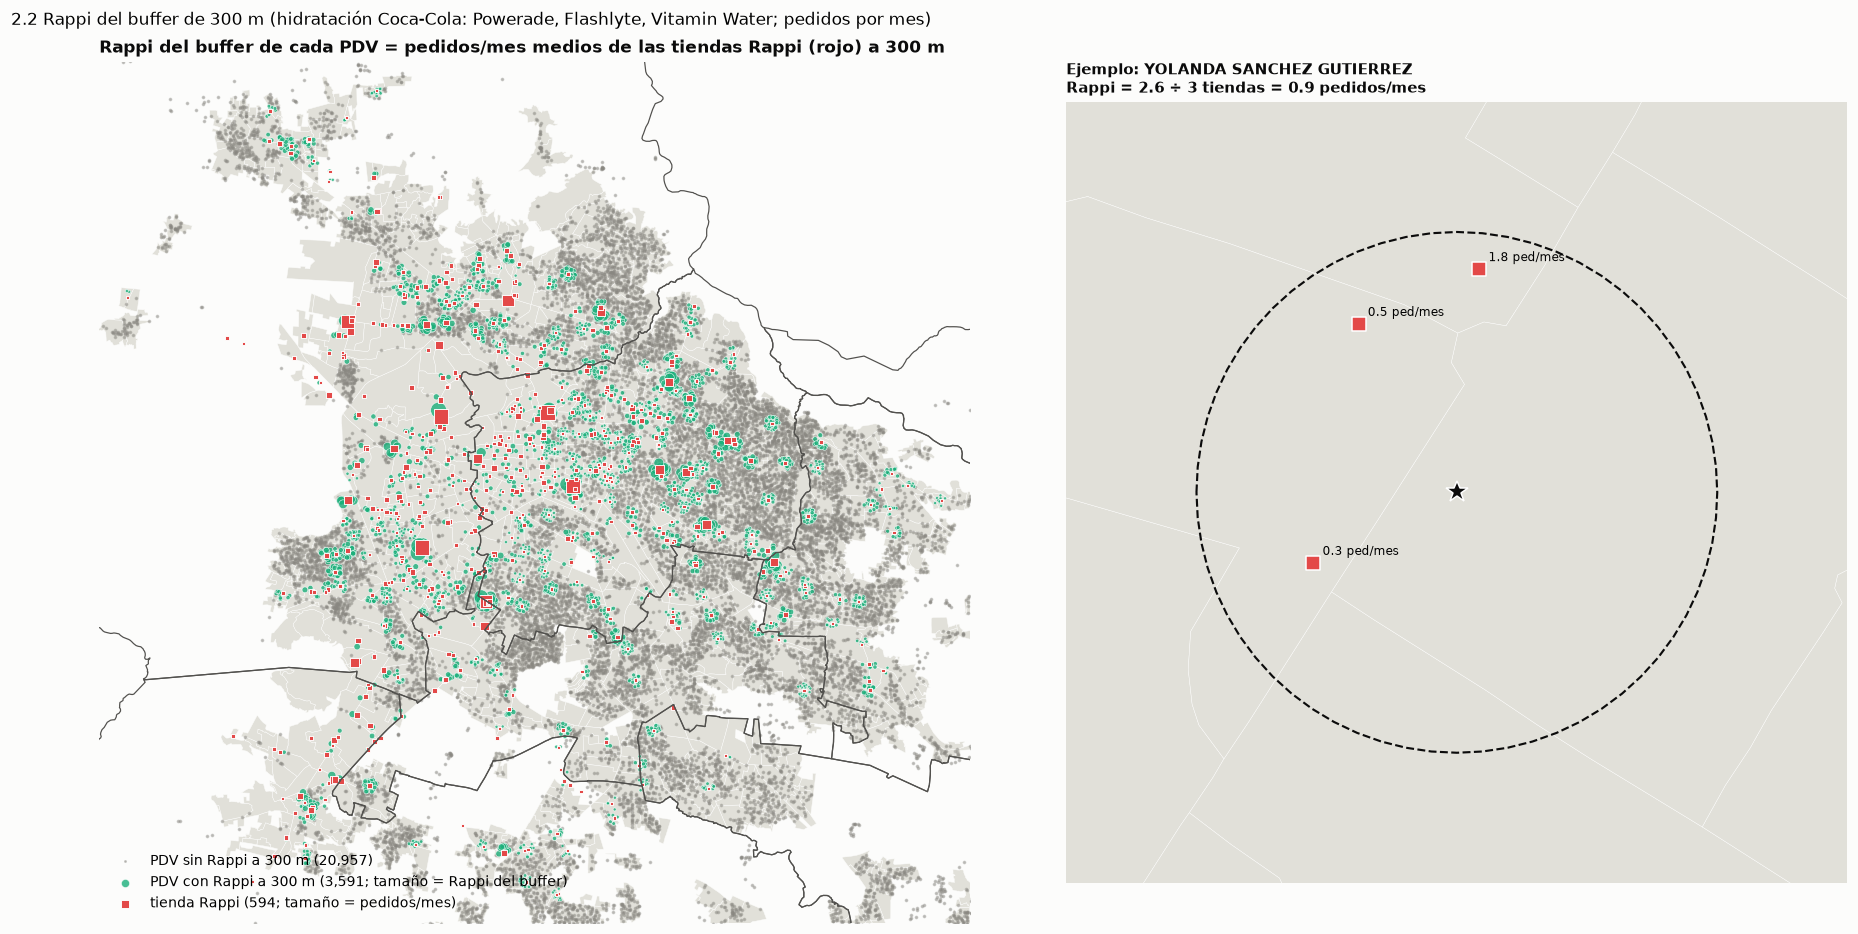

In [9]:
vr = R.en_radio(ids.Latitud, ids.Longitud, rp.lat, rp.lon, R300)             # tiendas Rappi a ≤ 300 m de cada PDV
ids["rappi_n"] = [len(x) for x in vr]
ids["rappi_media"] = [rp.pedidos_mes.to_numpy()[x].mean() if len(x) else 0.0 for x in vr]   # R_i: pedidos/mes medios de las tiendas del buffer
ids["rappi_suma"] = [rp.pedidos_mes.to_numpy()[x].sum() for x in vr]
ids["rappi_venta"] = [rp.venta_mes.to_numpy()[x].sum() for x in vr]                      # solo referencia (MXN/mes)
ids["rappi_sueros"] = [rp.venta_sueros_mes.to_numpy()[x].sum() for x in vr]
ids["rappi_activas"] = [int(rp.activa.to_numpy()[x].sum()) for x in vr]
ids["rappi_turbo"] = [bool(rp.turbo.to_numpy()[x].any()) for x in vr]
ids["rappi_tiendas"] = [", ".join(rp.nombre.to_numpy()[x][:3].astype(str)) for x in vr]
ids["P"] = (ids.rappi_n >= 1).astype(int)                                   # alguna tienda Rappi a ≤ 300 m
cv_ = ids.con_venta.to_numpy()
rp["pdv_con_venta_300m"] = [len(x) for x in R.en_radio(rp.lat, rp.lon, ids.Latitud.to_numpy()[cv_], ids.Longitud.to_numpy()[cv_], R300)]
ob = ids[ids.objetivo]
con_r = ob[ob.P == 1]
RAPPI = (f"{len(rp)} tiendas físicas Rappi (sueros e hidratación; {int(rp.activa.sum())} activas con ≥ {THETA} pedidos) venden en la mediana "
         f"{rp.pedidos_mes.median():.1f} pedidos/mes (${rp.venta_mes.median():,.0f} MXN/mes). {len(con_r):,} PDV objetivo ({ob.P.mean():.1%}) tienen al menos una a ≤ {R300} m (mediana "
         f"{con_r.rappi_n.median():.0f} tiendas; Rappi del buffer mediana {con_r.rappi_media.median():.1f} pedidos/mes); el resto tiene Rappi = 0. "
         f"{int((rp.pdv_con_venta_300m == 0).sum())} tiendas Rappi no tienen PDV {C.CLIENTE_NOMBRE} con venta a ≤ {R300} m.")
print(RAPPI)
display(rp.sort_values("pedidos_mes", ascending=False)[["nombre", "tipo", "municipio", "pedidos_mes", "pedidos", "venta_mes", "% sueros", "turbo",
                                                      "activa", "pdv_con_venta_300m"]].head(15).round(1))

# trazabilidad: qué productos de Rappi entran a la Letra 2 y cuáles no, con su motivo
lin_rp["producto"] = np.where(lin_rp.Product_Maker_Standard.eq("COCA-COLA"), lin_rp.Product_Brand + " · " + lin_rp.Product_name.fillna("(sin nombre)"),
                              lin_rp.Product_Brand.astype(str) + " · competidor anonimizado (sin nombre ni SKU)")
lin_rp["motivo"] = np.select([lin_rp.tomada, ~lin_rp.Product_Maker_Standard.eq(C.RAPPI_FABRICANTE)],
                             ["entra: hidratación Coca-Cola (" + ", ".join(C.RAPPI_MARCAS_L2) + ")", f"fuera: no es {C.RAPPI_FABRICANTE.title()} o no es una de sus marcas de hidratación"],
                             "fuera: es Coca-Cola pero no es suero (isotónico)")
agg_ = dict(pedidos=("order_code", "nunique"), lineas=("order_code", "size"), unidades=("beverage_units", "sum"), tiendas=("tienda_fisica", "nunique"),
            meses=("mes", "nunique"), primer_mes=("mes", "min"), ultimo_mes=("mes", "max"))
tr_prod = (lin_rp.groupby(["motivo", "Product_Maker_Standard", "Product_Brand", "subcategoria", "Product_Category_3", "producto"]).agg(**agg_)
           .reset_index().sort_values(["motivo", "pedidos"], ascending=[True, False]))
tr_mes = lin_rp.pivot_table(index="mes", columns="motivo", values="order_code", aggfunc="nunique", fill_value=0)
tr_mes_prod = (lin_rp[lin_rp.tomada].groupby(["mes", "producto"]).agg(pedidos=("order_code", "nunique"), unidades=("beverage_units", "sum"),
               tiendas=("tienda_fisica", "nunique")).reset_index())
tr_tienda = rp[["tienda_fisica", "nombre", "tipo", "municipio", "lat", "lon", "meses_vida", "pedidos_tomados", "pedidos_mes", "pedidos_mes_hidratacion",
                "activa", "turbo", "pdv_con_venta_300m"]].rename(columns={"pedidos_mes": "pedidos/mes tomados (Letra 2)",
                                                                          "pedidos_mes_hidratacion": "pedidos/mes hidratación (referencia)"})
reglas_rp = pd.DataFrame([("Universo", f"Rappi nacional → ZM {C.ZM_NOMBRE} por polígono, ventana {C.RAPPI_VENTANA[0]} → {C.RAPPI_VENTANA[1]} (00c)"),
                          ("Categoría", "sueros e hidratación con la regla 'sueros primero' (00c, rappi.clasificar)"),
                          ("Fabricante que entra", f"Product_Maker_Standard = {C.RAPPI_FABRICANTE} (config.RAPPI_FABRICANTE)"),
                          ("Marcas que entran", ", ".join(C.RAPPI_MARCAS_L2) + " (config.RAPPI_MARCAS_L2; cualquier subcategoría)"),
                          ("Por qué", "guiado por el CP: la categoría del cliente es sueros (CustomCat_sueros); Nielsen mide 'T. Sueros' vs 'Electrolit + Suerox'"),
                          ("Métrica", "pedidos únicos con al menos un producto que entra ÷ meses de vida de la tienda física"),
                          ("Resultado", f"{int(lin_rp.tomada.sum()):,} de {len(lin_rp):,} líneas entran ({lin_rp.tomada.mean():.0%}); "
                                        f"{int((rp.pedidos_tomados > 0).sum())} de {len(rp)} tiendas físicas tienen pedidos que entran")],
                         columns=["regla", "detalle"])
print(reglas_rp.iloc[-1].detalle)
display(tr_prod)
import excel_kin as X_
wb_rp = X_.libro()
X_.hoja_tabla(wb_rp, "Reglas", reglas_rp, titulo="Qué productos de Rappi entran a la Letra 2", ajustar=True, anchos={"regla": 24, "detalle": 110})
X_.hoja_tabla(wb_rp, "Productos", tr_prod, titulo="Productos de Rappi: entran y quedan fuera (con su motivo)", anchos={"producto": 60, "motivo": 42})
X_.hoja_tabla(wb_rp, "Por mes", tr_mes.reset_index(), titulo="Pedidos por mes según el motivo")
X_.hoja_tabla(wb_rp, "Por mes y producto", tr_mes_prod, titulo="Pedidos y unidades por mes de los productos que entran", anchos={"producto": 60})
X_.hoja_tabla(wb_rp, "Por tienda", tr_tienda.round(3), titulo="Tiendas físicas Rappi: pedidos que entran y pedidos/mes", anchos={"nombre": 44})
F_TRAZA = C.OUT / f"06_rappi_productos_tomados_{C.CLIENTE}_{C.SLUG}.xlsx"
try:
    wb_rp.save(F_TRAZA)
except PermissionError:
    F_TRAZA = F_TRAZA.with_name(F_TRAZA.stem + "_nuevo.xlsx")
    wb_rp.save(F_TRAZA)
print("Trazabilidad Rappi:", F_TRAZA.name)

ra = gpd.GeoDataFrame(rp, geometry=gpd.points_from_xy(rp.lon, rp.lat), crs=4326).to_crs(CRS)
rx0, ry0, rx1, ry1 = ra.total_bounds
fig, ax = plt.subplots(1, 2, figsize=(17, 8.6), gridspec_kw={"width_ratios": [1.35, 1]})
MP.fondo(ax[0], mun, agebs=ageb_c)
g = pts[ids.objetivo].join(ids[["rappi_media"]])
g[g.rappi_media == 0].plot(ax=ax[0], color=eda.MUTED, markersize=2, alpha=0.4, label=f"PDV sin Rappi a {R300} m ({int((g.rappi_media == 0).sum()):,})")
g[g.rappi_media > 0].plot(ax=ax[0], color=MP.COLOR_L2["H"], markersize=np.clip(np.sqrt(g.rappi_media[g.rappi_media > 0]) * 10, 4, 200), alpha=0.8,
                          edgecolor="white", lw=0.4, label=f"PDV con Rappi a {R300} m ({int((g.rappi_media > 0).sum()):,}; tamaño = Rappi del buffer)")
ra.plot(ax=ax[0], color=eda.PALETA[7], marker="s", markersize=np.clip(np.sqrt(ra.pedidos_mes) * 8, 4, 200), edgecolor="white", lw=0.6,
        label=f"tienda Rappi ({len(ra)}; tamaño = pedidos/mes)")
ax[0].set_xlim(rx0 - 1200, rx1 + 1200); ax[0].set_ylim(ry0 - 1200, ry1 + 1200)
ax[0].legend(loc="lower left", markerscale=0.7)
ax[0].set_title(f"Rappi del buffer de cada PDV = pedidos/mes medios de las tiendas Rappi (rojo) a {R300} m")
ej_r = ob[ob.rappi_n.between(2, 4)]
if len(ej_r):
    i_r = (ej_r.rappi_media - ej_r.rappi_media.median()).abs().idxmin()
    rr = ids.loc[i_r]
    xr, yr = pts.geometry.iloc[i_r].x, pts.geometry.iloc[i_r].y
    MP.fondo(ax[1], mun, agebs=ageb_c)
    gpd.GeoSeries([Point(xr, yr).buffer(R300)], crs=CRS).boundary.plot(ax=ax[1], color=eda.TINTA, lw=1.4, ls="--")
    dentro = ra.iloc[vr[i_r]]
    dentro.plot(ax=ax[1], color=eda.PALETA[7], marker="s", markersize=90, edgecolor="white", zorder=5)
    for _, t_ in dentro.iterrows():
        ax[1].annotate(f"{t_.pedidos_mes:.1f} ped/mes", (t_.geometry.x, t_.geometry.y), xytext=(6, 5), textcoords="offset points", fontsize=8)
    ax[1].plot(xr, yr, marker="*", color=eda.TINTA, ms=15, mec="white", mew=1, zorder=6)
    MP.encuadre(ax[1], xr, yr, R300 * 1.5)
    ax[1].set_axis_off()
    ax[1].set_title(f"Ejemplo: {str(rr.Nombre)[:34]}\nRappi = {rr.rappi_suma:.1f} ÷ {rr.rappi_n} tiendas = {rr.rappi_media:.1f} pedidos/mes", fontsize=10)
plt.suptitle(f"2.2 Rappi del buffer de {R300} m (hidratación Coca-Cola: Powerade, Flashlyte, Vitamin Water; pedidos por mes)", x=0.01, ha="left")
plt.tight_layout(); plt.show()

### 2.3 Tabla intermedia: el vector de cada PDV y su score

**Qué se hace:** cada PDV **con venta** tiene su vector $(V_i, CP_i, R_i)$. Cada variable se pasa a su **rango percentil
descendente** entre todos los PDV Tradicional con venta ($r = 1/n$ para el que más vende, $1$ para el que menos; los empates,
como los PDV sin Rappi, toman el rango medio) y el **score** es la media ponderada con pesos 2 · 2 · 1:
$S_i = (2\,r^V_i + 2\,r^{CP}_i + r^R_i)/5$. **H si $S_i < 0.4$**; si no, L. Los PDV **sin venta** son L y no entran al
ranking (si entraran, sus ceros comprimirían los rangos). La tabla se guarda en `data/processed/` y va en el Excel.

**Por qué:** reglas del usuario (2026-09-30). Venta, CP y Rappi no tienen la misma unidad (cajas vs pedidos) y la conversión
de Rappi a cajas dependía de un supuesto de botellas por caja; los rangos quitan las unidades y aguantan las colas largas
(min-max comprimiría casi todo cerca de 0). Rappi pesa la mitad para no castigar tanto al PDV sin tiendas Rappi cerca.

Vector de 24,632 PDV con venta. Empates: 18% con CP = 0 (rango 0.91) y 85% sin Rappi (rango 0.57). Score: mediana 0.52, 30.1% bajo 0.4. Correlación de rangos: venta-CP ρ = +0.23, venta-Rappi ρ = -0.01.


,pos_id,Nombre,segmento,venta_media,cp,tiendas_rappi_300m,rappi,rango_venta,rango_cp,rango_rappi,score,score_sin_rappi
18997,10061733,JOSE RAFAEL ALVAREZ GUTIERREZ,Cerveza y Licores,21.17,12.52,1,9.20,0.01,0.00,0.00,0.00,0.00
30877,498802,EVA SALAZAR RODRIGUEZ,Abarrotes / Almacenes / Bodegas / Víveres,16.50,6.95,3,6.94,0.02,0.00,0.01,0.01,0.01
3268,10463127,ISAAC GUILLERMO PEA VALDEZ,Abarrotes / Almacenes / Bodegas / Víveres,16.51,7.96,1,2.95,0.02,0.00,0.01,0.01,0.01
22774,496755,LUZ ELENA MEJIA PLASCENCIA,Abarrotes / Almacenes / Bodegas / Víveres,19.29,7.65,1,1.14,0.01,0.00,0.03,0.01,0.01
37785,496812,JOSE LUIS DE JESUS PADILLA MEZA,Abarrotes / Almacenes / Bodegas / Víveres,36.78,4.03,1,0.91,0.00,0.01,0.04,0.01,0.00
35557,10063881,ERNESTO GONZALEZ LLAMAS,Abarrotes / Almacenes / Bodegas / Víveres,13.29,5.12,4,20.76,0.03,0.00,0.00,0.01,0.02
21324,10715223,LUIS HUMBERTO OROZCO MORALES,Abarrotes / Almacenes / Bodegas / Víveres,15.31,3.42,1,1.60,0.02,0.01,0.02,0.02,0.02
30553,462713,ABARROTES SONI,Abarrotes / Almacenes / Bodegas / Víveres,18.67,2.70,3,1.62,0.01,0.03,0.02,0.02,0.02
15699,496005,PEDRO DE ANDA RODRIGUEZ,Estanquillos / kioscos,14.70,3.32,1,1.45,0.02,0.01,0.02,0.02,0.02
19891,460381,ARMANDO CRUZ ANGULO,Abarrotes / Almacenes / Bodegas / Víveres,15.19,4.66,1,0.67,0.02,0.01,0.06,0.02,0.01


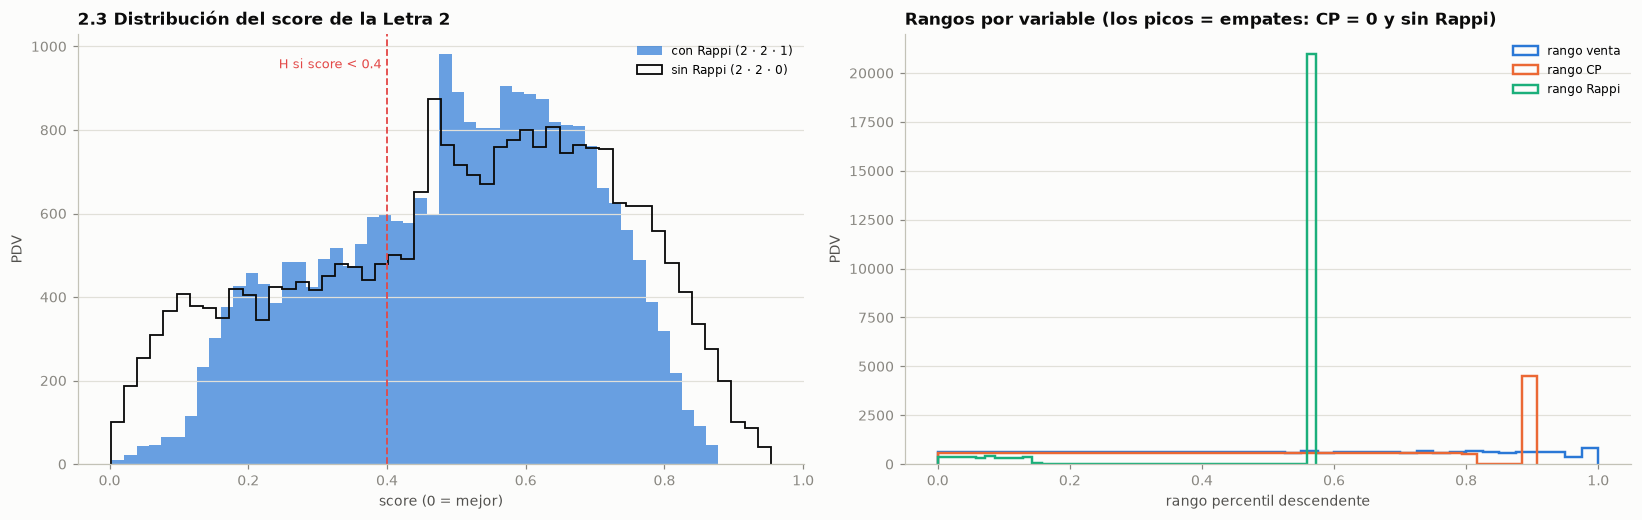

In [10]:
BASE_RANK = ids.con_venta                                                      # universo del ranking: Tradicional con venta
ids["r_V"] = LT.rango_desc(ids.V, BASE_RANK)
ids["r_CP"] = LT.rango_desc(ids.CP.fillna(0), BASE_RANK)
ids["r_R"] = LT.rango_desc(ids.rappi_media, BASE_RANK)
RANGOS = {"venta": ids.r_V, "cp": ids.r_CP, "rappi": ids.r_R}
ids["score"] = LT.score_letra2(RANGOS, PESOS_L2)
ids["score_sin_rappi"] = LT.score_letra2(RANGOS, {**PESOS_L2, "rappi": 0})
vector = ids.loc[ids.con_venta, ["pos_id_cp", "Nombre", "segmento", "V", "CP", "rappi_n", "rappi_media", "r_V", "r_CP", "r_R", "score", "score_sin_rappi"]]
vector = vector.rename(columns={"pos_id_cp": "pos_id", "V": "venta_media", "CP": "cp", "rappi_n": "tiendas_rappi_300m", "rappi_media": "rappi",
                                "r_V": "rango_venta", "r_CP": "rango_cp", "r_R": "rango_rappi"})
vector.to_parquet(C.PROC / f"letra2_vector_{C.CLIENTE}_{C.SLUG}.parquet", index=False)
ob = ids[ids.objetivo]
VECTOR = (f"Vector de {len(vector):,} PDV con venta. Empates: {(ob.CP.fillna(0) == 0).mean():.0%} con CP = 0 (rango {ob.r_CP[ob.CP.fillna(0) == 0].median():.2f}) y "
          f"{(ob.rappi_media == 0).mean():.0%} sin Rappi (rango {ob.r_R[ob.rappi_media == 0].median():.2f}). Score: mediana {ob.score.median():.2f}, "
          f"{(ob.score < CORTE).mean():.1%} bajo {CORTE}. Correlación de rangos: venta-CP ρ = {stats.spearmanr(ob.r_V, ob.r_CP)[0]:+.2f}, "
          f"venta-Rappi ρ = {stats.spearmanr(ob.r_V, ob.r_R)[0]:+.2f}.")
print(VECTOR)
display(vector.sort_values("score").head(10).round(3))

fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))
ax[0].hist(ob.score, bins=50, color=eda.PALETA[0], alpha=0.7, label="con Rappi (2 · 2 · 1)")
ax[0].hist(ob.score_sin_rappi, bins=50, histtype="step", color=eda.TINTA, lw=1.2, label="sin Rappi (2 · 2 · 0)")
ax[0].axvline(CORTE, color=eda.PALETA[7], ls="--", lw=1.2)
ax[0].text(CORTE * 0.98, ax[0].get_ylim()[1] * 0.92, f"H si score < {CORTE}", ha="right", fontsize=8.5, color=eda.PALETA[7])
ax[0].set(xlabel="score (0 = mejor)", ylabel="PDV", title="2.3 Distribución del score de la Letra 2")
ax[0].legend(fontsize=8)
for k_, (c_, e_) in enumerate([("r_V", "venta"), ("r_CP", "CP"), ("r_R", "Rappi")]):
    ax[1].hist(ob[c_], bins=40, histtype="step", lw=1.6, color=eda.PALETA[k_], label=f"rango {e_}")
ax[1].set(xlabel="rango percentil descendente", ylabel="PDV", title="Rangos por variable (los picos = empates: CP = 0 y sin Rappi)")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 2.4 ¿Rappi tiene respaldo? Venta Bepensa con y sin Rappi cerca, y sensibilidad de la regla

**Qué se hace:** dentro de cada subcanal se compara la venta de los PDV con tienda Rappi a ≤ 300 m ($P=1$) contra los que
no (δ de Cliff sobre log1p de la venta, IC95 por **bootstrap de bloques H3 res 7**: PDV cercanos comparten clientes y no son
independientes). Después se prueba la Letra 2 con otros **pesos**, otro **corte**, solo tiendas Rappi **activas**, sin los **Turbo**, la suma de
Rappi en vez de la media, el CP **redondeado** (regla anterior) y los empates en el peor rango, y se cuenta cuántas letras
cambian contra la regla base.

**Por qué:** si los PDV cerca de Rappi ya venden más, Rappi va en la misma dirección que la venta observada; si no, es una
apuesta por la demanda digital del área. La sensibilidad muestra cuántas letras dependen de cada decisión.

,subcanal,PDV con Rappi,PDV sin Rappi,mediana V con Rappi,mediana V sin Rappi,δ de Cliff,IC95 bloques,IC excluye 0,p (Mann-Whitney),q_BH
0,Abarrotes / Almacenes / Bodegas / Víveres,1231,6736,4.29,4.35,-0.02,"[-0.07, +0.04]",False,0.26,0.55
1,Carnicería / Pollería / Pescadería,118,251,1.96,1.69,0.07,"[-0.03, +0.17]",False,0.28,0.55
2,Cerveza y Licores,944,5046,2.60,2.71,-0.05,"[-0.11, +0.01]",False,0.01,0.07
3,Estanquillos / kioscos,335,2918,3.51,3.48,-0.04,"[-0.13, +0.04]",False,0.22,0.55
4,Farmacia Independiente,97,341,1.22,1.20,0.03,"[-0.11, +0.15]",False,0.65,0.72
5,Frutas y Verduras,165,855,2.13,2.09,-0.04,"[-0.14, +0.07]",False,0.47,0.63
6,Hogar con Venta,414,3961,1.55,1.61,0.01,"[-0.05, +0.07]",False,0.74,0.74
7,Minisuper / Minimarket,75,227,4.19,5.61,-0.21,"[-0.34, -0.03]",True,0.01,0.07
8,Panadería / Pastelería,22,59,1.17,1.17,-0.10,"[-0.39, +0.15]",False,0.50,0.63
9,Tiendas de Alimentos Especializados Orgánicos,175,509,1.47,1.64,-0.05,"[-0.15, +0.07]",False,0.33,0.55


Venta Arca (índice por subcanal) con vs sin Rappi a 300 m: δ = -0.03 (IC95 bloques [-0.07, +0.01]); entre los PDV con Rappi cerca, Rappi del buffer vs venta Arca: ρ = -0.00 (p = 0.82). En total la venta Arca no es mayor cerca de Rappi (subcanales con IC que excluye 0: Minisuper / Minimarket δ = -0.21): Rappi agrega información que la venta propia no tiene.


Contra la regla base, misma Letra 2 en: pesos 1·1·1 94% · pesos 2·2·0 95% · pesos 3·3·1 98% · pesos 2·1·1 93% · pesos 1·2·1 95% · corte 0.3 88% · corte 0.35 93% · corte 0.45 93% · corte 0.5 84% · Rappi solo con tiendas activas (≥ 12 pedidos) 98% · Rappi sin las tiendas Turbo (dark stores) 100% · Rappi = suma del buffer (no la media) 100% · Rappi en pesos (MXN/mes, regla anterior) 100% · CP redondeado (regla anterior, umbral 0.6) 89% · empates en el peor rango (no el medio) 91%.


,variante,% L2 = H,misma letra que la base (%),pasan a H,pasan a L,κ con la base
0,"base: pesos 2·2·1, corte 0.4",30.06,100.00,0,0,1.00
1,pesos 1·1·1,28.30,94.29,484,917,0.86
2,pesos 2·2·0,32.10,94.81,887,387,0.88
3,pesos 3·3·1,30.59,98.11,298,167,0.96
4,pesos 2·1·1,31.46,92.59,1081,737,0.83
5,pesos 1·2·1,30.51,95.00,669,558,0.88
6,corte 0.3,17.72,87.66,0,3029,0.67
7,corte 0.35,23.49,93.43,0,1613,0.83
8,corte 0.45,37.00,93.06,1704,0,0.85
9,corte 0.5,46.13,83.93,3946,0,0.67


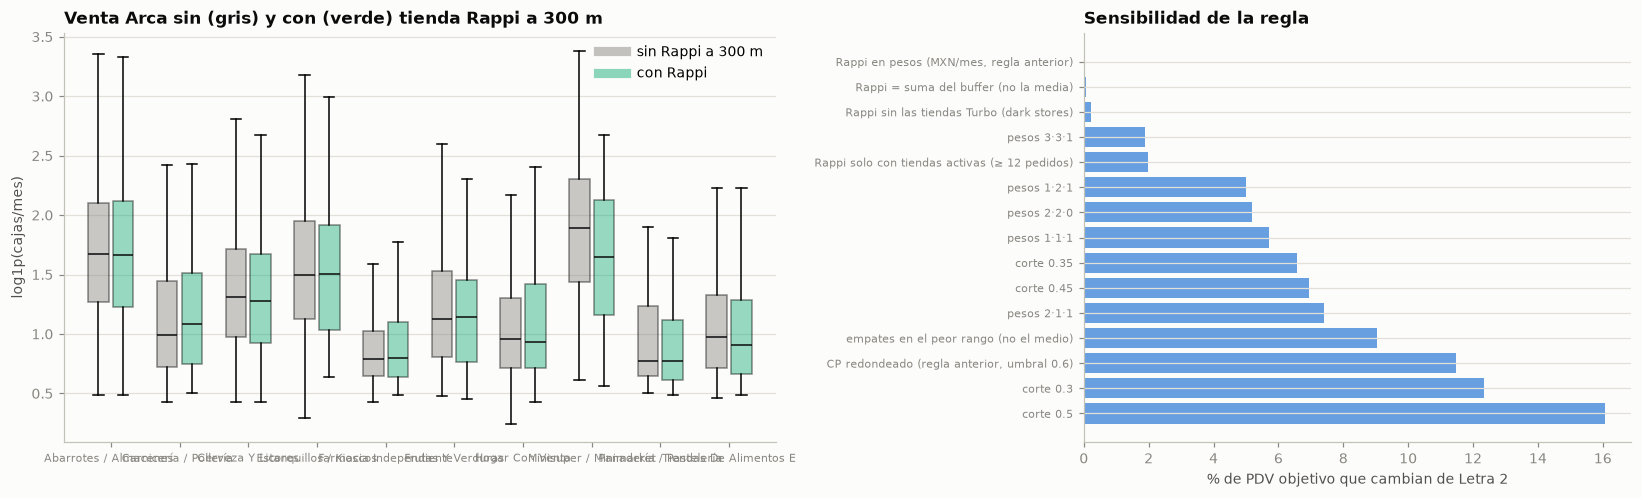

In [11]:
respaldo = []
for seg, g in ob.groupby("segmento"):
    if (g.P == 1).sum() >= 20 and (g.P == 0).sum() >= 20:
        d_, lo_, hi_ = eda.cliff_bloques(g.P == 1, np.log1p(g.V), [h3.cell_to_parent(h, 7) for h in g["Hexágono H3"]], B=300)
        respaldo.append({"subcanal": seg, "PDV con Rappi": int(g.P.sum()), "PDV sin Rappi": int((g.P == 0).sum()),
                         "mediana V con Rappi": g.V[g.P == 1].median(), "mediana V sin Rappi": g.V[g.P == 0].median(),
                         "δ de Cliff": d_, "IC95 bloques": f"[{lo_:+.2f}, {hi_:+.2f}]", "IC excluye 0": bool(lo_ > 0 or hi_ < 0),
                         "p (Mann-Whitney)": stats.mannwhitneyu(g.V[g.P == 1], g.V[g.P == 0]).pvalue})
respaldo = pd.DataFrame(respaldo)
if len(respaldo):
    respaldo["q_BH"] = stats.false_discovery_control(respaldo["p (Mann-Whitney)"], method="bh")
d_tot, lo_tot, hi_tot = eda.cliff_bloques(ob.P == 1, ob.I_V_seg, [h3.cell_to_parent(h, 7) for h in ob["Hexágono H3"]], B=300)
m_r = ob[ob.P == 1]
rho_r = stats.spearmanr(m_r.rappi_media, m_r.I_V_seg)
display(respaldo.round(3))
RESPALDO = (f"Venta {C.CLIENTE_NOMBRE} (índice por subcanal) con vs sin Rappi a {R300} m: δ = {d_tot:+.2f} (IC95 bloques [{lo_tot:+.2f}, {hi_tot:+.2f}]); "
            f"entre los PDV con Rappi cerca, Rappi del buffer vs venta {C.CLIENTE_NOMBRE}: ρ = {rho_r[0]:+.2f} (p = {rho_r[1]:.2f}). "
            + (f"La venta {C.CLIENTE_NOMBRE} ya es mayor cerca de Rappi: Rappi va en la misma dirección." if lo_tot > 0 else
               (f"En total la venta {C.CLIENTE_NOMBRE} no es mayor cerca de Rappi" + (" (subcanales con IC que excluye 0: " + ", ".join(
                   f"{r_.subcanal.title()} δ = {r_['δ de Cliff']:+.2f}" for _, r_ in respaldo[respaldo["IC excluye 0"]].iterrows()) + ")"
                   if len(respaldo) and respaldo["IC excluye 0"].any() else "") + ": Rappi agrega información que la venta propia no tiene.")
               if hi_tot >= 0 else f"La venta {C.CLIENTE_NOMBRE} es MENOR cerca de Rappi: Rappi va contra la venta observada (revisar)."))
print(RESPALDO)


def letra2_de(pesos=PESOS_L2, corte=CORTE, V_=None, CP_=None, R_=None, empates="average"):
    """Letra 2 (H/L) con la regla del score: rangos descendentes en los PDV con venta, media ponderada, H si score < corte;
    el PDV sin venta es L (solo PDV con NSE)."""
    V_ = ids.V if V_ is None else V_
    CP_ = ids.CP if CP_ is None else CP_
    R_ = ids.rappi_media if R_ is None else R_
    rk = {k: pd.Series(np.asarray(x, float), index=ids.index).fillna(0).where(BASE_RANK).rank(ascending=False, method=empates, pct=True)
          for k, x in [("venta", V_), ("cp", CP_), ("rappi", R_)]}
    sc = LT.score_letra2(rk, pesos)
    return pd.Series(np.where(sc < corte, "H", "L"), index=ids.index).where(ids.con_nse)


OBJ = ids.objetivo
base_ = letra2_de()


def fila_sens(variante, l2_):
    """Una fila de la sensibilidad: % H y cuántas letras cambian contra la regla base (PDV objetivo)."""
    a, b = l2_[OBJ], base_[OBJ]
    return {"variante": variante, "% L2 = H": (a == "H").mean() * 100, "misma letra que la base (%)": (a == b).mean() * 100,
            "pasan a H": int(((a == "H") & (b == "L")).sum()), "pasan a L": int(((a == "L") & (b == "H")).sum()), "κ con la base": eda.kappa_cohen(b, a)}


act_ = rp.activa.to_numpy()
R_act = np.array([rp.pedidos_mes.to_numpy()[x][act_[x]].mean() if act_[x].any() else 0.0 for x in vr])
no_t = ~rp.turbo.to_numpy()
R_sin_turbo = np.array([rp.pedidos_mes.to_numpy()[x][no_t[x]].mean() if no_t[x].any() else 0.0 for x in vr])
sens = pd.DataFrame([fila_sens(f"base: pesos 2·2·1, corte {CORTE}", base_)]
                    + [fila_sens(f"pesos {p_['venta']:g}·{p_['cp']:g}·{p_['rappi']:g}", letra2_de(pesos=p_))
                       for p_ in [{"venta": 1, "cp": 1, "rappi": 1}, {"venta": 2, "cp": 2, "rappi": 0}, {"venta": 3, "cp": 3, "rappi": 1},
                                  {"venta": 2, "cp": 1, "rappi": 1}, {"venta": 1, "cp": 2, "rappi": 1}]]
                    + [fila_sens(f"corte {c_}", letra2_de(corte=c_)) for c_ in (0.3, 0.35, 0.45, 0.5)]
                    + [fila_sens(f"Rappi solo con tiendas activas (≥ {THETA} pedidos)", letra2_de(R_=R_act)),
                       fila_sens("Rappi sin las tiendas Turbo (dark stores)", letra2_de(R_=R_sin_turbo)),
                       fila_sens("Rappi = suma del buffer (no la media)", letra2_de(R_=ids.rappi_suma)),
                       fila_sens("Rappi en pesos (MXN/mes, regla anterior)", letra2_de(R_=[rp.venta_mes.to_numpy()[x].mean() if len(x) else 0.0 for x in vr])),
                       fila_sens(f"CP redondeado (regla anterior, umbral {C.CP_UMBRAL_REDONDEO})", letra2_de(CP_=ids.CP_redondeado)),
                       fila_sens("empates en el peor rango (no el medio)", letra2_de(empates="max"))])
SENS = ("Contra la regla base, misma Letra 2 en: " + " · ".join(f"{r.variante} {r['misma letra que la base (%)']:.0f}%" for _, r in sens.iloc[1:].iterrows()) + ".")
print(SENS)
display(sens.round(2))

fig, ax = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={"width_ratios": [1.3, 1]})
segs = respaldo.subcanal.tolist() if len(respaldo) else []
for k_, seg in enumerate(segs):
    g = ob[ob.segmento.eq(seg)]
    for dx, (pp, col) in zip((-0.18, 0.18), [(0, eda.MUTED), (1, MP.COLOR_L2["H"])]):
        ax[0].boxplot(np.log1p(g.V[g.P == pp]), positions=[k_ + dx], widths=0.3, showfliers=False, patch_artist=True,
                      boxprops=dict(facecolor=col, alpha=0.45), medianprops=dict(color=eda.TINTA))
ax[0].set_xticks(range(len(segs)), [s_.title()[:22] for s_ in segs], fontsize=7.5)
ax[0].set(ylabel="log1p(cajas/mes)", title=f"Venta {C.CLIENTE_NOMBRE} sin (gris) y con (verde) tienda Rappi a {R300} m")
ax[0].legend(handles=[Line2D([], [], color=eda.MUTED, lw=6, alpha=0.5), Line2D([], [], color=MP.COLOR_L2["H"], lw=6, alpha=0.5)],
             labels=[f"sin Rappi a {R300} m", "con Rappi"], loc="upper right")
ss = sens.iloc[1:].sort_values("misma letra que la base (%)")
ax[1].barh(range(len(ss)), 100 - ss["misma letra que la base (%)"], color=eda.PALETA[0], alpha=0.7)
ax[1].set_yticks(range(len(ss)), ss.variante, fontsize=7.5)
ax[1].set(xlabel="% de PDV objetivo que cambian de Letra 2", title="Sensibilidad de la regla")
plt.tight_layout(); plt.show()

### 2.5 Letra 2

**Qué se hace:** $L2 = H$ si el score $S_i < 0.4$; si no, $L$; el PDV sin venta es $L$. La **Letra 2 sin Rappi** usa la misma
regla con pesos 2 · 2 · 0. Se marcan la frontera ($|S_i-0.4|\le 0.04$, el mismo ±10% relativo que en la Letra 1) y los PDV
que **suben o bajan por Rappi**. QA: cuántas letras cambian sin el CP, con el CP redondeado y sin Rappi.

**Por qué:** el score ordena a cada PDV frente a todos los PDV Tradicional con venta; un score menor a 0.4 es, en promedio
ponderado, estar en el 40% de arriba. Rappi puede subir o bajar una letra: el que tiene Rappi fuerte cerca sube y el que no
tiene queda en el rango medio de Rappi.

,comparación,% misma Letra 2,κ de Cohen
0,sin el CP (pesos 2·0·1),80.61,0.56
1,con el CP redondeado (umbral 0.6),88.54,0.72
2,sin Rappi (pesos 2·2·0),94.81,0.88


L2 = H en 30.1% de los PDV objetivo (sin Rappi 32.1%); Rappi cambia 1274 letras (387 suben y 887 bajan); frontera ±0.04: 10.7%. 14,519 PDV sin venta quedan L. Misma letra sin el CP (pesos 2·0·1) 81%, con el CP redondeado (umbral 0.6) 89%, sin Rappi (pesos 2·2·0) 95%.


,PDV,% L2 = H,% H sin Rappi,suben por Rappi,bajan por Rappi,score mediano
segmento,,,,,,
Abarrotes / Almacenes / Bodegas / Víveres,7967,45.27,47.40,162,331,0.43
Carnicería / Pollería / Pescadería,369,19.24,19.24,7,7,0.57
Cerveza y Licores,5990,27.70,29.93,107,241,0.53
Estanquillos / kioscos,3253,34.25,37.57,32,140,0.49
Farmacia Independiente,438,6.16,5.48,7,4,0.64
Frutas y Verduras,1020,16.27,17.25,18,28,0.59
Hogar con Venta,4375,11.79,13.85,29,119,0.64
Minisuper / Minimarket,302,41.06,40.73,5,4,0.48
Panadería / Pastelería,81,7.41,6.17,1,0,0.63


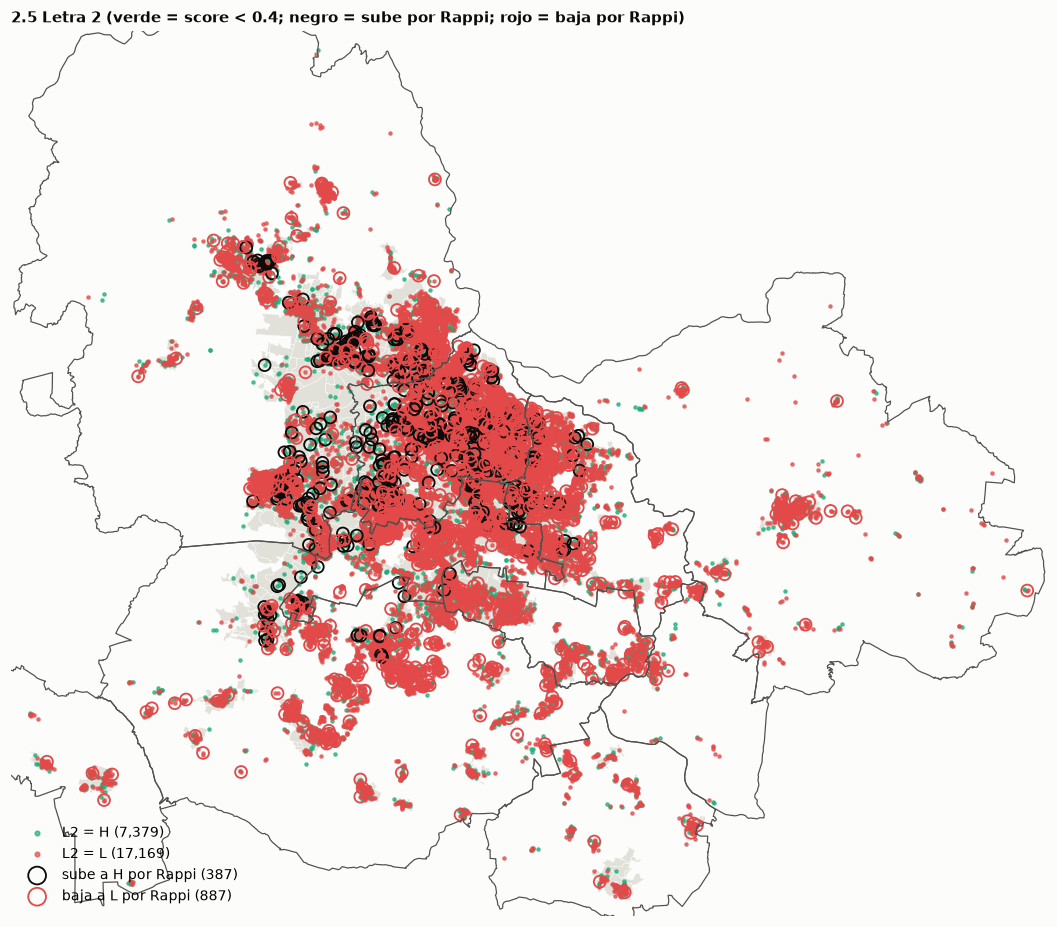

In [12]:
ids["L2"] = pd.Series(np.where(ids.score < CORTE, "H", "L"), index=ids.index).where(ids.con_nse)   # sin venta → L (score NaN)
ids["L2_sin_rappi"] = pd.Series(np.where(ids.score_sin_rappi < CORTE, "H", "L"), index=ids.index).where(ids.con_nse)
ids["L2_sin_cp"] = letra2_de(pesos={**PESOS_L2, "cp": 0})
ids["L2_cp_redondeado"] = letra2_de(CP_=ids.CP_redondeado)
ids["frontera_L2"] = ids.objetivo & ((ids.score - CORTE).abs() <= CORTE * FR / 100)
ids["sube_por_rappi"] = ids.objetivo & ids.L2.eq("H") & ids.L2_sin_rappi.eq("L")
ids["baja_por_rappi"] = ids.objetivo & ids.L2.eq("L") & ids.L2_sin_rappi.eq("H")
ids["cambia_por_rappi"] = ids.sube_por_rappi | ids.baja_por_rappi
ob = ids[ids.objetivo]
assert (ob.L2 == base_[ids.objetivo]).all(), "la Letra 2 y su sensibilidad usan la misma regla"
assert ids.L2[ids.con_nse & ~ids.con_venta].eq("L").all(), "el PDV sin venta es L"
qa_l2 = pd.DataFrame([{"comparación": k, "% misma Letra 2": (ob.L2 == ob[c]).mean() * 100, "κ de Cohen": eda.kappa_cohen(ob.L2, ob[c])}
                      for k, c in [("sin el CP (pesos 2·0·1)", "L2_sin_cp"), (f"con el CP redondeado (umbral {C.CP_UMBRAL_REDONDEO})", "L2_cp_redondeado"),
                                   ("sin Rappi (pesos 2·2·0)", "L2_sin_rappi")]])
display(qa_l2.round(3))
LETRA2 = (f"L2 = H en {(ob.L2 == 'H').mean():.1%} de los PDV objetivo (sin Rappi {(ob.L2_sin_rappi == 'H').mean():.1%}); Rappi cambia "
          f"{int(ob.cambia_por_rappi.sum())} letras ({int(ob.sube_por_rappi.sum())} suben y {int(ob.baja_por_rappi.sum())} bajan); frontera ±{CORTE * FR / 100:.2f}: "
          f"{ob.frontera_L2.mean():.1%}. {int((ids.con_nse & ~ids.con_venta).sum()):,} PDV sin venta quedan L. Misma letra "
          + ", ".join(f"{r.comparación} {r['% misma Letra 2']:.0f}%" for _, r in qa_l2.iterrows()) + ".")
print(LETRA2)
display(ob.groupby("segmento").agg(PDV=("L2", "size"), **{"% L2 = H": ("L2", lambda s: (s == "H").mean() * 100)},
                                   **{"% H sin Rappi": ("L2_sin_rappi", lambda s: (s == "H").mean() * 100)},
                                   **{"suben por Rappi": ("sube_por_rappi", "sum")}, **{"bajan por Rappi": ("baja_por_rappi", "sum")},
                                   **{"score mediano": ("score", "median")}).round(2))

fig, ax = plt.subplots(figsize=(10, 8.5))
MP.fondo(ax, mun, agebs=ageb_c)
g = pts[ids.objetivo].join(ids[["L2", "sube_por_rappi", "baja_por_rappi"]])
for l_, gg in g.groupby("L2"):
    gg.plot(ax=ax, color=MP.COLOR_L2[l_], markersize=4, alpha=0.7, label=f"L2 = {l_} ({len(gg):,})")
g[g.sube_por_rappi].plot(ax=ax, color="none", edgecolor=eda.TINTA, markersize=60, lw=1.2, label=f"sube a H por Rappi ({int(g.sube_por_rappi.sum())})")
g[g.baja_por_rappi].plot(ax=ax, color="none", edgecolor=eda.PALETA[7], markersize=60, lw=1.2, label=f"baja a L por Rappi ({int(g.baja_por_rappi.sum())})")
ax.set_xlim(x0 - 1500, x1 + 1500); ax.set_ylim(y0 - 1500, y1 + 1500)
ax.legend(loc="lower left", markerscale=1.5)
ax.set_title(f"2.5 Letra 2 (verde = score < {CORTE}; negro = sube por Rappi; rojo = baja por Rappi)", fontsize=10)
plt.tight_layout(); plt.show()

## 3. Letras juntas con su acción Golden Stores: base (INEGI + CP) y final (con AltScore y Rappi)

**Qué se hace:** el código es Letra 1 + Letra 2 (HH, HL, LH, LL) con su acción fija de Golden Stores (Atacar, Bloquear,
Fortalecer, Mantener). Las **letras base** usan solo INEGI y el CP (Letra 1 sin AltScore + Letra 2 sin Rappi); las
**finales**, la Letra 1 movida por AltScore y la Letra 2 con Rappi. Los PDV sin venta (con NSE) llevan su Letra 1 y L en la
Letra 2; el resumen se calcula sobre los PDV objetivo (con venta).

**Por qué:** así se ve qué PDV cambian de acción por AltScore y por Rappi, las dos fuentes que mueven las letras.

Prioridad: Letra 1 × share Whisp · P1 12,600 · P2 7,230 · P3 9,379 · P4 9,858


share Whisp,alto,bajo,sin dato Whisp
Letra 1,,,
H,3922,7752,97
L,6078,6156,543


,acción,tiendas,cajas,media,N_medio,hogares,% tiendas,% mix ventas,Index ventas,% con Rappi
letras,,,,,,,,,,
HH,Atacar,3669,"24,529.90",6.70,3.50,999.70,14.90,24.40,163.10,32.90
HL,Bloquear,8102,"22,732.80",2.80,3.40,"1,103.80",33.00,22.60,68.40,19.50
LH,Fortalecer,3710,"25,660.80",6.90,2.70,808.00,15.10,25.50,168.70,9.30
LL,Mantener,9067,"27,704.50",3.10,2.60,896.80,36.90,27.50,74.50,5.10


letras finales (con AltScore y Rappi),HH,HL,LH,LL
letras base (INEGI + CP),,,,
HH,2967,316,416,61
HL,283,6786,17,873
LH,404,55,3205,455
LL,15,945,72,7678


,A/B,C+,C,C-,D+,D/E
letras,,,,,,
HH,15.40,18.90,18.70,15.90,12.20,18.90
HL,14.10,17.80,18.30,16.30,12.90,20.60
LH,7.10,10.60,14.10,15.90,16.50,35.80
LL,6.80,10.30,13.90,15.90,16.60,36.60


,A/B,C+,C,C-,D+,D/E
letras,,,,,,
HH,111.00,111.00,109.00,104.00,94.00,80.00
HL,102.00,104.00,106.00,106.00,100.00,87.00
LH,51.00,62.00,82.00,104.00,128.00,151.00
LL,49.00,60.00,80.00,103.00,129.00,155.00


Tradicional: HH 15% de tiendas / 24% de venta, HL 33% de tiendas / 23% de venta, LH 15% de tiendas / 26% de venta, LL 37% de tiendas / 28% de venta. AltScore y Rappi cambian las letras de 16% de los PDV frente a las letras base (solo INEGI + CP): AltScore 2786 Letras 1 y Rappi 1274 Letras 2.


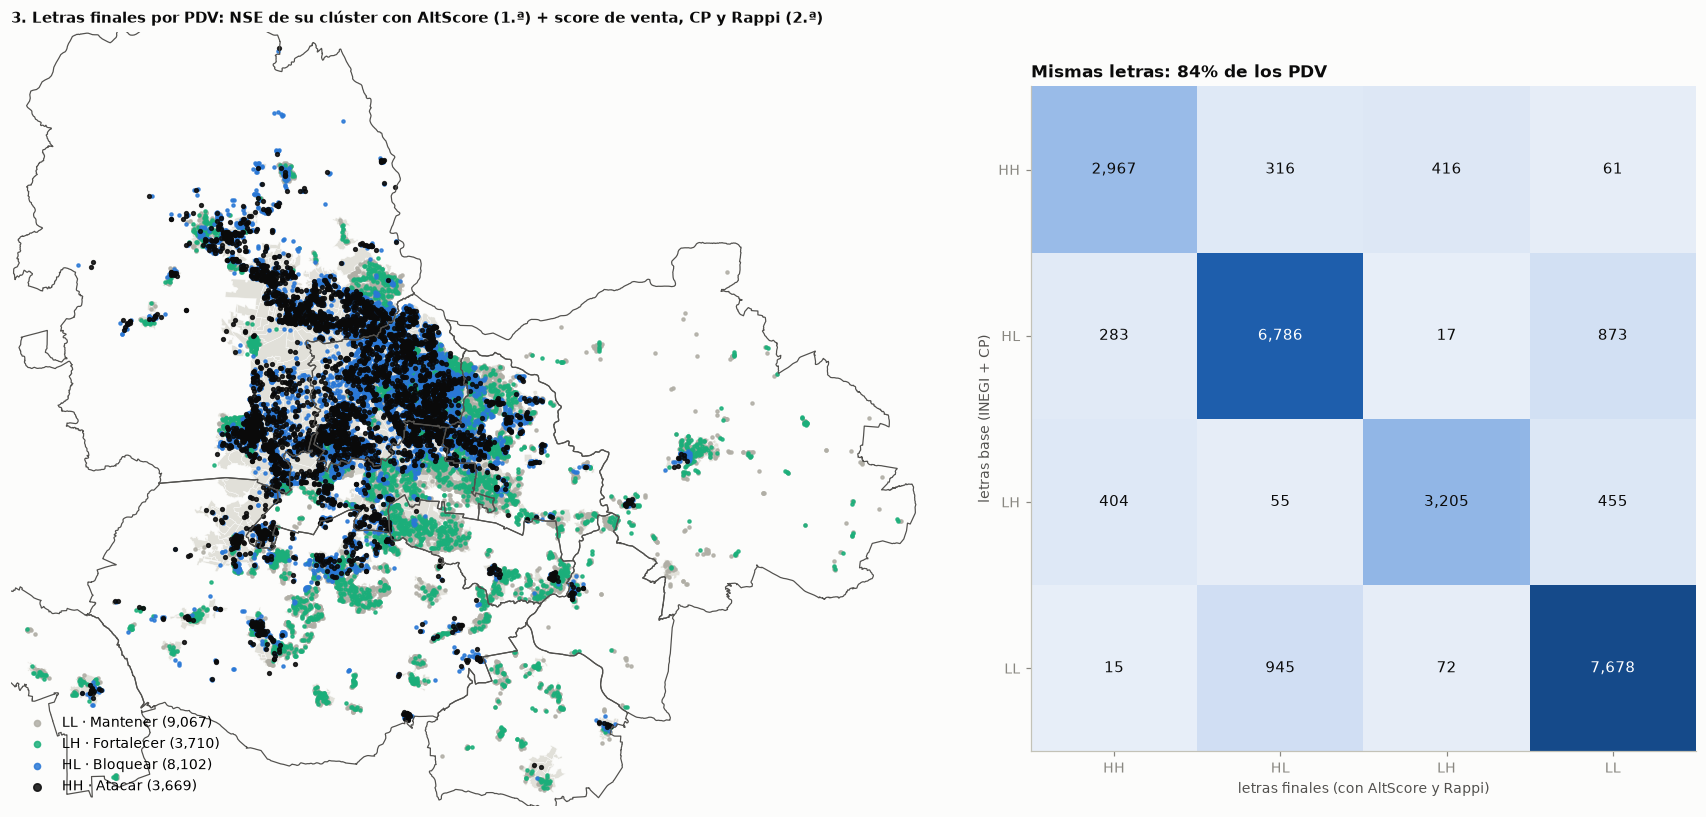

In [13]:
ids["letras"] = (ids.L1.fillna("") + ids.L2.fillna("")).where(ids.con_nse)          # sin venta: L1 + L
ids["letras_sin_rappi"] = (ids.L1.fillna("") + ids.L2_sin_rappi.fillna("")).where(ids.con_nse)
ids["letras_base"] = (ids.L1_sin_alt.fillna("") + ids.L2_sin_rappi.fillna("")).where(ids.con_nse)   # solo INEGI + CP
ids["accion"] = ids.letras.map(LT.ACCION).where(ids.con_venta, "sin venta (prospección)")
# prioridad (usuario): con share de Coca-Cola de Whisp (paso 07) = Letra 1 × share (H bajo P1 · H alto P2 · L bajo P3 · L alto P4);
# sin Whisp para el área o para el hexágono del PDV = por letras (HH P1 · HL P2 · LH P3 · LL P4), con o sin venta
F_WHISP = C.PROC / f"whisp_share_{C.CLIENTE}_{C.SLUG}.parquet"
WH = pd.read_parquet(F_WHISP).drop_duplicates("pos_id_cp").set_index("pos_id_cp") if F_WHISP.exists() else None
USA_WHISP = WH is not None and bool(WH.whisp_disponible.any()) and WH.share_cajas.notna().any()
for c_, w_ in [("share_ko", "share_cajas"), ("share_ko_revenue", "share_revenue"), ("indice_share", "indice_share"), ("share_clase", "share_clase")]:
    ids[c_] = ids.pos_id_cp.map(WH[w_]) if USA_WHISP else np.nan
pr_share = pd.Series([LT.PRIORIDAD_SHARE.get((l1, sc)) for l1, sc in zip(ids.L1, ids.share_clase)], index=ids.index)
ids["prioridad"] = pr_share.where(pr_share.notna() & ids.con_nse, ids.letras.map(LT.PRIORIDAD))
ids["fuente_prioridad"] = np.select([pr_share.notna() & ids.con_nse, ids.letras.notna()],
                                    ["Letra 1 × share Whisp", "letras (Whisp sin datos para el área)" if not USA_WHISP else "letras (sin venta en Whisp en su hexágono)"],
                                    "sin NSE")
print(f"Prioridad: {'Letra 1 × share Whisp' if USA_WHISP else 'por letras (Whisp sin datos para ' + C.ZM_NOMBRE + ')'} · "
      + " · ".join(f"{k} {v:,}" for k, v in ids.prioridad.value_counts().sort_index().items()))
SHARE_AREA_TXT = (f"{WH.share_area.dropna().iloc[0]:.1%}" if USA_WHISP and "share_area" in WH else "ver el Excel del 07")
ETQ = (lambda c: f"{c} · {LT.ACCION[c]}") if USA_WHISP else (lambda c: f"{c} · {LT.PRIORIDAD[c]} · {LT.ACCION[c]}")
ids["accion_base"] = ids.letras_base.map(LT.ACCION)
ob = ids[ids.objetivo]
CL = ["HH", "HL", "LH", "LL"]
panorama = ob.groupby("letras").agg(tiendas=("pos_id_cp", "size"), cajas=("V", "sum"), media=("V", "mean"), N_medio=("N", "mean"),
                                    hogares=("HH_cluster", "median"), con_rappi=("P", "mean")).reindex(CL)
panorama["% tiendas"] = panorama.tiendas / panorama.tiendas.sum() * 100
panorama["% mix ventas"] = panorama.cajas / panorama.cajas.sum() * 100
panorama["Index ventas"] = panorama.media / ob.V.mean() * 100
panorama["% con Rappi"] = panorama.con_rappi * 100
panorama.insert(0, "acción", [LT.ACCION[c] for c in CL])
if not USA_WHISP:
    panorama.insert(0, "prioridad", [LT.PRIORIDAD[c] for c in CL])
PRIO_TAB = (pd.crosstab(ob.L1.rename("Letra 1"), ob.share_clase.fillna("sin dato Whisp").rename("share Whisp"), values=ob.pos_id_cp, aggfunc="count")
            if USA_WHISP else None)
if USA_WHISP:
    display(PRIO_TAB)
panorama = panorama.drop(columns=["con_rappi"])
display(panorama.round(1))
cruce = pd.crosstab(ob.letras_base.rename("letras base (INEGI + CP)"), ob.letras.rename("letras finales (con AltScore y Rappi)")).reindex(index=CL, columns=CL, fill_value=0)
display(cruce)
igual = (ob.letras == ob.letras_base).mean()
perfil_nse = pd.DataFrame({c: hh.loc[ob.index, c] for c in NSE}).groupby(ob.letras).sum()
perfil_nse = perfil_nse.div(perfil_nse.sum(axis=1), axis=0) * 100
indice_nse = perfil_nse.div(REF, axis=1) * 100
display(perfil_nse.round(1).reindex(CL))
display(indice_nse.round(0).reindex(CL))
LETRAS = ("Tradicional: " + ", ".join(f"{c} {panorama.loc[c, '% tiendas']:.0f}% de tiendas / {panorama.loc[c, '% mix ventas']:.0f}% de venta"
                                      for c in CL if pd.notna(panorama.loc[c, "tiendas"]))
          + f". AltScore y Rappi cambian las letras de {1 - igual:.0%} de los PDV frente a las letras base (solo INEGI + CP): "
            f"AltScore {int(ob.cambia_por_alt.sum())} Letras 1 y Rappi {int(ob.cambia_por_rappi.sum())} Letras 2.")
print(LETRAS)

fig, ax = plt.subplots(1, 2, figsize=(16, 7.5), gridspec_kw={"width_ratios": [1.5, 1]})
MP.fondo(ax[0], mun, agebs=ageb_c)
g = pts[ids.objetivo].join(ids[["letras"]])
for c in ["LL", "LH", "HL", "HH"]:
    gg = g[g.letras == c]
    gg.plot(ax=ax[0], color=MP.COLOR_CLUSTER[c], markersize=6 if c == "HH" else 4, alpha=0.85, label=f"{ETQ(c)} ({len(gg):,})")
ax[0].set_xlim(x0 - 1500, x1 + 1500); ax[0].set_ylim(y0 - 1500, y1 + 1500)
ax[0].legend(loc="lower left", markerscale=2)
ax[0].set_title("3. Letras finales por PDV: NSE de su clúster con AltScore (1.ª) + score de venta, CP y Rappi (2.ª)", fontsize=10)
ax[1].imshow(cruce.to_numpy(), cmap=CMAP_CENSO)
for a in range(4):
    for b_ in range(4):
        ax[1].text(b_, a, f"{cruce.iloc[a, b_]:,}", ha="center", va="center", fontsize=10, color="white" if cruce.iloc[a, b_] > cruce.to_numpy().max() * 0.5 else eda.TINTA)
ax[1].set_xticks(range(4), CL); ax[1].set_yticks(range(4), CL)
ax[1].set(xlabel="letras finales (con AltScore y Rappi)", ylabel="letras base (INEGI + CP)", title=f"Mismas letras: {igual:.0%} de los PDV")
ax[1].grid(False)
plt.tight_layout(); plt.show()

## 4. Mapa interactivo de QA (canal Tradicional, con filtro por subcanal)

Mismos pasos que arriba, en el navegador: cada paso enciende sus capas y explica qué se hace, por qué y la fórmula; las
casillas de **Subcanal** muestran u ocultan los PDV. Clic en un **hexágono de clúster** o en un **PDV**: su clúster NSE (el
hexágono en azul, su centro y los PDV que lo comparten) y, en un PDV, su buffer de 300 m con los PDV con venta (en negro,
referencia) y las tiendas Rappi (rojo: su venta media es la variable Rappi); la ficha trae el vector, los rangos y el score.
Búsqueda por ID o nombre. Se guarda en `outputs/<ciudad>/<cliente>/` (lleva datos del
cliente: no se sube a git ni se publica).

In [14]:
for g_, cs in GRUPO_NSE.items():                                              # % bajo / medio / alto para los tooltips del mapa
    ageb[f"p_{g_}"] = (ageb[[f"HHs_{c}" for c in cs]].sum(axis=1) / ageb[[f"HHs_{c}" for c in NSE]].sum(axis=1).replace(0, np.nan) * 100).round(0)
    hexg[f"p_{g_}"] = (hex_hh[cs].sum(axis=1) / hex_hh.sum(axis=1).replace(0, np.nan) * 100).round(0)
ageb_js = ageb.to_crs(4326)[["CVEGEO", "N", "p_bajo", "p_medio", "p_alto", "geometry"]].assign(N=lambda t: t.N.round(2))
ageb_js["geometry"] = ageb_js.geometry.simplify(0.00004)
mun_js = mun.to_crs(4326)[["NOMGEO", "geometry"]].assign(geometry=lambda t: t.geometry.simplify(0.0002))
hex_js = hexg[["N", "censo", "Total HHs", "p_bajo", "p_medio", "p_alto"]].round(2).rename(columns={"Total HHs": "hog"})
hex_js = hex_js[(hex_js.hog > 0) | hex_js.index.isin(ids["Hexágono H3"])]
l1_cl = ob.groupby("cluster_nse").L1.agg(lambda s: " · ".join(f"{k} {v}" for k, v in s.value_counts().sort_index().items()))
clv = cl[cl.hog > 0].copy()
cl_js = pd.DataFrame({"N": clv.N.round(2), "alt": clv.alt.round(0), "Nf": clv.N_star.round(2), "n_pdv": clv.n_pdv, "hog": clv.hog.round(0),
                      "p_bajo": clv.p_bajo.round(0), "p_medio": clv.p_medio.round(0), "p_alto": clv.p_alto.round(0)}, index=clv.index)
# Whisp (opcional): share de Coca-Cola por hexágono H3 res 6 para la capa y el paso de prioridad del mapa
whisp_js = (WH[WH.share_cajas.notna()].groupby("hex6").agg(share=("share_cajas", "first"), clase=("share_clase", "first"))
            .assign(share=lambda t: (t.share * 100).round(1)) if USA_WHISP else pd.DataFrame(columns=["share", "clase"]))
clusters_js = pd.DataFrame({"cl": clv.index, "lat": clv.lat.round(6), "lon": clv.lon.round(6), "n_pdv": clv.n_pdv, "n_obj": clv.n_objetivo,
                            "hog": clv.hog.round(0), "N": clv.N.round(2), "clase": clv.clase, "abc": clv.abc.round(1), "censo": clv.censo.round(0),
                            "alt": clv.alt.round(0), "puntos": clv.alt_puntos, "N_alt": clv.N_alt.round(2), "Nf": clv.N_star.round(2),
                            "l1": l1_cl.reindex(clv.index).fillna("—").to_numpy(), "p_bajo": clv.p_bajo.round(0), "p_medio": clv.p_medio.round(0),
                            "p_alto": clv.p_alto.round(0)})
rappi_js = rp[["nombre", "tipo", "municipio", "lat", "lon", "pedidos_mes", "venta_mes", "venta_sueros_mes", "pdv_con_venta_300m", "pedidos", "% sueros",
                "% Coca-Cola", "activa", "turbo"]].round({"lat": 6, "lon": 6, "pedidos_mes": 1, "venta_mes": 0, "venta_sueros_mes": 0, "% sueros": 1, "% Coca-Cola": 1})
bepensa_js = pd.DataFrame({"id": ids.pos_id_cp.astype(str), "lat": ids.Latitud.round(6), "lon": ids.Longitud.round(6)})[ids.con_venta.to_numpy()]
ESC_NSE = {"tipo": "continua", "min": 1, "max": 6, "colores": MP.SECUENCIAL, "bajo": "1 = D/E", "alto": "6 = A/B"}
DIST_NSE3 = [["Bajo (D+ y D/E)", "p_bajo", MP.COLOR_NSE3["bajo"]], ["Medio (C y C−)", "p_medio", MP.COLOR_NSE3["medio"]],
             ["Alto (C+ y A/B)", "p_alto", MP.COLOR_NSE3["alto"]]]              # barra de distribución en los tooltips
ESC_CENSO = {"tipo": "continua", "min": 0, "max": 100, "colores": MP.AZULES, "bajo": "0", "alto": "100"}
POPUP = {"pdv": [("ID PDV", "id"), ("Nombre", "nombre"), ("Subcanal", "segmento"), ("Clúster NSE (H3 res 9)", "cl"), ("PDV del clúster NSE", "ncln"),
                 ("Distancia al centro del clúster (m)", "dcen"), ("Hogares del clúster (buffer de 300 m)", "hog"),
                 ("NSE del punto (hexágono res 10)", "N_punto"), ("NSE de su AGEB", "N_ageb"), ("Nivel NSE INEGI del clúster (1-6)", "Ni"),
                 ("NSE predominante (bajo / medio / alto)", "clase"), ("% ABC+ del clúster", "abc"), ("Índice Censo del clúster (0-100)", "censo"),
                 ("Índice AltScore del clúster (0-100)", "alt"), ("NSE AltScore en escala 1-6", "N_alt"),
                 (f"Nivel NSE final = {1 - LAM:g}·INEGI + {LAM:g}·AltScore", "N"), ("I^N (índice NSE)", "I_N"), ("Letra 1 sin AltScore", "L1s"),
                 ("Letra 1 con AltScore (final)", "L1"), ("NSE confirmado por el Censo", "conf"),
                 ("V venta media del CP (cajas/mes)", "V"), ("CP potencial (cajas/mes, con decimales)", "CP"),
                 ("Tiendas Rappi a 300 m", "nR"), ("Rappi = pedidos/mes medios de esas tiendas", "Rmed"), ("Pedidos/mes totales del buffer", "Rs"), ("Venta Rappi del buffer (MXN/mes, referencia)", "R"),
                 ("Rango venta (0 = mejor)", "rV"), ("Rango CP", "rCP"), ("Rango Rappi", "rR"),
                 (f"Score = ({PESOS_L2['venta']}·venta + {PESOS_L2['cp']}·CP + {PESOS_L2['rappi']}·Rappi) / {sum(PESOS_L2.values())}", "S"), ("Score sin Rappi", "Ss"),
                 ("Letra 2 sin Rappi", "L2s"), ("Letra 2 con Rappi (final)", "L2"), ("Letras base (INEGI + CP)", "lb"), ("Letras finales", "letras"),
                 ("Share KO Whisp (hexágono res 6)", "share"), ("Share alto / bajo (vs área)", "share_clase"), ("Fuente de la prioridad", "fuente_prio"),
                 ("Prioridad", "prioridad"), ("Acción", "accion"), ("Clase CP", "clase_cp")],
         "clusters": [("Clúster NSE (H3 res 9)", "cl"), ("PDV en el hexágono", "n_pdv"), ("PDV objetivo", "n_obj"),
                      ("Hogares del buffer de 300 m", "hog"), ("Nivel NSE INEGI (1-6)", "N"), ("NSE predominante", "clase"), ("% ABC+", "abc"),
                      ("Índice Censo (0-100)", "censo"), ("Índice AltScore (0-100)", "alt"), ("Puntos AltScore con índice en el buffer", "puntos"),
                      ("NSE AltScore en escala 1-6", "N_alt"), (f"Nivel NSE final = {1 - LAM:g}·INEGI + {LAM:g}·AltScore", "Nf"),
                      ("Letra 1 de sus PDV objetivo", "l1")],
         "rappi": [("Tienda Rappi", "nombre"), ("Tipo", "tipo"), ("Municipio", "municipio"), ("Pedidos/mes de hidratación Coca-Cola (Powerade, Flashlyte, Vitamin Water)", "pedidos_mes"),
                   ("Venta sueros e hidratación (MXN/mes)", "venta_mes"),
                   ("de sueros (MXN/mes)", "venta_sueros_mes"), ("PDV con venta a 300 m", "pdv_con_venta_300m"),
                   ("Pedidos en la ventana", "pedidos"), ("% sueros", "% sueros"), ("% Coca-Cola", "% Coca-Cola"),
                   (f"Activa (≥ {THETA} pedidos)", "activa"), ("Turbo (dark store)", "turbo")]}
EXTRA_CL = [["PDV del hexágono", "n_pdv"], ["Hogares del buffer", "hog"], ["Nivel INEGI", "N"], ["Índice AltScore", "alt"], ["Nivel final", "Nf"]]
COLOR_PRIO = {"P1": MP.COLOR_CLUSTER["HH"], "P2": MP.COLOR_CLUSTER["HL"], "P3": MP.COLOR_CLUSTER["LH"], "P4": MP.COLOR_CLUSTER["LL"]}
ETQ_PRIO = ({"P1": "P1 · Letra 1 H y share Coca-Cola bajo", "P2": "P2 · Letra 1 H y share alto", "P3": "P3 · Letra 1 L y share bajo",
             "P4": "P4 · Letra 1 L y share alto"} if USA_WHISP else {k: f"{k} · {c}" for c, k in LT.PRIORIDAD.items()})
CAPAS = [
    {"id": "pdv_prio", "nombre": "PDV: prioridad " + ("(Letra 1 × share Whisp)" if USA_WHISP else "(por letras)"), "tipo": "puntos",
     "dataset": "pdv", "campo": "prioridad", "radio_px": 5, "escala": {"tipo": "categorica", "colores": COLOR_PRIO, "etiquetas": ETQ_PRIO}},
    {"id": "municipios", "nombre": "Límite municipal", "tipo": "contorno", "fuente": "municipios", "siempre": True},
    {"id": "ageb_N", "nombre": "Nivel NSE de la AGEB (media 1-6)", "tipo": "poligonos", "fuente": "agebs", "campo": "N", "etiqueta": "CVEGEO", "escala": ESC_NSE,
     "distribucion": DIST_NSE3},
    {"id": "hex_N", "nombre": "Nivel NSE del hexágono res 10 (media 1-6)", "tipo": "hex", "campo": "N", "escala": ESC_NSE, "distribucion": DIST_NSE3},
    {"id": "hex_censo", "nombre": "Índice del Censo por manzana (0-100)", "tipo": "hex", "campo": "censo", "escala": ESC_CENSO},
    {"id": "cl_N", "nombre": "Clúster NSE: nivel INEGI de su buffer (media 1-6)", "tipo": "hex", "fuente": "cl", "campo": "N", "escala": ESC_NSE,
     "borde": True, "opacidad": 0.7, "distribucion": DIST_NSE3, "extra": EXTRA_CL, "seleccion": "clusters"},
    {"id": "cl_alt", "nombre": "Clúster NSE: índice AltScore de su buffer (0-100)", "tipo": "hex", "fuente": "cl", "campo": "alt", "escala": ESC_CENSO,
     "borde": True, "opacidad": 0.7, "extra": EXTRA_CL, "seleccion": "clusters"},
    {"id": "cl_Nf", "nombre": "Clúster NSE: nivel final INEGI + AltScore (media 1-6)", "tipo": "hex", "fuente": "cl", "campo": "Nf", "escala": ESC_NSE,
     "borde": True, "opacidad": 0.7, "distribucion": DIST_NSE3, "extra": EXTRA_CL, "seleccion": "clusters"},
    {"id": "pdv_Np", "nombre": "PDV: NSE del punto", "tipo": "puntos", "dataset": "pdv", "campo": "N_punto", "escala": ESC_NSE, "radio_px": 5},
    {"id": "pdv_clase", "nombre": "PDV: NSE predominante de su clúster", "tipo": "puntos", "dataset": "pdv", "campo": "clase", "radio_px": 5,
     "escala": {"tipo": "categorica", "colores": MP.COLOR_NSE3,
                "etiquetas": {"bajo": "bajo (D+ y D/E)", "medio": "medio (C y C−)", "alto": "alto (C+ y A/B)"}}},
    {"id": "pdv_conf", "nombre": "PDV: ¿NSE confirmado por el Censo?", "tipo": "puntos", "dataset": "pdv", "campo": "conf", "radio_px": 5,
     "escala": {"tipo": "categorica", "colores": {"Sí": "#1baf7a", "No": "#e34948"}, "etiquetas": {"Sí": "la letra del Censo coincide", "No": "NSE a revisar"}}},
    {"id": "pdv_alt", "nombre": "PDV: ¿AltScore cambia su Letra 1?", "tipo": "puntos", "dataset": "pdv", "campo": "altc", "radio_px": 5,
     "escala": {"tipo": "categorica", "colores": {"sube a H": "#2a78d6", "baja a L": "#eda100", "no": "#c3c2b7"},
                "etiquetas": {"sube a H": "sube a H por AltScore", "baja a L": "baja a L por AltScore", "no": "no cambia"}}},
    {"id": "pdv_L1", "nombre": "PDV: Letra 1 (NSE de su clúster, con AltScore)", "tipo": "puntos", "dataset": "pdv", "campo": "L1", "radio_px": 5,
     "escala": {"tipo": "categorica", "colores": MP.COLOR_L1, "etiquetas": {"H": "H · NSE del clúster ≥ media del subcanal", "L": "L · por debajo"}}},
    {"id": "pdv_W", "nombre": "PDV: subcanal (tamaño = venta media)", "tipo": "puntos", "dataset": "pdv", "campo": "segmento", "tamano": "V", "escala_tamano": 2.6,
     "escala": {"tipo": "categorica", "colores": COLOR_SUB}},
    {"id": "rappi_300", "nombre": "Radio de 300 m de las tiendas Rappi", "tipo": "circulos", "dataset": "rappi", "radio_m": R300},
    {"id": "rappi", "nombre": "Tiendas Rappi (tamaño = pedidos/mes)", "tipo": "puntos", "dataset": "rappi", "campo": "activa", "tamano": "pedidos_mes", "escala_tamano": 1.2,
     "escala": {"tipo": "categorica", "colores": {"true": "#e34948", "false": "#c3c2b7"}, "etiquetas": {"true": f"activa (≥ {THETA} pedidos)", "false": "esporádica"}}},
    {"id": "pdv_R", "nombre": "PDV: Rappi de su buffer (tamaño = pedidos/mes medios de sus tiendas Rappi)", "tipo": "puntos", "dataset": "pdv", "campo": "Ptxt",
     "tamano": "Rmed", "escala_tamano": 1.5,
     "escala": {"tipo": "categorica", "colores": {"sí": "#1baf7a", "no": "#c3c2b7"},
                "etiquetas": {"sí": "con tienda Rappi a 300 m", "no": "sin Rappi a 300 m (Rappi = 0)"}}},
    {"id": "pdv_Ls", "nombre": "PDV: Letra 2 sin Rappi (score de venta y CP)", "tipo": "puntos", "dataset": "pdv", "campo": "L2s", "radio_px": 5,
     "escala": {"tipo": "categorica", "colores": MP.COLOR_L2, "etiquetas": {"H": f"H · score sin Rappi < {CORTE}", "L": "L"}}},
    {"id": "pdv_L2", "nombre": "PDV: Letra 2 (score de venta, CP y Rappi)", "tipo": "puntos", "dataset": "pdv", "campo": "L2", "radio_px": 5,
     "escala": {"tipo": "categorica", "colores": MP.COLOR_L2, "etiquetas": {"H": f"H · score < {CORTE}", "L": "L (o sin venta)"}}},
    {"id": "pdv_cl", "nombre": "PDV: letras finales y acción Golden Stores", "tipo": "puntos", "dataset": "pdv", "campo": "letras", "radio_px": 5,
     "escala": {"tipo": "categorica", "colores": MP.COLOR_CLUSTER, "etiquetas": {k: ETQ(k) for k in CL}}},
    {"id": "pdv_base", "nombre": "PDV: letras base (INEGI + CP, sin AltScore ni Rappi)", "tipo": "puntos", "dataset": "pdv", "campo": "lb", "radio_px": 5,
     "escala": {"tipo": "categorica", "colores": MP.COLOR_CLUSTER, "etiquetas": {k: ETQ(k) for k in CL}}},
]
if USA_WHISP:
    CAPAS.append({"id": "wh_share", "nombre": "Whisp: share de Coca-Cola por hexágono res 6 (vs el área)", "tipo": "hex", "fuente": "wh",
                  "campo": "clase", "borde": True, "opacidad": 0.35, "extra": [["share Coca-Cola (%)", "share"]],
                  "escala": {"tipo": "categorica", "colores": {"bajo": "#e34948", "alto": "#1baf7a"},
                             "etiquetas": {"bajo": "share bajo (< share del área)", "alto": "share alto (≥ share del área)"}}})


def pct(s, cond):
    """% de `cond` entre los PDV con dato en `s` (las letras solo existen en los PDV objetivo)."""
    return f"{cond.sum() / max(s.notna().sum(), 1):.0%}"


def pasos_qa(s):
    """Textos del panel del mapa, con las cifras del canal Tradicional (sobre los PDV objetivo: con venta y NSE)."""
    o = s[s.V.notna()]
    return [
        {"titulo": "1.1 NSE del punto geográfico", "capas": ["ageb_N", "pdv_Np"],
         "que": "Cada PDV toma el NSE del hexágono H3 res 10 donde está (≈ una manzana); de fondo, el NSE de cada AGEB.",
         "porque": "El NSE AMAI se estima por AGEB: el punto hereda el de su AGEB salvo en los bordes. Si el punto no tiene hogares (zona comercial), el NSE sale de su clúster.",
         "formula": "N = Σ k·p_k   (k = 1 D/E … 6 A/B)", "cifras": f"{o.N_punto.notna().mean():.0%} de los PDV tienen hogares en su hexágono."},
        {"titulo": "1.2 Nos aseguramos: Censo por manzana", "capas": ["hex_censo", "pdv_conf"],
         "que": "Índice de bienes y escolaridad del Censo 2020 por manzana (auto, computadora, internet, escolaridad) llevado a hexágonos por área.",
         "porque": "Es una medición directa y más fina que el modelo AMAI. Verde = la letra del Censo coincide con la Letra 1; rojo = NSE a revisar.",
         "formula": f"ρ(NSE AMAI, Censo) = {rho_c:+.2f} en hexágonos", "cifras": f"NSE confirmado en {pct(o.conf, o.conf.eq('Sí'))} de los PDV objetivo."},
        {"titulo": "1.3 Clúster NSE: hexágono + 300 m", "capas": ["cl_N", "pdv_clase"],
         "que": f"Cada hexágono H3 res {RES_CL} con PDV es un clúster NSE: su centro es el punto NSE y los hogares de su buffer de {R300} m le dan su NSE. "
                "Todos los PDV del hexágono lo comparten. Clic en un hexágono o en un PDV: el hexágono azul, su centro (punto azul) y sus PDV (anillos azules).",
         "porque": "La Letra 1 es del clúster, no del PDV. Los hexágonos son chicos y regulares: funcionan igual en geografías complejas donde un centroide de AGEB quedaría lejos.",
         "formula": "HH_ck = Σ_{h ∈ A_c} HH_hk ;  p_ck = HH_ck / Σ_k HH_ck ;  N_c = Σ_k k·p_ck",
         "cifras": f"{o.cl.nunique():,} clústeres con PDV objetivo; ningún PDV queda a más de {ids.dist_centro_m.max():.0f} m del centro de su hexágono. Predominante: "
                   + " · ".join(f"{k} {pct(o.clase, o.clase.eq(k))}" for k in ["bajo", "medio", "alto"])},
        {"titulo": "1.4 AltScore mueve el NSE", "capas": ["cl_alt", "pdv_alt"],
         "que": f"El índice NSE AltScore (0-100) de los puntos AltScore del buffer de cada clúster se lleva a la escala de N por cuantiles y se combina con "
                f"el de INEGI con peso λ = {LAM:g} (solo con ≥ {MIN_ALT} puntos). Color del PDV: si AltScore le cambia la Letra 1.",
         "porque": "AltScore es una variable socioeconómica más y sí mueve el NSE (regla del usuario). INEGI pesa más porque el Censo lo confirma.",
         "formula": f"N*_c = (1 − λ)·N_c + λ·Ñ_c ;  Ñ_c = Q_N(F_a(a_c)) ;  λ = {LAM:g}",
         "cifras": f"ρ(AltScore, INEGI) = {rho_a:+.2f} por clúster; AltScore sube {int(o.altc.eq('sube a H').sum())} y baja {int(o.altc.eq('baja a L').sum())} Letras 1."},
        {"titulo": "1.5 Letra 1 (NSE del clúster)", "capas": ["cl_Nf", "pdv_L1"],
         "que": "H si el NSE final de su clúster (INEGI + AltScore) es ≥ la media de su subcanal. De fondo, el nivel final de cada clúster.",
         "porque": "Golden Stores compara cada tienda con la media de su mercado (índice 100 por subcanal).",
         "formula": "I^N_i = 100 · N*_c(i) / N̄*_s(i) ;  L1 = H si I^N ≥ 100",
         "cifras": f"L1 = H en {pct(o.L1, o.L1.eq('H'))} de {o.L1.notna().sum():,} PDV objetivo (sin AltScore {pct(o.L1s, o.L1s.eq('H'))})."},
        {"titulo": "2.1 Venta media y CP del PDV", "capas": ["pdv_W"],
         "que": "Venta media (PotentialQuantitative) y potencial (PotentialQuantitativeFinal) del CP, los dos en cajas/mes y con decimales. Tamaño = venta media; color = subcanal.",
         "porque": "Regla del usuario: solo datos del CP. El potencial va con decimales: redondear hacia abajo subestimaba la venta.",
         "formula": "V_i = PotentialQuantitative ;  CP_i = PotentialQuantitativeFinal"},
        {"titulo": "2.2 Rappi del buffer (300 m)", "capas": ["rappi_300", "pdv_R", "rappi"],
         "que": f"Rappi de cada PDV = pedidos/mes medios de hidratación Coca-Cola (Powerade, Flashlyte, Vitamin Water) de las tiendas Rappi a ≤ {R300} m (rojo = activa, ≥ {THETA} pedidos; gris = esporádica). "
                "Clic en un PDV: su buffer (negro punteado) y las tiendas Rappi dentro (anillos rojos).",
         "porque": f"Rappi es demanda observada de la categoría que {C.CLIENTE_NOMBRE} no ve. Se usa la media (no la suma) y en pedidos, no pesos: mide demanda, no precio.",
         "formula": f"R_i = Σ_{{r ∈ B_i}} pedidos/mes_r / |B_i| ;  B_i = tiendas Rappi a ≤ {R300} m ;  R_i = 0 si no hay",
         "cifras": f"{(o.Rmed[o.V.notna()] > 0).mean():.1%} de los PDV con venta tienen Rappi a {R300} m (mediana {o.Rmed[o.Rmed > 0].median():.1f} pedidos/mes)."},
        {"titulo": "2.3 Score sin Rappi (venta y CP)", "capas": ["pdv_Ls"],
         "que": f"Cada variable pasa a su rango percentil descendente entre los PDV con venta (0 = el que más vende). Sin Rappi: score = media de los rangos de venta y CP; H si < {CORTE}.",
         "porque": "Los rangos quitan las unidades y aguantan las colas largas. Sirve de referencia para ver qué cambia Rappi.",
         "formula": f"r^x = pct_rank↓(x) ;  S_sin = (2·r^V + 2·r^CP) / 4 ;  H si S_sin < {CORTE}",
         "cifras": f"sin Rappi, L2 = H en {pct(o.L2s[o.V.notna()], o.L2s[o.V.notna()].eq('H'))} de los PDV con venta."},
        {"titulo": "2.4 Letra 2 (score de venta, CP y Rappi)", "capas": ["pdv_L2"],
         "que": f"Score = (2·rango venta + 2·rango CP + 1·rango Rappi) / 5; H si score < {CORTE}. El PDV sin venta es L. La ficha trae el vector, los rangos y el score.",
         "porque": "Regla del usuario: Rappi pesa la mitad para no castigar tanto al PDV sin Rappi cerca; un score menor a 0.4 es estar, en promedio ponderado, en el 40% de arriba.",
         "formula": f"S_i = (2·r^V + 2·r^CP + r^R) / 5 ;  L2 = H si S_i < {CORTE}",
         "cifras": f"L2 = H en {pct(o.L2[o.V.notna()], o.L2[o.V.notna()].eq('H'))} de los PDV con venta; por Rappi suben {int(o.sube.sum())} y bajan {int(o.baja.sum())}."},
        {"titulo": "3. Letras finales y acción Golden Stores", "capas": ["pdv_cl"],
         "que": "Letra 1 (con AltScore) + Letra 2 (con Rappi) con la acción fija de Golden Stores.", "porque": "HH Atacar · HL Bloquear · LH Fortalecer · LL Mantener.",
         "formula": "letras = L1 + L2", "cifras": " ".join(f"{c} {pct(o.letras[o.V.notna()], o.letras[o.V.notna()].eq(c))}" for c in CL) + " (PDV con venta)"},
        {"titulo": "3b. Letras base (INEGI + CP)", "capas": ["pdv_base"],
         "que": "Las mismas letras sin AltScore ni Rappi: Letra 1 solo con INEGI y Letra 2 solo con la venta media y el CP.",
         "porque": "Muestra qué PDV cambian de acción por las dos fuentes que mueven las letras.",
         "cifras": f"mismas letras en {pct(o.letras[o.V.notna()], o.letras[o.V.notna()].eq(o.lb[o.V.notna()]))} de los PDV objetivo."},
        ({"titulo": "4. Prioridad: Letra 1 × share Whisp", "capas": ["wh_share", "pdv_prio"],
          "que": "Share de Coca-Cola (cajas unidad de sueros e isotónicos, Whisp) del hexágono H3 res 6 de cada PDV, alto si es ≥ el del área. "
                 "La prioridad cruza la demanda (Letra 1) con ese share; la Letra 2 no la cambia.",
          "porque": "Primero la demanda alta donde Coca-Cola tiene menos share (más espacio para crecer). Sin venta Whisp en su hexágono, la prioridad sale de las letras.",
          "formula": "H·bajo P1 · H·alto P2 · L·bajo P3 · L·alto P4 ;  share = cajas KO / cajas totales del hexágono",
          "cifras": " · ".join(f"{k} {(s.prioridad == k).sum():,}" for k in ["P1", "P2", "P3", "P4"])
                    + f" PDV · share de Coca-Cola del área {SHARE_AREA_TXT}"}
         if USA_WHISP else
         {"titulo": "4. Prioridad por letras", "capas": ["pdv_prio"],
          "que": "Sin datos de Whisp para el área, la prioridad sale de las letras: primero la demanda (Letra 1), después la venta (Letra 2).",
          "porque": "Regla del usuario: HH P1 · HL P2 · LH P3 · LL P4.", "formula": "HH P1 · HL P2 · LH P3 · LL P4",
          "cifras": " · ".join(f"{k} {(s.prioridad == k).sum():,}" for k in ["P1", "P2", "P3", "P4"]) + " PDV"}),
    ]


g = ids[ids.con_nse]
si_no = {True: "Sí", False: "No"}
def ficha_pdv(g):
    """Columnas de la ficha del PDV en el mapa HTML (las mismas van al Excel reducido)."""
    return pd.DataFrame({
        "id": g.pos_id_cp.astype(str), "nombre": g.Nombre.astype(str).str.replace("ABARRROTES", "ABARROTES"), "segmento": g.segmento,
        "lat": g.Latitud.round(6), "lon": g.Longitud.round(6), "cl": g.cluster_nse, "ncln": g.n_cluster_nse, "dcen": g.dist_centro_m.round(0),
        "hog": g.HH_cluster.round(0), "N_punto": g.N_punto.round(2), "N_ageb": g.N_ageb.round(2), "Ni": g.N_inegi.round(2), "clase": g.nse_clase,
        "pb": g.nse_bajo.round(0), "pm": g.nse_medio.round(0), "pa": g.nse_alto.round(0), "abc": g.abc.round(1), "censo": g.censo_area.round(0),
        "alt": g.alt_cluster.round(0), "N_alt": g.N_alt.round(2), "N": g.N.round(2), "I_N": g.I_N.round(0), "L1": g.L1, "L1s": g.L1_sin_alt,
        "altc": pd.Series(np.select([g.sube_por_alt, g.baja_por_alt], ["sube a H", "baja a L"], "no"), index=g.index).where(g.objetivo),
        "conf": pd.Series(g.nse_confirmado, index=g.index).map(si_no), "V": g.V.round(2), "CP": g.CP.round(2),
        "nR": g.rappi_n, "Rmed": g.rappi_media.round(2), "Rs": g.rappi_suma.round(2), "R": g.rappi_venta.round(0), "P": g.P, "Ptxt": (g.rappi_n > 0).map({True: "sí", False: "no"}),
        "rV": g.r_V.round(3), "rCP": g.r_CP.round(3), "rR": g.r_R.round(3), "S": g.score.round(3), "Ss": g.score_sin_rappi.round(3),
        "L2": g.L2, "L2s": g.L2_sin_rappi, "letras": g.letras, "lb": g.letras_base,
        "accion": g.accion, "prioridad": g.prioridad, "share": g.share_ko.round(3), "share_clase": g.share_clase, "fuente_prio": g.fuente_prioridad,
        "clase_cp": g.clase_cp, "sube": g.sube_por_rappi, "baja": g.baja_por_rappi})


pdv_js = ficha_pdv(g)
MAPA_QA = C.OUT / f"06_mapa_qa_letras_{C.CLIENTE}_{C.SLUG}.html"
MP.mapa_html(MAPA_QA, "Letras por punto de venta · canal Tradicional", f"{C.CLIENTE.title()} · {C.ZM_NOMBRE} · sueros e hidratación · clúster NSE H3 res {RES_CL} + {R300} m",
             (g.Latitud.median(), g.Longitud.median()), {"pdv": pdv_js, "clusters": clusters_js, "rappi": rappi_js, "bepensa": bepensa_js}, CAPAS,
             pasos_qa(pdv_js), POPUP, hexagonos={"hex": hex_js, "cl": cl_js, **({"wh": whisp_js} if USA_WHISP else {})}, poligonos={"agebs": ageb_js, "municipios": mun_js}, radio_m=R300,
             filtro={"dataset": "pdv", "campo": "segmento", "valores": SUBCANALES, "etiqueta": "Subcanal"},
             distribucion_popup={"pdv": {"titulo": "Hogares de su clúster NSE (buffer de 300 m desde el centro)",
                                         "partes": [[e, k, col] for (e, _, col), k in zip(DIST_NSE3, ["pb", "pm", "pa"])]},
                                 "clusters": {"titulo": "Hogares del buffer de 300 m del clúster", "partes": DIST_NSE3}},
             cluster={"dataset": "clusters", "campo": "cl", "miembros": "pdv"})
for viejo in C.OUT.glob(f"06_mapa_qa_letras_*_{C.CLIENTE}_{C.SLUG}.html"):   # versiones anteriores (un mapa por canal)
    viejo.unlink()
print(f"Mapa: {MAPA_QA.name} ({MAPA_QA.stat().st_size / 1e6:.1f} MB, {len(pdv_js):,} PDV Tradicional, {len(clusters_js):,} clústeres NSE: "
      + ", ".join(f"{k.title()} {v:,}" for k, v in pdv_js.segmento.value_counts().items()) + ")")

Mapa: 06_mapa_qa_letras_arca_zm_guadalajara.html (21.0 MB, 39,067 PDV Tradicional, 5,294 clústeres NSE: Abarrotes / Almacenes / Bodegas / Víveres 15,835, Cerveza Y Licores 7,748, Hogar Con Venta 7,013, Estanquillos / Kioscos 4,165, Frutas Y Verduras 1,448, Tiendas De Alimentos Especializados Orgánicos 1,028, Farmacia Independiente 668, Carnicería / Pollería / Pescadería 528, Minisuper / Minimarket 375, Panadería / Pastelería 141, Tortillería 97, Tdc/Proximidad Independiente 21)


## 5. Entregable Excel para el cliente (canal Tradicional): de dónde sale cada columna

Estructura pedida por el usuario (2026-09-30): `pos_id` · **AltScore** · **datos gubernamentales (INEGI)** · **ventas** (venta
media y CP del CP, Rappi del buffer, rangos y score) · **clúster** (NSE) · **letra 1** · **letra 2** y, al final, las
letras juntas con su acción Golden Stores y su **prioridad** (usuario, 2026-10-02: primero la demanda, luego la venta:
HH P1 · HL P2 · LH P3 · LL P4; el share sigue omitido). Cada letra va **sin y
con** su fuente adicional. Una tercera fila de encabezado dice **de dónde sale** cada columna y la hoja **Fuentes** lo
detalla con su cálculo. Va a la carpeta del cliente (`outputs/<ciudad>/<cliente>/cliente/`).

In [15]:
import excel_kin as X

hallazgos06 = pd.DataFrame([
    ("Universo", UNIVERSO, "Las letras se calculan en los PDV objetivo; los PDV sin venta reciben Letra 1 para prospección."),
    ("1.1 NSE del punto", PUNTO, "El NSE del punto hereda el de su AGEB: la letra se toma del clúster NSE."),
    ("1.2 Variante INEGI (Censo por manzana)", f"{VALIDEZ} η² por AGEB = {eta2:.2f} (α = {alfa_censo:.2f}).",
     "El NSE AMAI se confirma con una medición directa; lo que no coincide queda como 'NSE a revisar'."),
    ("1.3 Clúster NSE (hexágono + 300 m)", CLUSTER_NSE, "Todos los PDV del hexágono comparten su Letra 1 (su NSE); la Letra 2 es de cada PDV."),
    ("1.3b NSE predominante (bajo / medio / alto)", PREDOMINANTE, "La Letra 1 es relativa (contra la media de su subcanal); el NSE predominante es absoluto."),
    ("1.4 AltScore mueve el NSE", ALT_NSE, f"El peso λ = {LAM:g} está por validar con el usuario (ver hoja Sensibilidad AltScore)."),
    ("1.5 Letra 1", LETRA1, "Leer junto con 'NSE confirmado' y 'AltScore cambia la letra'."),
    ("2.1 Venta y CP (los dos del CP)", VENTA, "La venta y el potencial salen del CP (no el archivo de ventas); el potencial va con decimales."),
    ("2.2 Rappi del buffer", RAPPI, "Rappi solo existe donde hay tiendas Rappi (zona urbana central); el resto tiene Rappi = 0 y empata en el rango medio."),
    ("2.3 Vector y score", VECTOR, "Los rangos quitan las unidades: ya no se supone cuántas botellas tiene una caja."),
    ("2.4 Respaldo y sensibilidad", f"{RESPALDO} {SENS}", "Ver la hoja Sensibilidad Letra 2 (pesos, corte, tiendas Rappi, CP redondeado y empates)."),
    ("2.5 Letra 2", LETRA2, "Leer junto con el vector (hoja Vector Letra 2) y 'Rappi cambia la letra'."),
    ("3. Letras juntas", LETRAS, "La acción de cada combinación de letras es la fija de Golden Stores (Atacar, Bloquear, Fortalecer, Mantener)."),
], columns=["tema", "hallazgo", "implicación"])
with pd.option_context("display.max_colwidth", None):
    display(hallazgos06)

FORMULAS = [
    ("Clúster NSE (Letra 1)", [
        f"La ZM se divide en hexágonos H3 de res {RES_CL} (arista ≈ 174 m, ≈ 0.1 km²). Cada hexágono con PDV es un clúster NSE: su centro es el punto NSE.",
        f"A_c = hexágonos H3 res 10 cuyo centro está a ≤ {R300} m del centro del clúster c (≈ 19 hexágonos, ≈ 0.28 km²): su buffer. Todo PDV queda a ≤ {ids.dist_centro_m.max():.0f} m del centro de su hexágono.",
        "Todos los PDV del hexágono comparten el NSE de su clúster (la Letra 1 es del clúster, no del PDV); la Letra 2 es de cada PDV."]),
    ("Letra 1 · NSE del clúster (INEGI, movido por AltScore)", [
        "HH_ck = Σ_{h ∈ A_c} HH_hk = hogares 2025 del nivel NSE k en el buffer. Cada manzana reparte sus hogares por área entre los hexágonos que toca, con la distribución NSE AMAI de su AGEB (notebooks 01 y 04).",
        "p_ck = HH_ck / Σ_k HH_ck   ·   N_c = Σ_k k · p_ck, con k = 1 D/E, 2 D+, 3 C−, 4 C, 5 C+, 6 A/B (nivel NSE INEGI: media de 1 a 6).",
        "NSE predominante del clúster = el grupo con más hogares del buffer: bajo (D+ y D/E), medio (C y C−) o alto (C+ y A/B). Es absoluto; la Letra 1 es relativa (contra la media de su subcanal).",
        f"a_c = media del índice NSE AltScore (percentil 0-100; PC1 de {', '.join(PROX_ALT) or 'sus proxies'}, notebook 00b) de los puntos AltScore a ≤ {R300} m del centro.",
        f"Ñ_c = a_c llevado a la escala de N por cuantiles (el valor de N con el mismo percentil). N*_c = (1 − λ)·N_c + λ·Ñ_c con λ = {LAM:g}; si el buffer tiene menos de {MIN_ALT} puntos AltScore con índice, N*_c = N_c.",
        "I^N_i = 100 · N*_c(i) / media de N* en los PDV objetivo de su subcanal s(i). Letra 1 = H si I^N_i ≥ 100; L si I^N_i < 100. Letra 1 sin AltScore: la misma regla con N_c.",
        "Se asegura con variantes (misma regla): % ABC+ del clúster, índice del Censo por manzana (auto, computadora, internet, escolaridad), NSE del punto, NSE de la AGEB, el buffer del propio PDV y buffers de 200 y 400 m. 'NSE confirmado' = coincide con la del Censo."]),
    ("Letra 2 · Score de rangos de venta, CP y Rappi (regla del usuario, 2026-09-30)", [
        "V_i = venta media del PDV según el CP: PotentialQuantitative_CustomCat_sueros (cajas/mes). Solo datos del CP.",
        "CP_i = PotentialQuantitativeFinal_CustomCat_sueros (cajas/mes que le faltan frente a su PDV comparable), con decimales.",
        f"R_i = pedidos/mes medios de las tiendas físicas Rappi a ≤ {R300} m del PDV: suma de sus pedidos de hidratación Coca-Cola (Powerade, Flashlyte, Vitamin Water) por mes de vida ("
        "ene-2025 → ago-2026) ÷ número de tiendas; 0 si no hay ninguna.",
        "r^x_i = rango percentil descendente de x entre todos los PDV Tradicional con venta: 1/n para el mayor, 1 para el menor; los empates toman el rango medio.",
        f"S_i = ({PESOS_L2['venta']} · r^V + {PESOS_L2['cp']} · r^CP + {PESOS_L2['rappi']} · r^R) / {sum(PESOS_L2.values())}: Rappi pesa la mitad que la venta y el CP.",
        f"Letra 2 = H si S_i < {CORTE}; en otro caso L. El PDV sin venta es L y no entra al ranking.",
        f"Letra 2 sin Rappi = la misma regla con pesos {PESOS_L2['venta']} · {PESOS_L2['cp']} · 0."]),
    ("Letras juntas", ["Letras finales = Letra 1 (con AltScore) + Letra 2 (con Rappi); letras base = Letra 1 sin AltScore + Letra 2 sin Rappi (solo INEGI + CP).",
                       "Acción fija de Golden Stores: HH Atacar · HL Bloquear · LH Fortalecer · LL Mantener.",
                       "Prioridad (primero la demanda, Letra 1; luego la venta, Letra 2): HH P1 · HL P2 · LH P3 · LL P4. Sale solo de las letras: el PDV sin venta también la tiene (su Letra 2 es L)."]),
    ("Parámetros (src/config.py)", [f"RADIO_PDV_M = {R300} · NSE_CLUSTER_RES = {RES_CL} · H3_RES = {C.H3_RES} · ALTSCORE_PESO_NSE (λ) = {LAM:g} · ALTSCORE_MIN_PUNTOS = {MIN_ALT} · "
                                    f"LETRA2_PESOS = {PESOS_L2} · LETRA2_CORTE = {CORTE} · RAPPI_MIN_PEDIDOS (θ) = {THETA} · FRONTERA = {FR} · "
                                    f"CP_UMBRAL_REDONDEO = {C.CP_UMBRAL_REDONDEO} (solo QA)."]),
]

# bloque AltScore: índice, su escala 1-6 y las señales que el 00b dejó pasar (reglas R1-R6), en el buffer del clúster NSE
ALT_COLS = {"Índice NSE AltScore del clúster (0-100)": "alt_cluster", "Puntos AltScore con índice en el buffer": "alt_puntos",
            "NSE AltScore en escala 1-6": "N_alt", **{A.corto(s_): f"alt_{s_}" for s_ in ALT_SEN}}
ALT_BLOQUE = "AltScore (buffer del clúster NSE)" if USA_ALTSCORE else "AltScore (pendiente: la exportación no trae ubicación)"
GOB = "Datos gubernamentales (INEGI)"
VEN = "Ventas (venta media y potencial del CP · Rappi del buffer · rangos y score)"
CLU = "Clúster NSE (hexágono H3 + 300 m)"
SIN_NSE = "sin NSE (sin hogares a 300 m)"
ORIGEN = {}                                                   # (bloque, columna) -> de dónde sale (tercera fila y hoja Fuentes)


def tabla_pdv(d):
    """Tabla del entregable en el orden pedido: PDV · AltScore · datos gubernamentales · ventas · clúster · letra 1 · letra 2."""
    b = {}
    motivo = pd.Series(np.where(d.con_nse, "no aplica · sin venta", SIN_NSE), index=d.index)   # por qué una celda no tiene valor

    def col(bloque, nombre, valores, origen):
        b[(bloque, nombre)] = valores.to_numpy() if hasattr(valores, "to_numpy") else valores
        ORIGEN[(bloque, nombre)] = origen

    P_ = "Punto de venta (CP)"
    col(P_, "pos_id", d.pos_id_cp, f"CP {C.CLIENTE_NOMBRE} (pos_id)")
    col(P_, "Nombre", d.Nombre.astype(str).str.replace("ABARRROTES", "ABARROTES"), f"CP {C.CLIENTE_NOMBRE} (pos_name)")
    col(P_, "Subcanal", d.Subcanal, f"CP {C.CLIENTE_NOMBRE} (pos_subchannel)")
    col(P_, "Latitud", d.Latitud, f"CP {C.CLIENTE_NOMBRE} (pos_latitude, limpia en el 00)")
    col(P_, "Longitud", d.Longitud, f"CP {C.CLIENTE_NOMBRE} (pos_longitude, limpia en el 00)")
    for nombre, c_ in ALT_COLS.items():
        valores = d[c_].round(3) if c_ in d.columns else pd.Series(np.nan, index=d.index)
        origen = {"alt_cluster": f"AltScore · PC1 de {', '.join(PROX_ALT) or 'sus proxies'} (00b), media de sus puntos a ≤ {R300} m del centro del clúster",
                  "alt_puntos": f"AltScore · puntos con índice a ≤ {R300} m del centro del clúster",
                  "N_alt": "AltScore en la escala de N (1-6) por cuantiles: el que mueve el NSE"}.get(c_, "AltScore · señal seleccionada R1-R6 (00b), media del buffer del clúster")
        col(ALT_BLOQUE, nombre, valores, origen + ("" if USA_ALTSCORE else " · falta la ubicación"))
    tot = hh.loc[d.index].sum(axis=1)
    col(GOB, "Municipio", d.Municipio, "Marco Geoestadístico INEGI (polígono)")
    col(GOB, "Hogares del clúster (buffer de 300 m)", d.HH_cluster.round(0), "INEGI Censo 2020 manzanas + ITER · ×EIC 2025 · reparto por área (04)")
    for c in NSE:
        col(GOB, f"% {c}", (hh.loc[d.index, c] / tot.where(tot > 0) * 100).round(1), "INEGI · NSE AMAI 2024 (Censo + ENIGH 2024) en el buffer del clúster")
    col(GOB, "Nivel NSE INEGI del clúster (media, 1 = D/E … 6 = A/B)", d.N_inegi.round(2), "Σ k·p_k: promedia hogares mezclados (casi siempre 2.5-4.5)")
    for g_, e_ in [("bajo", "% bajo (D+ y D/E)"), ("medio", "% medio (C y C−)"), ("alto", "% alto (C+ y A/B)")]:
        col(GOB, e_, d[f"nse_{g_}"].round(1), "INEGI · hogares del buffer del clúster por grupo")
    col(GOB, "NSE predominante del clúster", d.nse_clase.where(d.con_nse, SIN_NSE), "grupo con más hogares del buffer: bajo (D+, D/E) · medio (C, C−) · alto (C+, A/B)")
    col(GOB, "% de hogares del grupo predominante", d.nse_clase_pct.round(0), "INEGI · hogares del buffer del clúster")
    col(GOB, "NSE del punto (hexágono res 10)", d.N_punto.round(2), "INEGI · hexágono H3 res 10 del PDV")
    col(GOB, "NSE de su AGEB", d.N_ageb.round(2), "INEGI · AGEB que contiene al PDV")
    col(GOB, "% ABC+ del clúster", d.abc.round(1), "INEGI · A/B + C+ en el buffer del clúster")
    col(GOB, "Índice Censo por manzana (0-100)", d.censo_area.round(0), "INEGI Censo 2020 · auto, PC, internet, escolaridad")
    col(GOB, "NSE confirmado por el Censo", pd.Series(d.nse_confirmado, index=d.index).map(si_no).fillna(pd.Series(np.where(d.con_nse, "sin dato del Censo (manzanas protegidas)", SIN_NSE), index=d.index)),
        "letra con el Censo = letra 1 final; sin dato si las manzanas del clúster tienen dato protegido")
    col(VEN, "Venta media (cajas/mes)", d.V.round(2), f"CP {C.CLIENTE_NOMBRE} · PotentialQuantitative_CustomCat_sueros")
    col(VEN, "CP · potencial (cajas/mes)", d.CP.round(2), f"CP {C.CLIENTE_NOMBRE} · PotentialQuantitativeFinal_CustomCat_sueros (con decimales)")
    col(VEN, "CP · clase de potencial", d.clase_cp.fillna("sin venta"), f"CP {C.CLIENTE_NOMBRE} · PotentialQualitative_CustomCat_sueros")
    col(VEN, "Rappi · tiendas a 300 m", d.rappi_n, "Rappi (00c) · tiendas físicas de sueros e hidratación a ≤ 300 m del PDV")
    col(VEN, "Rappi · tiendas activas a 300 m", d.rappi_activas, f"Rappi · ≥ {THETA} pedidos de sueros o derivados")
    col(VEN, "Rappi · pedidos/mes totales del buffer", d.rappi_suma.round(2), "Rappi · suma de los pedidos/mes de sus tiendas a ≤ 300 m")
    col(VEN, "Rappi (pedidos/mes medios de sus tiendas)", d.rappi_media.round(2), "la que se usa: suma ÷ número de tiendas; 0 si no hay")
    col(VEN, "Rappi · venta del buffer (MXN/mes, referencia)", d.rappi_venta.round(0), "Rappi · suma de la venta de sus tiendas; no entra al score")
    col(VEN, "Rango venta (0 = mejor)", d.r_V.round(3), "pct_rank descendente entre los PDV con venta")
    col(VEN, "Rango CP", d.r_CP.round(3), "pct_rank descendente entre los PDV con venta")
    col(VEN, "Rango Rappi", d.r_R.round(3), "pct_rank descendente entre los PDV con venta (sin Rappi: rango medio)")
    col(VEN, "Score sin Rappi", d.score_sin_rappi.round(3), f"({PESOS_L2['venta']}·r venta + {PESOS_L2['cp']}·r CP) / {PESOS_L2['venta'] + PESOS_L2['cp']}")
    col(VEN, "Score", d.score.round(3), f"({PESOS_L2['venta']}·r venta + {PESOS_L2['cp']}·r CP + {PESOS_L2['rappi']}·r Rappi) / {sum(PESOS_L2.values())}")
    col(CLU, "Clúster NSE (H3 res 9)", d.cluster_nse, "hexágono H3 que contiene al PDV: su centro es el punto NSE")
    col(CLU, "PDV del clúster NSE", d.n_cluster_nse, "PDV Tradicional del mismo hexágono (comparten la Letra 1)")
    col(CLU, "Distancia al centro del clúster (m)", d.dist_centro_m.round(0), f"siempre ≤ {R300} m: el buffer lo contiene")
    col("Letra 1", "Nivel NSE final (INEGI + AltScore)", d.N.round(2), f"N* = {1 - LAM:g} · INEGI + {LAM:g} · AltScore (escala 1-6)")
    col("Letra 1", "Índice NSE (100 = media del subcanal)", d.I_N.round(0), "100 · N* / media del subcanal")
    col("Letra 1", "Letra 1 sin AltScore", d.L1_sin_alt.fillna(SIN_NSE), "solo INEGI: H si su índice ≥ 100")
    col("Letra 1", "Letra 1 con AltScore (final)", d.L1.fillna(SIN_NSE), "H si el índice NSE final ≥ 100")
    col("Letra 1", "AltScore cambia la letra", pd.Series(np.select([d.sube_por_alt, d.baja_por_alt], ["sube a H", "baja a L"], "no"),
                                                         index=d.index).where(d.objetivo, motivo), "letra 1 con AltScore vs sin AltScore; no aplica a PDV sin venta o sin NSE")
    col("Letra 2", "Letra 2 sin Rappi", d.L2_sin_rappi.fillna(SIN_NSE), f"H si el score sin Rappi < {CORTE}; sin venta = L")
    col("Letra 2", "Letra 2 con Rappi (final)", d.L2.fillna(SIN_NSE), f"H si el score < {CORTE}; sin venta = L")
    col("Letra 2", "Rappi cambia la letra", pd.Series(np.select([d.sube_por_rappi, d.baja_por_rappi], ["sube a H", "baja a L"], "no"),
                                                   index=d.index).where(d.objetivo, motivo), "letra 2 con Rappi vs sin Rappi; no aplica a PDV sin venta o sin NSE")
    col("Clasificación", "Letras base (INEGI + CP)", d.letras_base.fillna(SIN_NSE), "letra 1 sin AltScore + letra 2 sin Rappi")
    col("Clasificación", "Letras (final)", d.letras.fillna(SIN_NSE), "letra 1 con AltScore + letra 2 con Rappi")
    col("Clasificación", "Acción Golden Stores", d.accion.fillna(SIN_NSE), "HH Atacar · HL Bloquear · LH Fortalecer · LL Mantener")
    sin_w = "sin dato Whisp (sin datos para el área)" if not USA_WHISP else "sin dato Whisp (sin ventas en su hexágono)"
    col("Clasificación", "Share KO Whisp (hexágono res 6)", d.share_ko.round(4).astype(object).where(d.share_ko.notna(), sin_w),
        f"Whisp · cajas unidad {C.WHISP_KO} / total del hexágono res 6, {C.WHISP_VENTANA[0]}–{C.WHISP_VENTANA[1]} (paso 07)")
    col("Clasificación", "Share alto / bajo (vs área)", d.share_clase.astype(object).where(d.share_clase.notna(), sin_w),
        "alto si el share del hexágono ≥ share de toda el área (índice 100)")
    col("Clasificación", "Fuente de la prioridad", d.fuente_prioridad, "Letra 1 × share Whisp si hay share; si no, por letras")
    col("Clasificación", "Prioridad", d.prioridad.fillna(SIN_NSE),
        "con share Whisp: H bajo P1 · H alto P2 · L bajo P3 · L alto P4; sin share: HH P1 · HL P2 · LH P3 · LL P4")
    t = pd.DataFrame(b)
    # ninguna celda vacía sin motivo: cada columna con faltantes dice por qué (si no tiene razón propia, sin venta o sin NSE)
    razon = {"Índice NSE AltScore del clúster (0-100)": "sin AltScore (sin puntos con índice en el buffer)",
             "NSE AltScore en escala 1-6": f"no aplica · AltScore con < {C.ALTSCORE_MIN_PUNTOS} puntos o sin NSE",
             "NSE del punto (hexágono res 10)": "sin hogares en su hexágono (zona comercial)",
             "NSE de su AGEB": "fuera de AGEB urbana",
             "Índice Censo por manzana (0-100)": "sin manzanas del Censo con dato en el clúster"}
    for k_ in t.columns:
        if t[k_].isna().any():
            por_defecto = ("sin dato AltScore en el buffer del clúster" if k_[0] == ALT_BLOQUE
                           else pd.Series(motivo.to_numpy(), index=t.index))
            t[k_] = t[k_].astype(object).where(t[k_].notna(), razon.get(k_[1], por_defecto))
    t.columns = pd.MultiIndex.from_tuples(t.columns)
    return t


COLORES = {"Punto de venta (CP)": X.NEGRO, ALT_BLOQUE: "4A3AA7", GOB: "1F3A5F", VEN: "1E5B45", CLU: "333333",
           "Letra 1": X.NEGRO, "Letra 2": X.NEGRO, "Clasificación": "333333"}
FMT = {"Latitud": "0.000000", "Longitud": "0.000000", "Hogares del clúster (buffer de 300 m)": "#,##0", "Venta media (cajas/mes)": "#,##0.00",
       "CP · potencial (cajas/mes)": "#,##0.00", "Rappi · pedidos/mes totales del buffer": "#,##0.00", "Rappi (pedidos/mes medios de sus tiendas)": "#,##0.00", "Rappi · venta del buffer (MXN/mes, referencia)": "#,##0",
       "Rango venta (0 = mejor)": "0.000", "Rango CP": "0.000", "Rango Rappi": "0.000", "Score sin Rappi": "0.000", "Score": "0.000",
       "Distancia al centro del clúster (m)": "#,##0", **{f"% {c}": "0.0" for c in NSE}}
C.OUT_CLIENTE.mkdir(parents=True, exist_ok=True)
for viejo in C.OUT.glob(f"06_letras_nse_ventas_*_{C.CLIENTE}_{C.SLUG}.xlsx"):   # antes iban en la carpeta de análisis
    viejo.unlink()
d = ids
TABLA = tabla_pdv(d.sort_values(["letras", "score"], ascending=[True, True]))
fuentes = pd.DataFrame([{"bloque": k[0], "columna": k[1], "de dónde sale": v} for k, v in ORIGEN.items()]).drop_duplicates(["bloque", "columna"])
tabla_cl = cl[cl.n_pdv > 0].assign(**{"L1 = H (PDV objetivo)": ob.groupby("cluster_nse").L1.agg(lambda s: int((s == "H").sum()))})
tabla_cl = tabla_cl.reset_index()[["cluster_nse", "lat", "lon", "n_pdv", "n_objetivo", "hog", "N", "clase", "p_bajo", "p_medio", "p_alto", "abc", "censo",
                                   "alt", "alt_puntos", "N_alt", "N_star", "L1 = H (PDV objetivo)"]].rename(columns={
    "cluster_nse": "clúster NSE (H3 res 9)", "lat": "latitud del centro", "lon": "longitud del centro", "n_pdv": "PDV", "n_objetivo": "PDV objetivo",
    "hog": "hogares del buffer", "N": "nivel NSE INEGI", "clase": "NSE predominante", "p_bajo": "% bajo", "p_medio": "% medio", "p_alto": "% alto",
    "abc": "% ABC+", "censo": "índice Censo", "alt": "índice AltScore", "alt_puntos": "puntos AltScore", "N_alt": "NSE AltScore (1-6)", "N_star": "nivel NSE final"})
wb = X.libro()
X.hoja_tabla_2niveles(wb, "Letras por PDV", TABLA, titulo="Letras por punto de venta · canal Tradicional",
                      nota="pos_id · AltScore · INEGI · ventas (venta media, CP, Rappi del buffer, rangos y score) · clúster NSE · letra 1 · letra 2 · acción Golden Stores. "
                           "La 3.ª fila dice de dónde sale cada columna; fórmulas en la hoja Fórmulas.",
                      formatos=FMT, anchos={"Nombre": 30}, colores_grupo=COLORES, fijar_cols=2,
                      fuentes={k: v for k, v in ORIGEN.items() if k in set(TABLA.columns)})
X.hoja_tabla(wb, "Fuentes", fuentes, titulo="De dónde sale cada columna del entregable",
             nota=f"Fuentes: CP de {C.CLIENTE_NOMBRE} (PDV, venta y potencial) · INEGI (Censo 2020, ITER, Marco Geoestadístico, ENIGH 2024, Intercensal 2025) · AltScore · Rappi.",
             anchos={"bloque": 44, "columna": 44, "de dónde sale": 70})
X.hoja_texto(wb, "Fórmulas", FORMULAS)
X.hoja_tabla(wb, "Resumen", panorama.reset_index().rename(columns={"letras": "Letras"}).round(1), titulo="Letras finales y acción Golden Stores · canal Tradicional",
             cluster_col="Letras", nota="% tiendas, % mix de ventas e Index ventas (venta media de las letras / venta media del canal × 100), N medio, hogares del clúster y % con tienda Rappi a 300 m.",
             formatos={"tiendas": "#,##0", "cajas": "#,##0.0", "media": "0.00", "N_medio": "0.00", "hogares": "#,##0"})
X.hoja_tabla(wb, "Base vs final", cruce.reset_index().rename(columns={"letras base (INEGI + CP)": "letras base (INEGI + CP) → finales"}),
             titulo="Letras base (INEGI + CP) contra letras finales (con AltScore y Rappi)", nota=LETRAS)
X.hoja_tabla(wb, "Clústeres NSE", tabla_cl.round(2), titulo=f"Clústeres NSE: hexágonos H3 res {RES_CL} con PDV y el NSE de su buffer de {R300} m",
             nota=CLUSTER_NSE, formatos={"latitud del centro": "0.000000", "longitud del centro": "0.000000", "hogares del buffer": "#,##0"})
X.hoja_tabla(wb, "QA Letra 1", conc.round(3), titulo="¿La Letra 1 se sostiene? Concordancia con cada variante (contra la letra INEGI y la final)",
             nota=f"κ de Cohen (≥ 0.6 bueno). {VALIDEZ}", anchos={"variante": 48})
X.hoja_tabla(wb, "Sensibilidad AltScore", sens_alt.round(2), titulo="Cuánto mueve AltScore la Letra 1 según su peso λ", nota=ALT_NSE)
X.hoja_tabla(wb, "QA Letra 2", qa_l2.round(3), titulo="¿Cuánto cambia la Letra 2 con cada decisión?", nota=LETRA2, anchos={"comparación": 56})
X.hoja_tabla(wb, "Vector Letra 2", vector.round(4), titulo="Tabla intermedia de la Letra 2: vector, rangos y score de cada PDV con venta",
             nota=f"Rangos percentiles descendentes entre los PDV con venta (0 = mejor). Score = ({PESOS_L2['venta']}·venta + {PESOS_L2['cp']}·CP + "
                  f"{PESOS_L2['rappi']}·Rappi) / {sum(PESOS_L2.values())}; H si < {CORTE}. {VECTOR}",
             formatos={"venta_media": "0.00", "cp": "0.00", "rappi": "#,##0", "rango_venta": "0.000", "rango_cp": "0.000", "rango_rappi": "0.000",
                       "score": "0.000", "score_sin_rappi": "0.000"}, anchos={"Nombre": 30, "segmento": 34})
X.hoja_tabla(wb, "Sensibilidad Letra 2", sens.round(2), titulo="Sensibilidad de la Letra 2: pesos, corte, tiendas Rappi, CP redondeado y empates",
             nota=SENS, anchos={"variante": 52})
if len(respaldo):
    X.hoja_tabla(wb, "Respaldo Rappi", respaldo.round(3), titulo=f"Venta {C.CLIENTE_NOMBRE} con y sin tienda Rappi a 300 m, por subcanal",
                 nota="δ de Cliff sobre log1p(cajas/mes); IC95 por bootstrap de bloques H3 res 7.", anchos={"subcanal": 40})
X.hoja_tabla(wb, "Tiendas Rappi", rp.assign(turbo=rp.turbo.map(si_no), activa=rp.activa.map(si_no))[
    ["nombre", "tipo", "municipio", "lat", "lon", "pedidos_mes", "pedidos", "venta_mes", "venta_sueros_mes", "% sueros", "% Coca-Cola", "activa", "turbo",
     "pdv_con_venta_300m"]].round({"lat": 6, "lon": 6}).round(1).sort_values("pedidos_mes", ascending=False),
             titulo="Tiendas físicas Rappi (sueros e hidratación): su venta y los PDV con venta a 300 m",
             nota=f"pedidos_mes = pedidos con hidratación Coca-Cola (Powerade, Flashlyte, Vitamin Water) / meses de vida (detalle en 06_rappi_productos_tomados). El Rappi de cada PDV es la media de pedidos_mes de las tiendas a ≤ {R300} m.",
             formatos={"venta_mes": "#,##0", "venta_sueros_mes": "#,##0", "lat": "0.000000", "lon": "0.000000"}, barras=["pedidos_mes"], anchos={"nombre": 42})
sin = d[d.con_venta & ~d.con_nse][["pos_id_cp", "Nombre", "Subcanal", "Latitud", "Longitud", "Municipio", "cluster_nse", "V"]]
X.hoja_tabla(wb, "Sin NSE en su clúster", sin.round(4), titulo="PDV con venta cuyo clúster NSE no tiene hogares a 300 m (no reciben letras)",
             nota="Zonas comerciales o no urbanas: no reciben letras; no desaparecen.", formatos={"Latitud": "0.000000", "Longitud": "0.000000"})
X.hoja_tabla(wb, "Hallazgos", hallazgos06.rename(columns=str.capitalize), titulo="Hallazgos del notebook 06", ajustar=True,
             anchos={"Tema": 28, "Hallazgo": 100, "Implicación": 55})
X.portada(wb, "Letras por punto de venta", f"Canal Tradicional · {C.CLIENTE.title()} · {C.ZM_NOMBRE} · sueros e hidratación · radio {R300} m",
          [("Universo", UNIVERSO),
           ("Letra 1 · NSE", f"NSE de su clúster NSE (hexágono H3 res {RES_CL} + buffer de {R300} m desde su centro): nivel NSE AMAI de sus hogares, movido por "
                             f"AltScore (λ = {LAM:g}), vs la media del subcanal; asegurado con el Censo por manzana y otras variantes."),
           ("Letra 2 · Ventas", f"Score de rangos percentiles (entre los PDV con venta) de la venta media y el potencial del CP y del Rappi de su buffer de "
                                f"{R300} m, con pesos {PESOS_L2['venta']} · {PESOS_L2['cp']} · {PESOS_L2['rappi']}: H si el score < {CORTE}; el PDV sin venta es L."),
           ("Resultado", " · ".join(f"{c} {(ob.letras == c).mean():.0%}" for c in CL) + f" · AltScore cambia {int(ob.cambia_por_alt.sum())} Letras 1 y Rappi "
                         f"{int(ob.cambia_por_rappi.sum())} Letras 2."),
           ("Mapa de QA", f"{MAPA_QA.relative_to(BASE).as_posix()} (se abre en el navegador; filtro por subcanal)."),
           ("Elaboró", "Kin Analytics · notebooks/_src/06_letras_nse_ventas.py")],
          [("Letras por PDV", "Una fila por PDV: pos_id · AltScore · INEGI · ventas · clúster · letra 1 · letra 2 · acción."),
           ("Fuentes", "De dónde sale cada columna."), ("Fórmulas", "Cómo se calcula cada letra."), ("Resumen", "Tiendas, mix de ventas e index por letras."),
           ("Base vs final", "Qué cambian AltScore y Rappi."), ("Clústeres NSE", "Un renglón por hexágono con su NSE."),
           ("QA Letra 1", "Concordancia con variantes."), ("Sensibilidad AltScore", "Peso de AltScore en el NSE."),
           ("QA Letra 2", "Efecto del CP y de Rappi."), ("Vector Letra 2", "Tabla intermedia: venta, CP, Rappi, rangos y score."),
           ("Sensibilidad Letra 2", "Pesos, corte, tiendas Rappi, CP redondeado y empates."),
           ("Respaldo Rappi", "Venta con y sin Rappi cerca."), ("Tiendas Rappi", "Tiendas Rappi y su venta."),
           ("Sin NSE en su clúster", "PDV excluidos."), ("Hallazgos", "Qué se encontró y qué implica.")])
XLSX = C.OUT_CLIENTE / f"06_letras_nse_ventas_tradicional_{C.CLIENTE}_{C.SLUG}.xlsx"
wb.save(XLSX)

# entregable final (formato del usuario, 2026-10-02): las 6 primeras columnas tal cual vienen del CP; después solo las letras
# finales, la prioridad por letras (HH P1 · HL P2 · LH P3 · LL P4) y la acción Golden Stores. Una fila por PDV Tradicional.
from openpyxl.styles import Font as _Font
cp_cols = ["PotentialQuantitative_TotalPortafolio", "PotentialQuantitativeFinal_TotalPortafolio", "PotentialQualitative_TotalPortafolio"]
cp_ = pdv0.reindex(ids.pos_id_cp)
FINAL = pd.DataFrame({"pos_id": ids.pos_id_cp.to_numpy(), "lat": cp_.lat.to_numpy(), "lon": cp_.lon.to_numpy(),
                      # el CP viene vacío en los PDV sin venta: se dice el motivo (ninguna celda vacía sin motivo)
                      **{c: cp_[c].astype(object).where(cp_[c].notna(), "sin dato en el CP (PDV sin venta)").to_numpy() for c in cp_cols},
                      "segmento_golden_store": ids.letras.fillna(SIN_NSE).to_numpy(),
                      "prioridad": ids.prioridad.fillna(SIN_NSE).to_numpy(),
                      "accion": ids.accion.fillna(SIN_NSE).to_numpy()}).sort_values("pos_id")
assert FINAL.pos_id.is_unique and FINAL.notna().all().all()
XLSX_FINAL = C.OUT_CLIENTE / f"06_entregable_final_letras_{C.CLIENTE}_{C.SLUG}.xlsx"
with pd.ExcelWriter(XLSX_FINAL, engine="openpyxl") as xw:
    FINAL.to_excel(xw, sheet_name="Entregable", index=False)
    ws = xw.sheets["Entregable"]
    ws.freeze_panes = "A2"
    for j, c in enumerate(FINAL.columns, 1):
        ws.cell(1, j).font = _Font(bold=True)
        ws.column_dimensions[ws.cell(1, j).column_letter].width = max(10, len(c) + 2)
    for fila in ws.iter_rows(min_row=2, min_col=2, max_col=3):
        for celda in fila:
            celda.number_format = "0.000000"
print(f"Entregable final: {XLSX_FINAL.name} ({len(FINAL):,} PDV Tradicional) · "
      + " · ".join(f"{k} {v:,}" for k, v in FINAL.prioridad.value_counts().items()))

# Excel reducido (usuario, 2026-10-02): las columnas de la ficha del PDV del mapa HTML con el MISMO formato de la hoja "Letras por
# PDV" (bloques de color, 2 niveles de encabezado y 3.ª fila con la fuente) y, al final, Letras base (INEGI + CP) · Letras (final) ·
# Acción Golden Stores · Prioridad. Lleva su hoja Diccionario; el diccionario va también en un Excel aparte.
P_ = "Punto de venta (CP)"
RED_COLS = [(P_, "pos_id"), (P_, "Nombre"), (P_, "Subcanal"), (P_, "Latitud"), (P_, "Longitud"),
            (ALT_BLOQUE, "Índice NSE AltScore del clúster (0-100)"), (ALT_BLOQUE, "NSE AltScore en escala 1-6"),
            (GOB, "Hogares del clúster (buffer de 300 m)"), (GOB, "Nivel NSE INEGI del clúster (media, 1 = D/E … 6 = A/B)"),
            (GOB, "NSE predominante del clúster"), (GOB, "NSE del punto (hexágono res 10)"), (GOB, "NSE de su AGEB"), (GOB, "% ABC+ del clúster"),
            (GOB, "Índice Censo por manzana (0-100)"), (GOB, "NSE confirmado por el Censo"),
            (VEN, "Venta media (cajas/mes)"), (VEN, "CP · potencial (cajas/mes)"), (VEN, "CP · clase de potencial"), (VEN, "Rappi · tiendas a 300 m"),
            (VEN, "Rappi · pedidos/mes totales del buffer"), (VEN, "Rappi (pedidos/mes medios de sus tiendas)"),
            (VEN, "Rappi · venta del buffer (MXN/mes, referencia)"), (VEN, "Rango venta (0 = mejor)"), (VEN, "Rango CP"), (VEN, "Rango Rappi"),
            (VEN, "Score sin Rappi"), (VEN, "Score"),
            (CLU, "Clúster NSE (H3 res 9)"), (CLU, "PDV del clúster NSE"), (CLU, "Distancia al centro del clúster (m)"),
            ("Letra 1", "Nivel NSE final (INEGI + AltScore)"), ("Letra 1", "Índice NSE (100 = media del subcanal)"),
            ("Letra 1", "Letra 1 sin AltScore"), ("Letra 1", "Letra 1 con AltScore (final)"),
            ("Letra 2", "Letra 2 sin Rappi"), ("Letra 2", "Letra 2 con Rappi (final)"),
            ("Clasificación", "Letras base (INEGI + CP)"), ("Clasificación", "Letras (final)"), ("Clasificación", "Acción Golden Stores"),
            ("Clasificación", "Share KO Whisp (hexágono res 6)"), ("Clasificación", "Share alto / bajo (vs área)"),
            ("Clasificación", "Fuente de la prioridad"), ("Clasificación", "Prioridad")]
faltan = [c_ for c_ in RED_COLS if c_ not in TABLA.columns]
assert not faltan, f"columnas que ya no existen en TABLA: {faltan}"
RED = TABLA[RED_COLS]
DEFINICION = {
    "pos_id": f"Identificador del punto de venta en el CP de {C.CLIENTE_NOMBRE}.",
    "Nombre": "Nombre del punto de venta.",
    "Subcanal": "Subcanal del PDV en el CP (abarrotes, cervezas vinos y licores, hogar con venta, comerciante en general, farmacias).",
    "Latitud": "Latitud del PDV (grados decimales, WGS84).",
    "Longitud": "Longitud del PDV (grados decimales, WGS84).",
    "Índice NSE AltScore del clúster (0-100)": "Nivel socioeconómico digital de la zona: media de los puntos AltScore a 300 m del centro del clúster (0 = más bajo, 100 = más alto).",
    "NSE AltScore en escala 1-6": "El índice AltScore pasado a la escala del NSE AMAI (1 = D/E … 6 = A/B) para poder mezclarlo con INEGI.",
    "Hogares del clúster (buffer de 300 m)": "Hogares 2025 a 300 m del centro del clúster NSE (Censo 2020 por manzana y localidades rurales, actualizados con la Intercensal 2025).",
    "Nivel NSE INEGI del clúster (media, 1 = D/E … 6 = A/B)": "Nivel socioeconómico medio de los hogares del clúster según INEGI y la Regla AMAI 2024 (1 = D/E … 6 = A/B).",
    "NSE predominante del clúster": "Grupo con más hogares en el clúster: bajo (D+, D/E) · medio (C, C−) · alto (C+, A/B).",
    "NSE del punto (hexágono res 10)": "Nivel NSE medio del hexágono H3 res 10 (≈ 0.015 km²) donde está el PDV.",
    "NSE de su AGEB": "Nivel NSE medio de la AGEB de INEGI que contiene al PDV.",
    "% ABC+ del clúster": "Porcentaje de hogares A/B y C+ en el clúster.",
    "Índice Censo por manzana (0-100)": "Medición directa del Censo 2020 en las manzanas del clúster (auto, computadora, internet y escolaridad); valida el NSE AMAI.",
    "NSE confirmado por el Censo": "Sí si la Letra 1 coincide con la letra que da el índice del Censo; sin dato si las manzanas tienen datos protegidos.",
    "Venta media (cajas/mes)": f"Venta media de sueros del PDV según el CP de {C.CLIENTE_NOMBRE} (cajas por mes).",
    "CP · potencial (cajas/mes)": "Potencial futuro de sueros del PDV frente a su comparable, con decimales (cajas por mes).",
    "CP · clase de potencial": "Clase de potencial del CP: Very High, High, Moderate o Low.",
    "Rappi · tiendas a 300 m": "Tiendas Rappi físicas (sueros e hidratación) a 300 m del PDV.",
    "Rappi · pedidos/mes totales del buffer": "Suma de los pedidos por mes de hidratación Coca-Cola (Powerade, Flashlyte, Vitamin Water) de esas tiendas Rappi.",
    "Rappi (pedidos/mes medios de sus tiendas)": "La variable Rappi de la Letra 2: pedidos/mes totales ÷ número de tiendas Rappi; 0 si no hay.",
    "Rappi · venta del buffer (MXN/mes, referencia)": "Venta de sueros de esas tiendas Rappi en pesos por mes; solo referencia, no entra al score.",
    "Rango venta (0 = mejor)": "Posición del PDV por venta media entre los PDV con venta: 0 = el que más vende, 1 = el que menos.",
    "Rango CP": "Posición del PDV por potencial (CP) entre los PDV con venta: 0 = el de mayor potencial.",
    "Rango Rappi": "Posición del PDV por su variable Rappi entre los PDV con venta: 0 = el de más pedidos; sin Rappi empata en el rango medio.",
    "Score sin Rappi": "Score de la Letra 2 solo con venta y CP: (2·rango venta + 2·rango CP) / 4.",
    "Score": "Score final de la Letra 2: (2·rango venta + 2·rango CP + 1·rango Rappi) / 5. Menor es mejor.",
    "Clúster NSE (H3 res 9)": "Hexágono H3 res 9 (≈ 0.1 km²) que contiene al PDV; su centro es el punto NSE y todos sus PDV comparten la Letra 1.",
    "PDV del clúster NSE": "PDV Tradicional que caen en el mismo hexágono (comparten su Letra 1).",
    "Distancia al centro del clúster (m)": "Distancia del PDV al centro de su hexágono, en metros (siempre dentro del buffer de 300 m).",
    "Nivel NSE final (INEGI + AltScore)": f"Nivel NSE que decide la Letra 1: {1 - LAM:g} · INEGI + {LAM:g} · AltScore (escala 1-6).",
    "Índice NSE (100 = media del subcanal)": "Nivel NSE final ÷ media de su subcanal × 100.",
    "Letra 1 sin AltScore": "Primera letra (demanda) solo con INEGI: H si su índice NSE ≥ 100; si no, L.",
    "Letra 1 con AltScore (final)": "Primera letra (demanda) final: H si el índice NSE final ≥ 100; si no, L.",
    "Letra 2 sin Rappi": f"Segunda letra (venta) solo con venta y CP: H si el score sin Rappi < {CORTE}; sin venta = L.",
    "Letra 2 con Rappi (final)": f"Segunda letra (venta) final: H si el score < {CORTE}; sin venta = L.",
    "Letras base (INEGI + CP)": "Letra 1 sin AltScore + Letra 2 sin Rappi: las letras solo con datos de INEGI y del CP.",
    "Letras (final)": "Letra 1 final + Letra 2 final (HH, HL, LH o LL). Primero la demanda, luego la venta.",
    "Acción Golden Stores": "Acción fija de la metodología Golden Stores: HH Atacar · HL Bloquear · LH Fortalecer · LL Mantener.",
    "Share KO Whisp (hexágono res 6)": "Participación de Coca-Cola en las cajas unidad de sueros e isotónicos del hexágono H3 res 6 del PDV (Whisp, ago-2025 a ago-2026).",
    "Share alto / bajo (vs área)": "Alto si el share del hexágono es mayor o igual al share de Coca-Cola de toda el área de estudio; si no, bajo.",
    "Fuente de la prioridad": "De dónde sale la prioridad: Letra 1 × share Whisp, o por letras cuando no hay share.",
    "Prioridad": "Con share Whisp: H bajo P1 · H alto P2 · L bajo P3 · L alto P4 (Letra 1 × share). Sin share: HH P1 · HL P2 · LH P3 · LL P4.",
}
UNIDAD = {"Venta media (cajas/mes)": "cajas/mes", "CP · potencial (cajas/mes)": "cajas/mes", "Rappi · pedidos/mes totales del buffer": "pedidos/mes",
          "Rappi (pedidos/mes medios de sus tiendas)": "pedidos/mes", "Rappi · venta del buffer (MXN/mes, referencia)": "MXN/mes",
          "Hogares del clúster (buffer de 300 m)": "hogares", "Distancia al centro del clúster (m)": "metros", "Latitud": "grados", "Longitud": "grados",
          "% ABC+ del clúster": "%", "Rappi · tiendas a 300 m": "tiendas", "PDV del clúster NSE": "PDV"}
DICC = pd.DataFrame([{"#": i_ + 1, "bloque": bq, "columna": cn, "definición": DEFINICION.get(cn, ORIGEN.get((bq, cn), "")),
                      "de dónde sale / fórmula": ORIGEN.get((bq, cn), ""), "unidad o valores": UNIDAD.get(cn, "—")}
                     for i_, (bq, cn) in enumerate(RED_COLS)])
assert DICC["definición"].ne("").all()
wb_r = X.libro()
X.hoja_tabla_2niveles(wb_r, "Letras por PDV", RED, titulo="Letras por punto de venta · canal Tradicional (reducido)",
                      nota="Columnas de la ficha del PDV en el mapa de QA · al final Letras base (INEGI + CP), Letras (final), Acción Golden Stores y Prioridad. "
                           "La 3.ª fila dice de dónde sale cada columna; la hoja Diccionario define cada una.",
                      formatos=FMT, anchos={"Nombre": 30}, colores_grupo=COLORES, fijar_cols=2,
                      fuentes={k: v for k, v in ORIGEN.items() if k in set(RED.columns)})
X.hoja_tabla(wb_r, "Diccionario", DICC, titulo="Diccionario de datos · Letras por PDV (reducido)",
             nota="Una fila por columna de la hoja Letras por PDV, en el mismo orden.",
             anchos={"#": 5, "bloque": 34, "columna": 40, "definición": 80, "de dónde sale / fórmula": 60, "unidad o valores": 14})
XLSX_RED = C.OUT_CLIENTE / f"06_letras_nse_ventas_tradicional_reducido_{C.CLIENTE}_{C.SLUG}.xlsx"
wb_r.save(XLSX_RED)
wb_d = X.libro()
X.hoja_tabla(wb_d, "Diccionario", DICC, titulo="Diccionario de datos · Letras por PDV · canal Tradicional",
             nota="Definición, fuente o fórmula y unidad de cada columna del Excel reducido (las mismas columnas de la ficha del mapa de QA).",
             anchos={"#": 5, "bloque": 34, "columna": 40, "definición": 80, "de dónde sale / fórmula": 60, "unidad o valores": 14})
XLSX_DICC = C.OUT_CLIENTE / f"06_diccionario_letras_{C.CLIENTE}_{C.SLUG}.xlsx"
wb_d.save(XLSX_DICC)
print(f"Excel reducido: {XLSX_RED.name} ({len(RED):,} PDV · {RED.shape[1]} columnas, formato de Letras por PDV + Diccionario) · {XLSX_DICC.name}")
print(f"Excel: {XLSX.name} ({len(d):,} PDV Tradicional, {int(d.objetivo.sum()):,} objetivo)")

,tema,hallazgo,implicación
0,Universo,"CP en la ZM Guadalajara: 39,236 PDV; se quitan 50 del canal Moderno (Modelorama 27, Go Mart 8, Farmacias Similares 3, Su Super 3…) → 39,186 Tradicional, 24,632 con venta según el CP; 24,548 objetivo (con venta y hogares en su clúster NSE).",Las letras se calculan en los PDV objetivo; los PDV sin venta reciben Letra 1 para prospección.
1,1.1 NSE del punto,"De 24,548 PDV objetivo, 99% tienen hogares en su hexágono y 95% caen en una AGEB urbana; NSE del punto vs NSE de su AGEB: ρ = +0.97 (el hexágono hereda la AGEB salvo en sus bordes); 231 PDV están en un hexágono sin hogares (zona comercial): su NSE sale del clúster.",El NSE del punto hereda el de su AGEB: la letra se toma del clúster NSE.
2,1.2 Variante INEGI (Censo por manzana),"NSE AMAI vs índice del Censo por manzana en 21,653 hexágonos: ρ = +0.91 (IC95 por bloques [+0.90, +0.93]). Variante digital (Rappi, 103 tiendas): % pago Apple Pay ρ = -0.05 [-0.25, +0.16] → no confirma (signo contrario o no significativa); % pago efectivo ρ = -0.31 [-0.48, -0.11] → confirma el NSE de INEGI. η² por AGEB = 0.75 (α = 0.93).",El NSE AMAI se confirma con una medición directa; lo que no coincide queda como 'NSE a revisar'.
3,1.3 Clúster NSE (hexágono + 300 m),"4,905 clústeres NSE (hexágonos H3 res 9) tienen PDV objetivo: mediana 4 PDV por clúster (p90 11, máximo 27); 22% tienen un solo PDV. El PDV más lejano queda a 219 m del centro de su hexágono (mediana 140 m): el buffer de 300 m siempre lo contiene. NSE del clúster vs NSE del buffer del propio PDV: ρ = 0.98; 84 PDV con venta quedan en clústeres sin hogares a 300 m y 3.5% de los objetivo tienen < 100 hogares en su clúster (NSE más ruidoso).",Todos los PDV del hexágono comparten su Letra 1 (su NSE); la Letra 2 es de cada PDV.
4,1.3b NSE predominante (bajo / medio / alto),"NSE predominante del clúster (el grupo con más hogares del buffer), en los PDV objetivo: bajo 74%, medio 12%, alto 14%. El nivel NSE (media de 1 a 6) promedia hogares mezclados: 80% de los PDV cae entre 2.5 y 4.5, por eso casi todo se lee 'medio'.",La Letra 1 es relativa (contra la media de su subcanal); el NSE predominante es absoluto.
5,1.4 AltScore mueve el NSE,"AltScore: 37,376 puntos en la ZM; 79% de los clústeres con PDV objetivo tienen ≥ 5 puntos con índice en su buffer (mediana 13). Índice AltScore vs NSE INEGI del clúster: ρ = +0.31 (IC95 bloques [+0.22, +0.40], 3,881 clústeres). Para predecir el índice del Censo por manzana, INEGI pesa β = +0.95 y AltScore β = -0.01 (IC95 [-0.04, +0.01]): AltScore no agrega a lo que el Censo ya confirma de INEGI; es otra lectura (digital, 2025-2026). Con λ = 0.25 AltScore cambia 2786 Letras 1 (1419 suben, 1367 bajan); con λ = 0.5, 6054; con λ = 1 (solo AltScore), 10144.",El peso λ = 0.25 está por validar con el usuario (ver hoja Sensibilidad AltScore).
6,1.5 Letra 1,"L1 = H en 48% de los PDV objetivo (sin AltScore 48%); AltScore cambia 2786 letras (1419 suben, 1367 bajan; λ = 0.25); frontera ±10: 50%; confirmada por el Censo por manzana en 85% (la letra solo INEGI, en 92%); igual en las 4 variantes principales (ABC+, Censo, 200 y 400 m) en 77%. κ contra la letra INEGI: % ABC+ del clúster (INEGI) 0.93, Índice del Censo por manzana (clúster) 0.84, NSE del punto (hexágono res 10 del PDV) 0.85, NSE de la AGEB del punto 0.82, Buffer de 300 m del propio PDV (sin clúster) 0.92, Buffer de 200 m desde el centro (en vez de 300) 0.93, Buffer de 400 m desde el centro (en vez de 300) 0.95, AltScore del clúster (solo) 0.12, Hogares del clúster (cantidad, sin NSE) 0.11.",Leer junto con 'NSE confirmado' y 'AltScore cambia la letra'.
7,2.1 Venta y CP (los dos del CP),"PDV objetivo: venta media del CP mediana 2.85 cajas/mes (p90 8.61); CP (potencial, con decimales) mediana 0.20, en 0 el 18% (con el redondeo anterior quedaba en 0 el 77%); ρ(venta, CP) = +0.23.",La venta y el potencial salen del CP (no el archivo de ventas); el potencial va con decimales.
8,2.2 Rappi del buffer,"594 tiendas físicas Rappi (sue

Entregable final: 06_entregable_final_letras_arca_zm_guadalajara.xlsx (39,186 PDV Tradicional) · P1 12,600 · P4 9,858 · P3 9,379 · P2 7,230 · sin NSE (sin hogares a 300 m) 119


Excel reducido: 06_letras_nse_ventas_tradicional_reducido_arca_zm_guadalajara.xlsx (39,186 PDV · 43 columnas, formato de Letras por PDV + Diccionario) · 06_diccionario_letras_arca_zm_guadalajara.xlsx
Excel: 06_letras_nse_ventas_tradicional_arca_zm_guadalajara.xlsx (39,186 PDV Tradicional, 24,548 objetivo)


## 6. Presentación de las letras (estilo Kin, carpeta del cliente)

Estructura del entregable del usuario (2026-09-30): pos_id · AltScore · INEGI · venta · CP · Rappi · clúster · Letra 1 ·
Letra 2 y la prioridad por letras (HH P1 · HL P2 · LH P3 · LL P4; el share se omite por ahora), solo canal Tradicional. Contado como pitch ejecutivo: resumen
primero; el **clúster NSE** (hexágono + buffer de 300 m) y el **vector de la Letra 2** (venta, CP y Rappi); cómo sale cada letra y
qué mueven AltScore y Rappi; el resultado; tiendas reales como ejemplo; el QA y lo que falta validar. Titulares con cifras
calculadas y guion en las notas de cada lámina.

In [16]:
import io
import deck_kin as K
from pptx.util import Inches


def imagen(slide, fig, x, y, w, h):
    """Inserta una figura de matplotlib (PNG a 200 dpi) dentro de la caja w × h sin deformarla, centrada, y la cierra."""
    from PIL import Image
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=200, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    buf.seek(0)
    ancho_px, alto_px = Image.open(buf).size
    escala = min(w / ancho_px, h / alto_px)
    buf.seek(0)
    slide.shapes.add_picture(buf, Inches(x + (w - ancho_px * escala) / 2), Inches(y), width=Inches(ancho_px * escala))


def fig_mapa(columna, colores, etiquetas, tam=(6.2, 5.6)):
    """Mapa de la ZM con los PDV objetivo coloreados por `columna`."""
    fig, ax = plt.subplots(figsize=tam)
    MP.fondo(ax, mun, agebs=ageb_c)
    gg = pts[ids.objetivo].join(ids[[columna]])
    for v_, col_ in colores.items():
        sub = gg[gg[columna] == v_]
        sub.plot(ax=ax, color=col_, markersize=3.5, alpha=0.85, label=f"{etiquetas.get(v_, v_)} ({len(sub):,})")
    ax.set_xlim(x0 - 800, x1 + 800); ax.set_ylim(y0 - 800, y1 + 800)
    ax.legend(loc="lower left", fontsize=9, markerscale=3, frameon=True)
    return fig


def fig_score(tam=(5.4, 4.6)):
    """Distribución del score de la Letra 2 (PDV objetivo) con el corte."""
    fig, ax_ = plt.subplots(figsize=tam)
    ax_.hist(ob.score, bins=45, color=MP.COLOR_L2["L"], alpha=0.55)
    ax_.hist(ob.score[ob.score < CORTE], bins=np.linspace(ob.score.min(), CORTE, 18), color=MP.COLOR_L2["H"], alpha=0.85)
    ax_.axvline(CORTE, color=eda.TINTA, ls="--", lw=1.2)
    ax_.text(CORTE, ax_.get_ylim()[1] * 0.95, f"  corte {CORTE}", fontsize=9, va="top")
    ax_.set(xlabel="score (0 = el mejor; verde = H)", ylabel="PDV", title="Score de la Letra 2 de los PDV objetivo")
    return fig


tr = ob
hh_n, hh_mix, hh_idx = int(panorama.loc["HH", "tiendas"]), panorama.loc["HH", "% mix ventas"], panorama.loc["HH", "Index ventas"]
lh_mix = panorama.loc["LH", "% mix ventas"]
confirmado = conf_final
sens_i = sens.set_index("variante")
act_cambia = int(sens_i.loc[f"Rappi solo con tiendas activas (≥ {THETA} pedidos)", "pasan a H"] + sens_i.loc[f"Rappi solo con tiendas activas (≥ {THETA} pedidos)", "pasan a L"])
n_alt, n_rap = int(ob.cambia_por_alt.sum()), int(ob.cambia_por_rappi.sum())
alt_05 = int(sa.loc[0.5, "PDV que cambian"]) if 0.5 in sa.index else 0
prs = K.nueva()
s = K.portada(prs, ["Letras por", "punto de venta"], f"NSE × Ventas · Canal Tradicional · Sueros e hidratación · {C.ZM_NOMBRE}",
              "Cada PDV toma el NSE de su clúster (hexágono H3 + 300 m, movido por AltScore) y su venta, su potencial y el Rappi de su "
              "buffer lo califican frente a todos los PDV con venta.", f"{C.CLIENTE_NOMBRE} · Septiembre 2026")
K.notas(s, "Presentación del entregable de letras del canal Tradicional: dos letras por PDV, NSE y venta, con solo datos del CP para el PDV. "
           "La primera lámina trae la conclusión y lo que pedimos validar.")

# 1 · resumen ejecutivo (BLUF)
s, y = K.lamina(prs, f"Las {hh_n:,} tiendas HH (NSE alto y score de venta < {CORTE}) hacen el {hh_mix:.0f}% de la venta del canal Tradicional",
                "Resumen ejecutivo",
                notas=(f"GUION 60 s: Clasificamos {len(ob):,} puntos de venta del canal Tradicional con dos letras y solo datos del CP para el PDV. "
                       f"La primera es el NSE de su clúster: la ZM se divide en hexágonos y cada hexágono toma el NSE de los hogares a 300 m de su centro "
                       f"(INEGI; el Censo por manzana lo confirma en {confirmado:.0%} de los casos); AltScore mueve ese NSE con peso {LAM:g}. La segunda es "
                       f"su venta: el rango de su venta media, de su potencial del CP y del Rappi de su buffer entre todos los PDV con venta, con pesos "
                       f"2, 2 y 1; es H si su score está bajo {CORTE}. "
                       f"Las {hh_n:,} HH venden {hh_idx - 100:+.0f}% sobre la media y hacen el {hh_mix:.0f}% de la venta. Pedimos validar tres puntos."))
for i_, (v_, e_, d_) in enumerate([(f"{len(ob):,}", "PDV Tradicional clasificados", "con venta en el CP y hogares en su clúster"),
                                   (f"{hh_n:,}", "HH · P1 · Atacar", f"{panorama.loc['HH', '% tiendas']:.0f}% de las tiendas"),
                                   (f"{hh_mix:.0f}%", "de la venta en HH", f"índice de venta {hh_idx:.0f}"),
                                   (f"{int((ob.letras != ob.letras_base).sum()):,}", "PDV cambian de letras", f"AltScore {n_alt} Letras 1 · Rappi {n_rap} Letras 2")]):
    K.cifra(s, K.MARGEN + i_ * 2.3, y + 0.05, 2.15, v_, e_, d_, h=1.1, oscura=(i_ == 0))
K.tarjeta(s, K.MARGEN, y + 1.35, 9.1, 1.4, "Qué pedimos validar hoy",
          f"1. Clúster NSE = hexágono H3 res {RES_CL} + buffer de {R300} m desde su centro (sus PDV comparten la Letra 1).\n"
          f"2. AltScore mueve el NSE con peso {LAM:g}: cambia {n_alt} Letras 1 (con 0.5, {alt_05}).\n"
          f"3. Letra 2 = score de rangos (pesos 2 · 2 · 1, corte {CORTE}): Rappi decide {n_rap} Letras 2; con solo tiendas Rappi activas cambian {act_cambia}.", acento=True)
K.mensaje(s, f"Cada columna del entregable dice de dónde sale: CP de {C.CLIENTE_NOMBRE}, INEGI, AltScore y Rappi.")

# 2 · de dónde sale cada columna (la estructura del entregable)
s, y = K.lamina(prs, "El entregable lee de izquierda a derecha: de dónde sale cada dato y cómo termina en dos letras", "Estructura del entregable",
                notas=("Es la estructura acordada: pos_id; AltScore; INEGI; venta y CP; Rappi; clúster; Letra 1 y Letra 2, cada una sin y con su "
                       "fuente adicional. Del PDV solo se usa el CP. El Excel agrega el detalle de cada bloque, con una tercera fila que dice de "
                       "dónde sale cada columna y la hoja Fuentes."))
bloques = [("pos_id", "Punto de venta", f"CP {C.CLIENTE_NOMBRE}: id, nombre, subcanal, lat/lon (canal Tradicional)", K.NEGRO),
           ("AltScore", "Mueve el NSE", f"Índice NSE ({' y '.join(PROX_ALT) or 'proxies digitales'}) + {len(ALT_SEN)} señales del buffer del clúster", "4A3AA7"),
           ("INEGI", "NSE del clúster", "Hogares 2025 y % por NSE del buffer, NSE del punto y de su AGEB, Censo por manzana", "1F3A5F"),
           ("Venta + CP", f"CP {C.CLIENTE_NOMBRE}", "Venta media y potencial del CP, con decimales (cajas/mes)", "1E5B45"),
           ("Rappi", "Del buffer", f"Pedidos/mes medios de hidratación Coca-Cola (Powerade, Flashlyte, Vitamin Water) de las tiendas Rappi a {R300} m", "1E5B45"),
           ("Clúster", "NSE", f"Hexágono res {RES_CL} + {R300} m desde su centro; sus PDV comparten la Letra 1", "333333"),
           ("Letra 1", "sin y con AltScore", "NSE del clúster ≥ media del subcanal", K.NEGRO),
           ("Letra 2", "sin y con Rappi", f"Score de rangos 2 · 2 · 1 < {CORTE}", K.NEGRO),
           ("Acción", "Golden Stores", "HH Atacar P1 · HL Bloquear P2 · LH Fortalecer P3 · LL Mantener P4", "333333")]
anchos_b = [0.95, 1.15, 1.2, 1.1, 1.05, 1.1, 0.8, 0.9, 0.85]
xb = K.MARGEN
for (tit, sub, cuerpo, col_), w_ in zip(bloques, anchos_b):
    K.caja(s, xb, y + 0.05, w_ - 0.06, 0.55, relleno=col_, redondeo=0.1)
    K.texto(s, xb + 0.06, y + 0.1, w_ - 0.18, 0.22, tit, tam=9, negrita=True, color=K.LIMA if col_ == K.NEGRO else K.BLANCO)
    K.texto(s, xb + 0.06, y + 0.34, w_ - 0.18, 0.2, sub, tam=6.5, color=K.GRIS_CLARO)
    K.caja(s, xb, y + 0.66, w_ - 0.06, 1.05, relleno=K.FONDO_CARD, redondeo=0.06)
    K.texto(s, xb + 0.07, y + 0.74, w_ - 0.2, 0.95, cuerpo, tam=7, color=K.NEGRO, interlineado=1.05)
    xb += w_
fila_ej = TABLA[TABLA[("Clasificación", "Letras (final)")].eq("HH") & TABLA[(VEN, "Rappi · tiendas a 300 m")].ge(1)
                & TABLA[(CLU, "PDV del clúster NSE")].ge(2)].head(1)
if len(fila_ej):
    f_ = fila_ej.iloc[0]
    K.texto(s, K.MARGEN, y + 1.86, 9.1, 0.2, f"Ejemplo real · {f_[('Punto de venta (CP)', 'Nombre')][:40]} (pos_id {f_[('Punto de venta (CP)', 'pos_id')]})",
            tam=8, negrita=True)
    alt_v = f_[(ALT_BLOQUE, "Índice NSE AltScore del clúster (0-100)")]
    K.tabla(s, pd.DataFrame([{
        "pos_id": str(f_[("Punto de venta (CP)", "pos_id")]), "AltScore": "—" if pd.isna(alt_v) else f"{alt_v:.0f}",
        "NSE INEGI": f"{f_[(GOB, 'Nivel NSE INEGI del clúster (media, 1 = D/E … 6 = A/B)')]:.2f} · {f_[(GOB, 'NSE predominante del clúster')]}",
        "NSE final": f"{f_[('Letra 1', 'Nivel NSE final (INEGI + AltScore)')]:.2f}",
        "Venta media": f"{f_[(VEN, 'Venta media (cajas/mes)')]:.2f}", "CP": f"{f_[(VEN, 'CP · potencial (cajas/mes)')]:.2f}",
        "Rappi": f"{f_[(VEN, 'Rappi (pedidos/mes medios de sus tiendas)')]:.1f} ped/mes por tienda · {int(f_[(VEN, 'Rappi · tiendas a 300 m')])} tiendas a 300 m",
        "Score": f"{f_[(VEN, 'Score')]:.2f}",
        "Clúster NSE": f"{int(f_[(CLU, 'PDV del clúster NSE')])} PDV", "L1 sin / con AltScore": f"{f_[('Letra 1', 'Letra 1 sin AltScore')]} / {f_[('Letra 1', 'Letra 1 con AltScore (final)')]}",
        "L2 sin / con Rappi": f"{f_[('Letra 2', 'Letra 2 sin Rappi')]} / {f_[('Letra 2', 'Letra 2 con Rappi (final)')]}",
        "Acción": f"{f_[('Clasificación', 'Acción Golden Stores')]} · {f_[('Clasificación', 'Prioridad')]}"}]), K.MARGEN, y + 2.1, 9.1, tam=7)
K.mensaje(s, "La 3.ª fila del Excel y la hoja Fuentes dicen de dónde sale cada columna; la hoja Fórmulas, cómo se calcula.")

K.notas(K.separador(prs, "Cómo se calcula", "Clústeres, Letra 1 y Letra 2"), "Primero los clústeres, luego la letra del NSE y la de ventas; cada una con su QA.")

# 3 · los dos clústeres: NSE (hexágono + 300 m) y de venta (buffer del PDV)
s, y = K.lamina(prs, "El NSE es del hexágono y la venta es del PDV: la Letra 1 se comparte, la Letra 2 no", "Clústeres",
                notas=(f"Definición acordada: la ZM se divide en hexágonos H3 de res {RES_CL}; el centro de cada hexágono es el punto NSE y su buffer de "
                       f"{R300} m da los hogares; todos los PDV del hexágono comparten ese NSE, su primera letra (hexágonos en vez de centroides de AGEB: "
                       f"más simple en geografías complejas). La segunda letra es de cada PDV: su venta, su potencial y el Rappi de su propio buffer. "
                       f"Hay {len(clo):,} clústeres NSE con PDV objetivo (mediana {clo.n_objetivo.median():.0f} PDV) y ningún PDV queda a más de "
                       f"{ids.dist_centro_m.max():.0f} m del centro de su hexágono."))
K.tarjeta(s, K.MARGEN, y + 0.05, 3.9, 1.1, f"Clúster NSE = hexágono + {R300} m",
          f"Hexágono H3 res {RES_CL} (≈ 0.1 km²): su centro es el punto NSE y su buffer de {R300} m da los hogares. Sus PDV comparten la Letra 1.",
          oscura=True, compacta=True)
K.tarjeta(s, K.MARGEN, y + 1.25, 3.9, 0.95, "Letra 1 · del clúster",
          f"{len(clo):,} clústeres con PDV objetivo; mediana {clo.n_objetivo.median():.0f} PDV. Mismo NSE que el buffer de cada PDV (ρ = {rho_cb:.2f}), sin depender del punto.",
          compacta=True)
K.tarjeta(s, K.MARGEN, y + 2.3, 3.9, 0.95, "Letra 2 · del PDV",
          f"Rangos de su venta, su CP y el Rappi de su buffer de {R300} m entre todos los PDV con venta (pesos 2 · 2 · 1); H si el score < {CORTE}.", compacta=True)
ej_k = cl[(cl.n_objetivo.between(3, 6)) & cl.N.notna()]
if len(ej_k):
    c_ej = (ej_k.N - ej_k.N.quantile(0.75)).abs().idxmin()
    fig, ax_ = plt.subplots(figsize=(5.4, 5.0))
    panel_cluster(ax_, c_ej, "Clúster NSE de ejemplo")
    i_m = ids.index[ids.cluster_nse.eq(c_ej) & ids.objetivo][0]
    gpd.GeoSeries([pts.geometry.iloc[i_m].buffer(R300)], crs=CRS).boundary.plot(ax=ax_, color=eda.TINTA, lw=1.1, ls=":")
    rr = ids.iloc[i_m]
    ax_.set_title(f"Clúster NSE de ejemplo · {int(cl.loc[c_ej, 'n_pdv'])} PDV (estrellas)\nhexágono (azul), su buffer (guiones) y el buffer Rappi de un PDV (puntos)",
                  fontsize=9.5)
    ax_.text(0.02, 0.02, f"Letra 1 del clúster: {cl.loc[c_ej, 'hog']:,.0f} hogares, NSE INEGI {cl.loc[c_ej, 'N']:.2f} → final {cl.loc[c_ej, 'N_star']:.2f} "
                         f"(predominante: {cl.loc[c_ej, 'clase']}) → {rr.L1}\n"
                         f"Letra 2 de {str(rr.Nombre)[:24]}: score {rr.score:.2f} (venta {rr.r_V:.2f} · CP {rr.r_CP:.2f} · Rappi {rr.r_R:.2f}) → {rr.L2}",
             transform=ax_.transAxes, fontsize=8, bbox=dict(facecolor="white", alpha=0.9, lw=0))
    imagen(s, fig, 4.55, y - 0.05, 4.95, K.ALTO - y - 0.5)

# 4 · Letra 1
s, y = K.lamina(prs, f"La Letra 1 es el NSE de su clúster y el Censo por manzana la confirma en {confirmado:.0%} de las tiendas", "Letra 1 · NSE",
                notas=(f"El NSE sale de INEGI: la regla AMAI aplicada a los hogares del Censo por microsimulación y repartida por área de manzana en "
                       f"hexágonos. Cada clúster toma el de los hogares a {R300} m de su centro y AltScore lo mueve con peso {LAM:g}. Para asegurarlo lo "
                       f"comparamos con un índice directo del Censo por manzana (autos, computadora, internet y escolaridad): ρ = {rho_c:+.2f}. El nivel NSE "
                       f"es una media y por eso casi siempre sale entre 2.5 y 4.5; en absoluto, {PREDOMINANTE}"))
K.tarjeta(s, K.MARGEN, y + 0.05, 3.9, 1.7, "Fórmula",
          f"N = Σ k · p_k (1 = D/E … 6 = A/B) con los hogares 2025 del buffer de {R300} m de su clúster.\nNSE final = {1 - LAM:g} · INEGI + {LAM:g} · AltScore.\n"
          "Índice NSE = 100 · NSE final / media de su subcanal.\nLetra 1 = H si el índice ≥ 100; si no, L.", oscura=True)
cv_ = conc.set_index("variante")
K.tarjeta(s, K.MARGEN, y + 1.85, 3.9, 1.3, "Cómo nos aseguramos",
          f"• Censo por manzana vs NSE AMAI: ρ = {rho_c:+.2f} (IC {lo_c:+.2f} a {hi_c:+.2f}).\n• % ABC+ da la misma letra en "
          f"{cv_.loc['% ABC+ del clúster (INEGI)', '% misma letra (INEGI)']:.0f}% de las tiendas.\n• Buffer de 200 o 400 m: "
          f"{cv_.loc[f'Buffer de 200 m desde el centro (en vez de {R300})', '% misma letra (INEGI)']:.0f}% y "
          f"{cv_.loc[f'Buffer de 400 m desde el centro (en vez de {R300})', '% misma letra (INEGI)']:.0f}% igual.\n• El buffer del propio PDV: "
          f"{cv_.loc[f'Buffer de {R300} m del propio PDV (sin clúster)', '% misma letra (INEGI)']:.0f}% igual.", compacta=True)
imagen(s, fig_mapa("L1", MP.COLOR_L1, {"H": "L1 = H (NSE alto)", "L": "L1 = L"}), 4.55, y - 0.05, 4.95, K.ALTO - y - 0.5)

# 5 · AltScore mueve el NSE
s, y = K.lamina(prs, f"AltScore mueve el NSE de {cl.alt_ok[cl.n_objetivo > 0].mean():.0%} de los clústeres y cambia {n_alt} Letras 1",
                "AltScore mueve el NSE",
                notas=(f"AltScore entra como una variable socioeconómica más: su índice NSE digital (PC1 de {', '.join(PROX_ALT)}) en el buffer de cada "
                       f"clúster se pasa a la escala de INEGI por cuantiles y se combina con peso {LAM:g}. {ALT_NSE}"))
for i_, (v_, e_, d_) in enumerate([(f"{cl.alt_ok[cl.n_objetivo > 0].mean():.0%}", "clústeres con AltScore", f"≥ {MIN_ALT} puntos con índice en su buffer"),
                                   (f"{rho_a:+.2f}", "ρ AltScore vs INEGI", f"por clúster (IC {lo_a:+.2f} a {hi_a:+.2f})"),
                                   (f"{n_alt}", "Letras 1 que cambia", f"{int(ob.sube_por_alt.sum())} suben · {int(ob.baja_por_alt.sum())} bajan (λ = {LAM:g})")]):
    K.cifra(s, K.MARGEN + i_ * 3.07, y + 0.05, 2.95, v_, e_, d_, h=1.05, oscura=(i_ == 0))
sa_t = sens_alt.assign(**{"Peso de AltScore (λ)": lambda t: t["peso de AltScore (λ)"].map(lambda w_: f"{w_:g}" + (" (base)" if w_ == LAM else "")),
                          "% L1 = H": lambda t: t["% L1 = H"].map("{:.0f}%".format),
                          "Suben ↑ · bajan ↓": lambda t: t["PDV que suben a H"].astype(str) + " ↑ · " + t["PDV que bajan a L"].astype(str) + " ↓",
                          "% que cambian": lambda t: t["% que cambian"].map("{:.1f}%".format),
                          "κ con el Censo": lambda t: t["κ con la letra del Censo"].map("{:.2f}".format)})
K.tabla(s, sa_t[["Peso de AltScore (λ)", "% L1 = H", "Suben ↑ · bajan ↓", "% que cambian", "κ con el Censo"]], K.MARGEN, y + 1.3, 9.1, tam=7.5)
K.mensaje(s, f"INEGI pesa {1 - LAM:g} y AltScore {LAM:g}: el Censo confirma a INEGI y AltScore agrega la lectura digital actual (peso a validar).")

# 6 · Letra 2
s, y = K.lamina(prs, f"La Letra 2 ordena a cada tienda por su venta, su potencial y el Rappi de su buffer: H si su score está bajo {CORTE}",
                "Letra 2 · Ventas",
                notas=(f"Regla definida con el cliente: cada PDV con venta tiene un vector con su venta media y su potencial, los dos del CP y con "
                       f"decimales, y el Rappi de su buffer de {R300} m (los pedidos/mes medios de las tiendas Rappi que hay ahí). Cada variable se ordena entre todos "
                       f"los PDV Tradicional con venta y se pasa a su rango percentil: 0 es el que más vende. El score pesa 2 la venta, 2 el CP y 1 Rappi, "
                       f"para no castigar tanto a quien no tiene Rappi cerca. Si el score es menor a {CORTE} la tienda es H. Las tiendas sin venta son L. "
                       f"Rappi va en pedidos/mes; con rangos no hace falta convertirlo a cajas. {LETRA2}"))
K.tarjeta(s, K.MARGEN, y + 0.05, 3.9, 1.95, "Fórmula",
          f"Vector = (venta media, CP, Rappi del buffer de {R300} m).\nRango = percentil descendente entre los PDV con venta\n(0 = el mejor; empates = rango medio).\n"
          f"Score = (2 · venta + 2 · CP + 1 · Rappi) / 5.\nLetra 2 = H si score < {CORTE}; sin venta = L.", oscura=True)
q_ = qa_l2.set_index("comparación")["% misma Letra 2"]
K.tarjeta(s, K.MARGEN, y + 2.1, 3.9, 1.3, "Qué cambia la regla",
          f"• H en {(ob.L2 == 'H').mean():.0%} de las tiendas objetivo (sin Rappi {(ob.L2_sin_rappi == 'H').mean():.0%}).\n"
          f"• Sin el CP cambiaría {100 - q_['sin el CP (pesos 2·0·1)']:.0f}% de las letras; con el CP redondeado, "
          f"{100 - q_[f'con el CP redondeado (umbral {C.CP_UMBRAL_REDONDEO})']:.0f}%.\n"
          f"• Sin Rappi: {q_['sin Rappi (pesos 2·2·0)']:.0f}% igual.", compacta=True)
imagen(s, fig_score(), 4.55, y - 0.05, 4.95, K.ALTO - y - 0.5)

# 7 · Rappi
s, y = K.lamina(prs, f"Rappi da señal en {ob.P.mean():.0%} de las tiendas y decide la Letra 2 de {n_rap}", "Rappi del buffer",
                notas=(f"Usamos solo sueros y derivados de Rappi en la ZM (ene-2025 a ago-2026): {len(rp)} tiendas físicas, {int(rp.activa.sum())} activas "
                       f"(≥ {THETA} pedidos). El Rappi de cada PDV son los pedidos/mes medios de las tiendas Rappi de su buffer de {R300} m; donde no hay, es 0 y queda "
                       f"en el rango medio. Pesa la mitad que la venta y el CP. {int(ob.sube_por_rappi.sum())} tiendas suben a H y {int(ob.baja_por_rappi.sum())} "
                       f"bajan a L por Rappi. {RESPALDO}"))
for i_, (v_, e_, d_) in enumerate([(f"{len(rp)}", "tiendas Rappi", f"{int(rp.activa.sum())} activas (≥ {THETA} pedidos)"),
                                   (f"{ob.P.mean():.0%}", "tiendas con Rappi a 300 m", f"{int(ob.P.sum()):,} PDV objetivo"),
                                   (f"{n_rap}", "PDV cambian de letra", f"{int(ob.sube_por_rappi.sum())} suben · {int(ob.baja_por_rappi.sum())} bajan")]):
    K.cifra(s, K.MARGEN + i_ * 3.07, y + 0.05, 2.95, v_, e_, d_, h=1.05, oscura=(i_ == 0))
sens_t = sens.assign(**{"Variante": sens.variante, "% H": sens["% L2 = H"].map("{:.0f}%".format),
                        "Misma letra": sens["misma letra que la base (%)"].map("{:.0f}%".format),
                        "Suben ↑ · bajan ↓": sens["pasan a H"].astype(str) + " ↑ · " + sens["pasan a L"].astype(str) + " ↓"})
CLAVE = [f"base: pesos 2·2·1, corte {CORTE}", "pesos 2·2·0", "pesos 1·1·1", "corte 0.35", "corte 0.45",
         f"Rappi solo con tiendas activas (≥ {THETA} pedidos)", "empates en el peor rango (no el medio)"]
K.tabla(s, sens_t[sens_t.Variante.isin(CLAVE)][["Variante", "% H", "Misma letra", "Suben ↑ · bajan ↓"]], K.MARGEN, y + 1.3, 9.1, tam=7)
K.mensaje(s, f"Rappi es venta observada de la categoría que {C.CLIENTE_NOMBRE} no ve; con rangos no hay que suponer botellas por caja.")

# 8 · resultado por letras
s, y = K.lamina(prs, f"Las HH son {panorama.loc['HH', '% tiendas']:.0f}% de las tiendas y {hh_mix:.0f}% de la venta; las LH suman otro {lh_mix:.0f}%",
                "Resultado",
                notas=("Letra 1 + Letra 2 con las acciones fijas de Golden Stores, en el canal Tradicional. Las dos letras H de venta (HH y LH) "
                       f"hacen {hh_mix + lh_mix:.0f}% de la venta con {panorama.loc['HH', '% tiendas'] + panorama.loc['LH', '% tiendas']:.0f}% de las tiendas. Frente a las letras base (solo INEGI + CP), {igual:.0%} de los PDV conserva sus letras: AltScore cambia {n_alt} "
                       f"Letras 1 y Rappi {n_rap} Letras 2."))
p_ = panorama.reset_index()
tb = pd.DataFrame({"Letras": p_.letras, "Prioridad": p_["prioridad"] if "prioridad" in p_ else "Letra 1 × share", "Acción": p_["acción"], "Tiendas": p_.tiendas.fillna(0).astype(int).map("{:,}".format),
                   "% tiendas": p_["% tiendas"].map("{:.0f}%".format), "% venta": p_["% mix ventas"].map("{:.0f}%".format),
                   "Index ventas": p_["Index ventas"].map("{:.0f}".format), "NSE medio": p_.N_medio.map("{:.2f}".format),
                   "% con Rappi": p_["% con Rappi"].map("{:.0f}%".format)})
K.texto(s, K.MARGEN, y + 0.02, 5.4, 0.2, f"Canal Tradicional · {int(p_.tiendas.sum()):,} PDV · letras finales", tam=9, negrita=True)
K.tabla(s, tb, K.MARGEN, y + 0.28, 5.5, tam=7.5, resaltar=[0])
K.texto(s, K.MARGEN + 5.8, y + 0.02, 3.3, 0.2, "Letras base (filas) → finales (columnas)", tam=9, negrita=True)
K.tabla(s, cruce.reset_index().rename(columns={"letras base (INEGI + CP)": "Base"}).astype(str), K.MARGEN + 5.8, y + 0.28, 3.3, tam=7.5, resaltar=[0])
K.texto(s, K.MARGEN, y + 1.8, 9.1, 0.4, f"Letra 1 = NSE de su clúster (H alto · L bajo) · Letra 2 = score de rangos de venta, CP y Rappi (2 · 2 · 1): "
                                         f"H si < {CORTE}; sin venta = L.", tam=8.5, color=K.GRIS)
K.mensaje(s, "Prioridad = Letra 1 × share Coca-Cola (Whisp): H bajo P1 · H alto P2 · L bajo P3 · L alto P4." if USA_WHISP else
          "Prioridad: primero la demanda, luego la venta · HH P1 Atacar · HL P2 Bloquear · LH P3 Fortalecer · LL P4 Mantener.")

# 9 · ejemplos con tiendas reales (formato del entregable)
s, y = K.lamina(prs, "Así se ve cada tienda en el entregable: sus datos, sus clústeres y sus dos letras", "Ejemplos reales",
                notas=("Una tienda por combinación de letras, más una a la que AltScore le cambia la Letra 1, una que sube por Rappi y una que "
                       "baja por Rappi. Los valores salen del Excel."))
ejemplos = []
for c_ in CL:
    m_ = tr[tr.letras.eq(c_) & ~tr.cambia_por_alt & ~tr.cambia_por_rappi]
    if len(m_):
        ejemplos.append(m_.loc[(m_.score - m_.score.median()).abs().idxmin()])
for cond in (tr.cambia_por_alt & ~tr.cambia_por_rappi, tr.sube_por_rappi, tr.baja_por_rappi & ~tr.cambia_por_alt):
    if cond.any():
        ejemplos.append(tr[cond].iloc[0])
tb = pd.DataFrame([{"pos_id": str(int(r.pos_id_cp)), "Nombre": str(r.Nombre)[:20], "Clúster NSE": f"{int(r.n_cluster_nse)} PDV",
                    "NSE INEGI → final": f"{r.N_inegi:.2f} → {r.N:.2f}", "L1 sin → con AltScore": f"{r.L1_sin_alt} → {r.L1}",
                    "Venta media": f"{r.V:.2f}", "CP": f"{r.CP:.2f}", "Rappi": f"{r.rappi_media:.1f}",
                    "Score (sin → con Rappi)": f"{r.score_sin_rappi:.2f} → {r.score:.2f}", "L2 sin → con Rappi": f"{r.L2_sin_rappi} → {r.L2}",
                    "Acción": f"{r.accion} · {r.prioridad}"} for r in ejemplos])
K.tabla(s, tb, K.MARGEN, y + 0.05, 9.1, tam=7, anchos=[0.6, 1.45, 0.75, 1.0, 0.95, 0.65, 0.4, 0.5, 0.95, 0.95, 0.9])
K.mensaje(s, f"NSE = media del buffer de su clúster (1 D/E … 6 A/B), movida por AltScore · Score = rangos de venta, CP y Rappi (2 · 2 · 1); H si < {CORTE}.")

# 10 · QA
s, y = K.lamina(prs, "Cada dato se verificó antes de entrar a una letra", "Control de calidad",
                notas="Resumen del QA de los notebooks 00b (AltScore), 00c (Rappi) y 06 (letras). Cada paso tiene su mapa en el notebook y en el mapa HTML interactivo.")
qa_items = [("Solo canal Tradicional y solo el CP", f"Se quitan {int((~TRAD).sum())} PDV Moderno; del PDV solo entran el id, el nombre, el subcanal, las "
                                                    "coordenadas, la venta media y el potencial del CP."),
            ("NSE asegurado", f"Censo por manzana ρ = {rho_c:+.2f}; % ABC+ y buffers de 200/400 m dan la misma letra INEGI en "
                              f"{cv_.loc['% ABC+ del clúster (INEGI)', '% misma letra (INEGI)']:.0f}-{cv_.loc[f'Buffer de 200 m desde el centro (en vez de {R300})', '% misma letra (INEGI)']:.0f}%."),
            (f"Clúster NSE = hexágono + {R300} m", f"Ningún PDV a más de {ids.dist_centro_m.max():.0f} m del centro; mismo NSE que el buffer de cada PDV "
                                                  f"(ρ = {rho_cb:.2f}); mediana de {clo.n_objetivo.median():.0f} PDV por clúster."),
            ("AltScore y Rappi mueven, no deciden solos", f"AltScore (ρ = {rho_a:+.2f} con INEGI) cambia {n_alt} Letras 1 con peso {LAM:g}; Rappi, "
                                                          f"con la mitad del peso de la venta y el CP, cambia {n_rap} Letras 2.")]
for k_, (t_, c_) in enumerate(qa_items):
    K.tarjeta(s, K.MARGEN + (k_ % 2) * 4.6, y + 0.05 + (k_ // 2) * 1.25, 4.5, 1.15, t_, c_, numero=k_ + 1, compacta=True)
K.mensaje(s, "Mapa de QA interactivo: cada paso explica qué se hace y por qué; clic en un hexágono o en una tienda muestra sus clústeres.", y=y + 2.6)

# 11 · pendientes
s, y = K.lamina(prs, "Tres respuestas dejan las dos letras listas para el entregable", "Siguientes pasos",
                notas="Lo que falta para usar estas letras como definitivas.")
for k_, (t_, c_) in enumerate([("Validar los clústeres y la Letra 2", f"Letra 1 del hexágono res {RES_CL} + {R300} m; Letra 2: score de rangos de venta, CP "
                                                                     f"(con decimales) y Rappi (2 · 2 · 1), H si < {CORTE}."),
                               ("Peso de AltScore (λ)", f"Con {LAM:g} AltScore cambia {n_alt} Letras 1; con 0.5, {alt_05}. Para predecir el Censo por manzana "
                                                        f"AltScore pesa β = {b_alt:+.2f}: un peso alto aleja la letra de la medición directa."),
                               ("Qué tiendas Rappi cuentan", f"Hoy entran todas las tiendas Rappi del buffer; con solo las activas (≥ {THETA} pedidos) "
                                                             f"cambian {act_cambia} Letras 2. Confirmar cuál refleja mejor la demanda.")]):
    K.tarjeta(s, K.MARGEN + k_ * 3.07, y + 0.1, 2.95, 1.9, t_, c_, numero=k_ + 1)
K.mensaje(s, "Con esas tres respuestas, las dos letras quedan definitivas.", invertido=True)
K.cierre(prs, "Gracias")
DECK = C.OUT_CLIENTE / f"06_letras_nse_ventas_{C.CLIENTE}_{C.SLUG}.pptx"
prs.save(DECK)
print(f"Presentación: {DECK.name} ({len(prs.slides)} láminas)")

cols_guardar = ["pos_id_cp", "segmento", "objetivo", "cluster_nse", "n_cluster_nse", "dist_centro_m", "HH_cluster", "N_punto", "N_ageb", "N_pdv", "N_inegi",
                "alt_cluster", "alt_puntos", "N_alt", "N", "nse_clase", "nse_clase_pct", "nse_bajo", "nse_medio", "nse_alto", "abc", "censo_punto", "censo_area",
                "nse_confirmado", "I_N", "I_N_inegi", "L1", "L1_sin_alt", "frontera_L1", "cambia_por_alt", "sube_por_alt", "baja_por_alt", "variantes_iguales",
                "V", "CP", "CP_redondeado", "rappi_n", "rappi_activas", "rappi_media", "rappi_suma", "rappi_venta", "rappi_sueros", "rappi_turbo", "P",
                "r_V", "r_CP", "r_R", "score", "score_sin_rappi", "L2", "L2_sin_rappi", "L2_sin_cp", "L2_cp_redondeado",
                "frontera_L2", "cambia_por_rappi", "sube_por_rappi", "baja_por_rappi", "letras", "letras_sin_rappi", "letras_base", "accion", "accion_base", "prioridad", "fuente_prioridad", "share_ko", "share_ko_revenue", "indice_share", "share_clase"]
ids[cols_guardar].assign(nse_confirmado=lambda t: t.nse_confirmado.astype(object)).to_parquet(C.PROC / f"letras_pdv_{C.CLIENTE}_{C.SLUG}.parquet", index=False)
print("Guardado:", f"letras_pdv_{C.CLIENTE}_{C.SLUG}.parquet |", MAPA_QA.name, "|", XLSX.name, "|", DECK.name)

Presentación: 06_letras_nse_ventas_arca_zm_guadalajara.pptx (14 láminas)


Guardado: letras_pdv_arca_zm_guadalajara.parquet | 06_mapa_qa_letras_arca_zm_guadalajara.html | 06_letras_nse_ventas_tradicional_arca_zm_guadalajara.xlsx | 06_letras_nse_ventas_arca_zm_guadalajara.pptx
